In [14]:
# Cell 1 — Alpha sweep prototype (tests whether α≈0.35 is a stable pivot)
import numpy as np
import math

def generate_dataset(n=500, alpha=math.pi/9, k=2.0, noise=0.05, seed=0):
    """
    Synthetic model: E = k * P * S^alpha * lognormal_noise
    S ~ "sum eps" proxy, P ~ "sum p" proxy
    """
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)   # positive
    P = rng.uniform(0.2, 2.0, size=n)                # positive
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))  # multiplicative noise
    return S, P, E

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def fit_k_for_alpha(S, P, E, alpha):
    # Fit k in log-space: log(E) = log(k) + log(P) + alpha*log(S)
    y = np.log(E) - np.log(P) - alpha * np.log(S)
    logk = np.mean(y)
    return float(np.exp(logk))

def alpha_sweep(S, P, E, alphas):
    rows = []
    for a in alphas:
        k_hat = fit_k_for_alpha(S, P, E, a)
        E_hat = k_hat * P * (S ** a)
        rows.append((a, k_hat, rmse(np.log(E), np.log(E_hat)), rmse(E, E_hat)))
    return rows

# Demo (recover alpha from synthetic data)
S, P, E = generate_dataset(alpha=math.pi/9, seed=1)
alphas = np.linspace(0.1, 0.9, 161)
rows = alpha_sweep(S, P, E, alphas)
best = min(rows, key=lambda r: r[2])  # minimize log-RMSE
print("Best alpha (log-RMSE):", best[0], "k_hat:", best[1], "logRMSE:", best[2], "RMSE:", best[3])
print("alpha used:", math.pi/9)


Best alpha (log-RMSE): 0.345 k_hat: 1.997898385290461 logRMSE: 0.05246526686946813 RMSE: 0.14696296391912653
alpha used: 0.3490658503988659


In [15]:
# Cell 2 — Delegation engine stub (numbers as live delegates; authority + entropy over time)
import numpy as np

def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)

def entropy(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0)
    return float(-np.sum(p * np.log(p)))

def delegation_sim(num_tokens=64, num_agents=2, steps=60, beta=6.0, inertia=0.25, drift=0.05, seed=0):
    """
    num_tokens ~ parameter blocks (numeric slots)
    num_agents ~ workers/roles that can "own" a token at time t
    Utilities are simulated; replace u with your real probe signals.
    """
    rng = np.random.default_rng(seed)
    best = rng.integers(0, num_agents, size=num_tokens)   # hidden "best agent per token"
    w = np.ones((num_tokens, num_agents)) / num_agents     # delegation weights

    H_hist = []
    w_hist = []

    for t in range(steps):
        # delegation drift: environment changes, authority should rebind
        flip = rng.random(num_tokens) < drift
        if num_agents == 2:
            best[flip] = 1 - best[flip]
        else:
            best[flip] = rng.integers(0, num_agents, size=np.sum(flip))

        # utilities: best agent gets a bump + noise
        u = rng.normal(0.0, 0.1, size=(num_tokens, num_agents))
        for n in range(num_tokens):
            u[n, best[n]] += 0.45

        # softmax update + inertia (prevents thrash)
        w_new = np.array([softmax(beta * u[n]) for n in range(num_tokens)])
        w = (1 - inertia) * w + inertia * w_new

        H = np.array([entropy(w[n]) for n in range(num_tokens)])
        H_hist.append(H)
        w_hist.append(w.copy())

    return np.array(H_hist), np.array(w_hist)

H_hist, w_hist = delegation_sim()
print("Mean entropy last step:", float(np.mean(H_hist[-1])), "(max for 2 agents is ln(2)≈0.693)")
print("Example token weights last step (first 5 tokens):")
print(w_hist[-1][:5])


Mean entropy last step: 0.4293480980078022 (max for 2 agents is ln(2)≈0.693)
Example token weights last step (first 5 tokens):
[[0.45153321 0.54846679]
 [0.56003782 0.43996218]
 [0.94532594 0.05467406]
 [0.57081179 0.42918821]
 [0.79141318 0.20858682]]


In [16]:
# Cell 3 — Twin/XOR mask demo (identical blocks -> mask 0; unrelated -> ~0.5)
import numpy as np

def quantize_to_int8(x, scale=None):
    x = np.asarray(x, dtype=float)
    if scale is None:
        scale = np.max(np.abs(x)) + 1e-9
    q = np.clip(np.round(127 * x / scale), -127, 127).astype(np.int8)
    return q

def popcount_bytes(b: bytes) -> int:
    # Python 3.8+: int.bit_count()
    return sum(byte.bit_count() for byte in b)

def xor_mask_from_blocks(a: np.ndarray, b: np.ndarray, block_bytes=256):
    qa = quantize_to_int8(a)
    qb = quantize_to_int8(b)
    ba = qa.tobytes()
    bb = qb.tobytes()
    L = min(len(ba), len(bb))
    ba, bb = ba[:L], bb[:L]

    masks = []
    for i in range(0, L, block_bytes):
        xa = ba[i:i+block_bytes]
        xb = bb[i:i+block_bytes]
        x = bytes([p ^ q for p, q in zip(xa, xb)])
        pc = popcount_bytes(x)
        masks.append(pc / (8 * len(x)))  # normalize to [0,1]
    return np.array(masks)

rng = np.random.default_rng(0)
g1 = rng.normal(0, 1, 1024)
g2 = g1 * 0.3 + rng.normal(0, 1, 1024)   # partially correlated
g3 = rng.normal(0, 1, 1024)              # unrelated

m_same = xor_mask_from_blocks(g1, g1, block_bytes=128)
m_corr = xor_mask_from_blocks(g1, g2, block_bytes=128)
m_rand = xor_mask_from_blocks(g1, g3, block_bytes=128)

print("Mask mean (same):", float(m_same.mean()))
print("Mask mean (corr):", float(m_corr.mean()))
print("Mask mean (rand):", float(m_rand.mean()))

# Example masked merge (per-block):
# if mask is low -> treat as "aligned" (safe to merge tightly)
# if mask is high -> treat as "tension" (merge cautiously or project conflicts)


Mask mean (same): 0.0
Mask mean (corr): 0.488525390625
Mask mean (rand): 0.49853515625


In [17]:
"""
Nexus alpha / delegation / XOR demo — full runnable code

What it does:
1) Generates synthetic data with alpha = pi/9 by default
2) Estimates alpha two ways:
   A) coarse grid sweep (can miss pi/9 if not on-grid)
   B) closed-form linear regression in log-space (recommended)
   C) high-resolution local sweep around pi/9
3) Runs the delegation toy sim (entropy + token weights)
4) Runs the XOR mask demo (same/correlated/random)

Run: python this_file.py
Or paste into a notebook cell and run.
"""

import math
import numpy as np


# ----------------------------
# Utilities
# ----------------------------
def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sqrt(np.mean((a - b) ** 2)))


def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def entropy(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0)
    return float(-np.sum(p * np.log(p)))


# ----------------------------
# Synthetic dataset
# ----------------------------
def generate_dataset(n=500, alpha=math.pi / 9, k=2.0, noise=0.05, seed=0):
    """
    Synthetic model: E = k * P * S^alpha * lognormal_noise
    S ~ proxy for sum(eps)
    P ~ proxy for sum(p)
    """
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)  # positive
    P = rng.uniform(0.2, 2.0, size=n)              # positive
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))  # multiplicative noise
    return S, P, E


# ----------------------------
# Alpha estimation methods
# ----------------------------
def fit_k_for_alpha(S, P, E, alpha):
    """
    Fit k in log-space:
      log(E) = log(k) + log(P) + alpha*log(S) + noise
    """
    y = np.log(E) - np.log(P) - alpha * np.log(S)
    logk = np.mean(y)
    return float(np.exp(logk))


def alpha_sweep(S, P, E, alphas):
    """
    Sweep alpha values; for each alpha fit k and compute errors.
    Returns list of tuples:
      (alpha, k_hat, log_rmse, rmse)
    """
    rows = []
    logE = np.log(E)
    for a in alphas:
        k_hat = fit_k_for_alpha(S, P, E, a)
        E_hat = k_hat * P * (S ** a)
        rows.append((float(a), k_hat, rmse(logE, np.log(E_hat)), rmse(E, E_hat)))
    return rows


def fit_alpha_k_closed_form(S, P, E):
    """
    Closed-form least squares on:
      y = log(E) - log(P) = log(k) + alpha*log(S) + noise

    Returns: (alpha_hat, k_hat)
    """
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x0 = x - x.mean()
    y0 = y - y.mean()

    alpha_hat = (x0 @ y0) / (x0 @ x0)
    logk_hat = y.mean() - alpha_hat * x.mean()
    k_hat = float(np.exp(logk_hat))
    return float(alpha_hat), k_hat


# ----------------------------
# Delegation sim (toy)
# ----------------------------
def delegation_sim(
    num_tokens=64,
    num_agents=2,
    steps=60,
    beta=6.0,
    inertia=0.25,
    drift=0.05,
    seed=0,
):
    """
    num_tokens ~ numeric slots / parameter blocks
    num_agents ~ workers/roles competing for authority
    drift ~ how often the "best agent" flips (environment change)
    """
    rng = np.random.default_rng(seed)
    best = rng.integers(0, num_agents, size=num_tokens)   # hidden best agent per token
    w = np.ones((num_tokens, num_agents), dtype=float) / num_agents

    H_hist = []
    w_hist = []

    for _t in range(steps):
        # environment drift
        flip = rng.random(num_tokens) < drift
        if num_agents == 2:
            best[flip] = 1 - best[flip]
        else:
            best[flip] = rng.integers(0, num_agents, size=int(np.sum(flip)))

        # utilities (replace with real probe signals later)
        u = rng.normal(0.0, 0.1, size=(num_tokens, num_agents))
        for n in range(num_tokens):
            u[n, best[n]] += 0.45

        # update with inertia
        w_new = np.array([softmax(beta * u[n]) for n in range(num_tokens)])
        w = (1 - inertia) * w + inertia * w_new

        H = np.array([entropy(w[n]) for n in range(num_tokens)], dtype=float)
        H_hist.append(H)
        w_hist.append(w.copy())

    return np.array(H_hist), np.array(w_hist)


# ----------------------------
# XOR mask demo
# ----------------------------
def quantize_to_int8(x, scale=None):
    x = np.asarray(x, dtype=float)
    if scale is None:
        scale = float(np.max(np.abs(x)) + 1e-9)
    q = np.clip(np.round(127 * x / scale), -127, 127).astype(np.int8)
    return q


def popcount_bytes(b: bytes) -> int:
    return sum(byte.bit_count() for byte in b)


def xor_mask_from_blocks(a: np.ndarray, b: np.ndarray, block_bytes=256):
    qa = quantize_to_int8(a)
    qb = quantize_to_int8(b)

    ba = qa.tobytes()
    bb = qb.tobytes()
    L = min(len(ba), len(bb))
    ba = ba[:L]
    bb = bb[:L]

    masks = []
    for i in range(0, L, block_bytes):
        xa = ba[i : i + block_bytes]
        xb = bb[i : i + block_bytes]
        x = bytes([p ^ q for p, q in zip(xa, xb)])
        pc = popcount_bytes(x)
        masks.append(pc / (8 * len(x)))  # normalized to [0,1]
    return np.array(masks, dtype=float)


# ----------------------------
# Main
# ----------------------------
def main():
    # 1) Generate data with alpha = pi/9
    alpha_true = math.pi / 9
    S, P, E = generate_dataset(n=500, alpha=alpha_true, k=2.0, noise=0.05, seed=1)
    print("alpha used:", alpha_true)

    # 2A) Coarse sweep (may miss pi/9 if not on grid)
    alphas_coarse = np.linspace(0.1, 0.9, 161)  # step=0.005
    rows = alpha_sweep(S, P, E, alphas_coarse)
    best = min(rows, key=lambda r: r[2])  # minimize log-RMSE
    print("\nCoarse sweep:")
    print("Best alpha (log-RMSE):", best[0], "k_hat:", best[1], "logRMSE:", best[2], "RMSE:", best[3])

    # 2B) Closed-form fit (recommended)
    alpha_hat, k_hat = fit_alpha_k_closed_form(S, P, E)
    print("\nClosed-form fit:")
    print("alpha_hat:", alpha_hat, "k_hat:", k_hat, "delta(alpha):", alpha_hat - alpha_true)

    # 2C) High-resolution local sweep around pi/9
    alphas_local = np.arange(alpha_true - 0.01, alpha_true + 0.01 + 1e-12, 1e-4)
    rows_local = alpha_sweep(S, P, E, alphas_local)
    best_local = min(rows_local, key=lambda r: r[2])
    print("\nLocal hi-res sweep around pi/9:")
    print("Best alpha (log-RMSE):", best_local[0], "k_hat:", best_local[1], "logRMSE:", best_local[2])
    print("pi/9:", alpha_true, "delta(best_local):", best_local[0] - alpha_true)

    # 3) Delegation sim
    H_hist, w_hist = delegation_sim(seed=0)
    mean_entropy_last = float(np.mean(H_hist[-1]))
    print("\nDelegation:")
    print("Mean entropy last step:", mean_entropy_last, "(max for 2 agents is ln(2)≈0.693)")
    print("Example token weights last step (first 5 tokens):")
    print(w_hist[-1][:5])

    # 4) XOR mask demo
    rng = np.random.default_rng(0)
    g1 = rng.normal(0, 1, 1024)
    g2 = g1 * 0.3 + rng.normal(0, 1, 1024)  # partially correlated
    g3 = rng.normal(0, 1, 1024)             # unrelated

    m_same = xor_mask_from_blocks(g1, g1, block_bytes=128)
    m_corr = xor_mask_from_blocks(g1, g2, block_bytes=128)
    m_rand = xor_mask_from_blocks(g1, g3, block_bytes=128)

    print("\nXOR masks:")
    print("Mask mean (same):", float(m_same.mean()))
    print("Mask mean (corr):", float(m_corr.mean()))
    print("Mask mean (rand):", float(m_rand.mean()))

    # Optional: show how close corr is to rand
    print("corr - rand mean diff:", float(m_corr.mean() - m_rand.mean()))


if __name__ == "__main__":
    main()


alpha used: 0.3490658503988659

Coarse sweep:
Best alpha (log-RMSE): 0.345 k_hat: 1.997898385290461 logRMSE: 0.05246526686946813 RMSE: 0.14696296391912653

Closed-form fit:
alpha_hat: 0.3456694956560726 k_hat: 1.9979366280676922 delta(alpha): -0.003396354742793317

Local hi-res sweep around pi/9:
Best alpha (log-RMSE): 0.34566585039886516 k_hat: 1.9979364198421645 logRMSE: 0.052462988286177646
pi/9: 0.3490658503988659 delta(best_local): -0.0034000000000007358

Delegation:
Mean entropy last step: 0.4293480980078022 (max for 2 agents is ln(2)≈0.693)
Example token weights last step (first 5 tokens):
[[0.45153321 0.54846679]
 [0.56003782 0.43996218]
 [0.94532594 0.05467406]
 [0.57081179 0.42918821]
 [0.79141318 0.20858682]]

XOR masks:
Mask mean (same): 0.0
Mask mean (corr): 0.488525390625
Mask mean (rand): 0.49853515625
corr - rand mean diff: -0.010009765625


In [18]:
import math
import numpy as np

def generate_dataset(n=500, alpha=math.pi/9, k=2.0, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)
    P = rng.uniform(0.2, 2.0, size=n)
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))
    return S, P, E

def fit_alpha_k_closed_form(S, P, E):
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x0 = x - x.mean()
    y0 = y - y.mean()

    alpha_hat = (x0 @ y0) / (x0 @ x0)
    logk_hat = y.mean() - alpha_hat * x.mean()
    k_hat = float(np.exp(logk_hat))
    return float(alpha_hat), k_hat

def run_many(seeds=500, n=500, noise=0.05, alpha_true=math.pi/9, k_true=2.0):
    alphas = []
    ks = []
    for seed in range(seeds):
        S, P, E = generate_dataset(n=n, alpha=alpha_true, k=k_true, noise=noise, seed=seed)
        a, k = fit_alpha_k_closed_form(S, P, E)
        alphas.append(a)
        ks.append(k)
    alphas = np.array(alphas)
    ks = np.array(ks)
    return alphas, ks

alpha_true = math.pi/9
alphas, ks = run_many(seeds=500, n=500, noise=0.05, alpha_true=alpha_true, k_true=2.0)

print("alpha_true:", alpha_true)
print("alpha_hat mean:", float(alphas.mean()))
print("alpha_hat std:", float(alphas.std()))
print("mean error:", float((alphas - alpha_true).mean()))
print("2-decimal collapse mean:", float(np.round(alphas, 2).mean()))
print("fraction collapsing to 0.35:", float(np.mean(np.round(alphas, 2) == 0.35)))

print("\nk_true: 2.0")
print("k_hat mean:", float(ks.mean()))
print("k_hat std:", float(ks.std()))


alpha_true: 0.3490658503988659
alpha_hat mean: 0.34910149352233893
alpha_hat std: 0.00281900821005607
mean error: 3.5643123473048433e-05
2-decimal collapse mean: 0.34934
fraction collapsing to 0.35: 0.894

k_true: 2.0
k_hat mean: 2.0002828977060547
k_hat std: 0.004284771241894667


In [19]:
import math
import numpy as np

def generate_dataset(n=500, alpha=math.pi/9, k=2.0, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)
    P = rng.uniform(0.2, 2.0, size=n)
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))
    return S, P, E

def fit_alpha_k_closed_form(S, P, E):
    x = np.log(S)
    y = np.log(E) - np.log(P)
    x0 = x - x.mean()
    y0 = y - y.mean()
    alpha_hat = (x0 @ y0) / (x0 @ x0)
    logk_hat = y.mean() - alpha_hat * x.mean()
    return float(alpha_hat), float(np.exp(logk_hat))

def collapse_fraction(seeds, n, noise, alpha_true=math.pi/9, digits=2, target=0.35):
    hits = 0
    alphas = []
    for seed in range(seeds):
        S, P, E = generate_dataset(n=n, alpha=alpha_true, noise=noise, seed=seed)
        a, _k = fit_alpha_k_closed_form(S, P, E)
        alphas.append(a)
        if round(a, digits) == target:
            hits += 1
    return hits / seeds, float(np.mean(alphas)), float(np.std(alphas))

# Sweep noise
for noise in [0.02, 0.03, 0.05, 0.07, 0.10]:
    frac, mean_a, std_a = collapse_fraction(seeds=500, n=500, noise=noise)
    print("noise:", noise, "collapse_to_0.35:", frac, "mean_alpha:", mean_a, "std_alpha:", std_a)

print("\n--- sweep n ---")
for n in [100, 200, 500, 1000, 2000, 5000]:
    frac, mean_a, std_a = collapse_fraction(seeds=500, n=n, noise=0.05)
    print("n:", n, "collapse_to_0.35:", frac, "mean_alpha:", mean_a, "std_alpha:", std_a)


noise: 0.02 collapse_to_0.35: 1.0 mean_alpha: 0.34908010764825514 std_alpha: 0.0011276032840224297
noise: 0.03 collapse_to_0.35: 0.998 mean_alpha: 0.34908723627294974 std_alpha: 0.0016914049260336416
noise: 0.05 collapse_to_0.35: 0.894 mean_alpha: 0.34910149352233893 std_alpha: 0.00281900821005607
noise: 0.07 collapse_to_0.35: 0.784 mean_alpha: 0.3491157507717282 std_alpha: 0.003946611494078497
noise: 0.1 collapse_to_0.35: 0.61 mean_alpha: 0.34913713664581203 std_alpha: 0.005638016420112136

--- sweep n ---
n: 100 collapse_to_0.35: 0.54 mean_alpha: 0.3486630246410273 std_alpha: 0.006575595438929579
n: 200 collapse_to_0.35: 0.728 mean_alpha: 0.3491350477928014 std_alpha: 0.004463242522328151
n: 500 collapse_to_0.35: 0.894 mean_alpha: 0.34910149352233893 std_alpha: 0.00281900821005607
n: 1000 collapse_to_0.35: 0.978 mean_alpha: 0.34903961823885377 std_alpha: 0.0020496081889379014
n: 2000 collapse_to_0.35: 1.0 mean_alpha: 0.3490885534866272 std_alpha: 0.0014135107544227064
n: 5000 collaps

In [20]:
import math
import numpy as np

# ----------------------------
# Core: synthetic generator
# ----------------------------
def generate_dataset(n=500, alpha=math.pi / 9, k=2.0, noise=0.05, seed=0):
    """
    Synthetic model:
      E = k * P * S^alpha * lognormal_noise
    log-space:
      y = log(E) - log(P) = log(k) + alpha*log(S) + eps
      eps ~ N(0, noise^2)
    """
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)
    P = rng.uniform(0.2, 2.0, size=n)
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))
    return S, P, E


# ----------------------------
# Estimation: alpha_hat, k_hat, SE(alpha_hat)
# ----------------------------
def fit_alpha_k_with_se(S, P, E):
    """
    Fit:
      y = log(E) - log(P) = b0 + alpha*x + eps
    Return:
      alpha_hat, k_hat, se_alpha, sigma_hat
    """
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x_mean = x.mean()
    y_mean = y.mean()
    x0 = x - x_mean

    Sxx = float(x0 @ x0)
    if Sxx <= 0:
        raise ValueError("Degenerate Sxx; check data.")

    # OLS slope
    alpha_hat = float((x0 @ (y - y_mean)) / Sxx)
    b0_hat = float(y_mean - alpha_hat * x_mean)
    k_hat = float(np.exp(b0_hat))

    # Residual std
    y_hat = b0_hat + alpha_hat * x
    resid = y - y_hat
    n = len(x)
    dof = max(n - 2, 1)
    sigma_hat = float(np.sqrt((resid @ resid) / dof))

    # Standard error of slope
    se_alpha = float(sigma_hat / np.sqrt(Sxx))
    return alpha_hat, k_hat, se_alpha, sigma_hat


# ----------------------------
# Trust dial: probability that rounding emits target (e.g., 0.35)
# ----------------------------
def normal_cdf(z):
    # standard normal CDF
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def prob_rounds_to_target(mean, std, target=0.35, digits=2):
    """
    Approx P(round(A~,digits) == target), where A~ ~ Normal(mean, std).
    For digits=2, rounding bin is [target-0.005, target+0.005).
    """
    if std <= 0:
        return 1.0 if round(mean, digits) == target else 0.0

    half = 0.5 * (10 ** (-digits))
    lo = target - half
    hi = target + half

    z_lo = (lo - mean) / std
    z_hi = (hi - mean) / std
    return float(normal_cdf(z_hi) - normal_cdf(z_lo))


# ----------------------------
# XOR masks: better glyphs
# ----------------------------
def popcount_bytes(b: bytes) -> int:
    return sum(byte.bit_count() for byte in b)

def mask_from_bitbytes(b1: bytes, b2: bytes, block_bytes=128):
    L = min(len(b1), len(b2))
    b1 = b1[:L]
    b2 = b2[:L]
    masks = []
    for i in range(0, L, block_bytes):
        x1 = b1[i:i+block_bytes]
        x2 = b2[i:i+block_bytes]
        x = bytes([p ^ q for p, q in zip(x1, x2)])
        masks.append(popcount_bytes(x) / (8 * len(x)))
    return np.array(masks, dtype=float)

def glyph_signbits(x, per_block_norm=False, block=256):
    """
    1-bit glyph: sign(x). Optionally per-block z-normalize to keep correlation visible.
    Packed to bytes with np.packbits.
    """
    x = np.asarray(x, dtype=float).copy()
    if per_block_norm:
        # normalize each block (mean/std) to stabilize sign structure
        for i in range(0, len(x), block):
            xb = x[i:i+block]
            if len(xb) == 0:
                continue
            mu = xb.mean()
            sd = xb.std() + 1e-12
            x[i:i+block] = (xb - mu) / sd

    bits = (x >= 0).astype(np.uint8)  # 1 if >=0 else 0
    packed = np.packbits(bits, bitorder="little")
    return packed.tobytes()

def glyph_topk_bitmap(x, k=64):
    """
    k-hot bitmap glyph: mark top-k absolute entries.
    Produces 1 bit per element, packed to bytes.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    k = int(min(max(k, 1), n))
    idx = np.argpartition(np.abs(x), -k)[-k:]
    bits = np.zeros(n, dtype=np.uint8)
    bits[idx] = 1
    packed = np.packbits(bits, bitorder="little")
    return packed.tobytes()

def xor_mask_signbit(a, b, per_block_norm=False, block=256, block_bytes=128):
    ba = glyph_signbits(a, per_block_norm=per_block_norm, block=block)
    bb = glyph_signbits(b, per_block_norm=per_block_norm, block=block)
    return mask_from_bitbytes(ba, bb, block_bytes=block_bytes)

def xor_mask_topk(a, b, k=64, block_bytes=128):
    ba = glyph_topk_bitmap(a, k=k)
    bb = glyph_topk_bitmap(b, k=k)
    return mask_from_bitbytes(ba, bb, block_bytes=block_bytes)


# ----------------------------
# Experiments
# ----------------------------
def alpha_trust_sweep():
    alpha_true = math.pi / 9
    print("alpha_true:", alpha_true)

    # Compare empirical collapse frequency vs predicted probability (from SE)
    configs = [
        ("noise=0.02,n=500", 0.02, 500),
        ("noise=0.05,n=500", 0.05, 500),
        ("noise=0.10,n=500", 0.10, 500),
        ("noise=0.05,n=100", 0.05, 100),
        ("noise=0.05,n=1000", 0.05, 1000),
    ]

    seeds = 500
    for label, noise, n in configs:
        hits = 0
        preds = []
        alphas = []
        ses = []
        ks = []

        for seed in range(seeds):
            S, P, E = generate_dataset(n=n, alpha=alpha_true, k=2.0, noise=noise, seed=seed)
            a, k, se, sig = fit_alpha_k_with_se(S, P, E)
            alphas.append(a)
            ks.append(k)
            ses.append(se)

            # empirical collapse (emission)
            if round(a, 2) == 0.35:
                hits += 1

            # predicted collapse probability from (a, se)
            preds.append(prob_rounds_to_target(a, se, target=0.35, digits=2))

        alphas = np.array(alphas)
        ks = np.array(ks)
        ses = np.array(ses)
        preds = np.array(preds)

        print("\n---", label, "---")
        print("empirical collapse_to_0.35:", hits / seeds)
        print("predicted  collapse_to_0.35:", float(preds.mean()))
        print("alpha_hat mean/std:", float(alphas.mean()), float(alphas.std()))
        print("SE(alpha) mean/std:", float(ses.mean()), float(ses.std()))
        print("k_hat mean/std:", float(ks.mean()), float(ks.std()))


def xor_glyph_comparison():
    rng = np.random.default_rng(0)
    g1 = rng.normal(0, 1, 2048)
    g2 = g1 * 0.35 + rng.normal(0, 1, 2048)  # correlated
    g3 = rng.normal(0, 1, 2048)              # random

    print("\nXOR glyph comparison (mask means; lower than 0.5 means more similarity):")

    # Sign-bit without normalization
    m_same = xor_mask_signbit(g1, g1, per_block_norm=False).mean()
    m_corr = xor_mask_signbit(g1, g2, per_block_norm=False).mean()
    m_rand = xor_mask_signbit(g1, g3, per_block_norm=False).mean()
    print("signbit raw:   same/corr/rand =", float(m_same), float(m_corr), float(m_rand), "corr-rand:", float(m_corr - m_rand))

    # Sign-bit with per-block normalization (usually improves corr separation)
    m_same = xor_mask_signbit(g1, g1, per_block_norm=True, block=256).mean()
    m_corr = xor_mask_signbit(g1, g2, per_block_norm=True, block=256).mean()
    m_rand = xor_mask_signbit(g1, g3, per_block_norm=True, block=256).mean()
    print("signbit norm:  same/corr/rand =", float(m_same), float(m_corr), float(m_rand), "corr-rand:", float(m_corr - m_rand))

    # Top-k bitmap glyph
    for k in [16, 32, 64, 128]:
        m_same = xor_mask_topk(g1, g1, k=k).mean()
        m_corr = xor_mask_topk(g1, g2, k=k).mean()
        m_rand = xor_mask_topk(g1, g3, k=k).mean()
        print(f"topk k={k:3d}:    same/corr/rand =", float(m_same), float(m_corr), float(m_rand), "corr-rand:", float(m_corr - m_rand))


if __name__ == "__main__":
    alpha_trust_sweep()
    xor_glyph_comparison()


alpha_true: 0.3490658503988659

--- noise=0.02,n=500 ---
empirical collapse_to_0.35: 1.0
predicted  collapse_to_0.35: 0.9955061208390102
alpha_hat mean/std: 0.34908010764825514 0.0011276032840224297
SE(alpha) mean/std: 0.001124015686944051 4.86704331067011e-05
k_hat mean/std: 2.000112052917722 0.001713812481257471

--- noise=0.05,n=500 ---
empirical collapse_to_0.35: 0.894
predicted  collapse_to_0.35: 0.7776129836988105
alpha_hat mean/std: 0.34910149352233893 0.00281900821005607
SE(alpha) mean/std: 0.002810039217360127 0.00012167608276675277
k_hat mean/std: 2.0002828977060547 0.004284771241894667

--- noise=0.10,n=500 ---
empirical collapse_to_0.35: 0.61
predicted  collapse_to_0.35: 0.4643500049764184
alpha_hat mean/std: 0.34913713664581203 0.005638016420112136
SE(alpha) mean/std: 0.005620078434720255 0.0002433521655335055
k_hat mean/std: 2.0005750150599635 0.008570395194449739

--- noise=0.05,n=100 ---
empirical collapse_to_0.35: 0.54
predicted  collapse_to_0.35: 0.41130692240414496
a

In [21]:
import math
import numpy as np

# ============================================================
# 1) Synthetic generator (latent alpha = pi/9 by default)
# ============================================================
def generate_dataset(n=500, alpha=math.pi / 9, k=2.0, noise=0.05, seed=0):
    """
    E = k * P * S^alpha * lognormal_noise
    log-space:
      y = log(E) - log(P) = log(k) + alpha*log(S) + eps
      eps ~ N(0, noise^2)
    """
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)
    P = rng.uniform(0.2, 2.0, size=n)
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))
    return S, P, E

# ============================================================
# 2) OLS estimator: alpha_hat, k_hat, SE(alpha_hat)
# ============================================================
def fit_alpha_k_with_se(S, P, E):
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x_mean = x.mean()
    y_mean = y.mean()
    x0 = x - x_mean

    Sxx = float(x0 @ x0)
    if Sxx <= 0:
        raise ValueError("Degenerate Sxx; check data.")

    alpha_hat = float((x0 @ (y - y_mean)) / Sxx)
    b0_hat = float(y_mean - alpha_hat * x_mean)
    k_hat = float(np.exp(b0_hat))

    y_hat = b0_hat + alpha_hat * x
    resid = y - y_hat

    n = len(x)
    dof = max(n - 2, 1)
    sigma_hat = float(np.sqrt((resid @ resid) / dof))
    se_alpha = float(sigma_hat / np.sqrt(Sxx))
    return alpha_hat, k_hat, se_alpha, sigma_hat

# ============================================================
# 3) Quantizer / collapse probability (normal approx)
# ============================================================
def normal_cdf(z):
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def prob_rounds_to_target(mean, std, target=0.35, digits=2):
    """
    P(round(A~,digits) == target) with A~ ~ Normal(mean, std)
    digits=2 => bin width 0.01 => half-bin = 0.005
    """
    if std <= 0:
        return 1.0 if round(mean, digits) == target else 0.0
    half = 0.5 * (10 ** (-digits))
    lo = target - half
    hi = target + half
    z_lo = (lo - mean) / std
    z_hi = (hi - mean) / std
    return float(normal_cdf(z_hi) - normal_cdf(z_lo))

# ============================================================
# 4) Wave/interference view of digits
# ============================================================
def phase_coherence(values, center=0.35, bin_width=0.01):
    """
    Treat each estimate as a phasor on a circle where one full turn = one bin width.
    phase = 2π * (value - center) / bin_width

    |mean phasor| in [0,1]:
      ~1  => phase-locked (coherent)
      ~0  => smeared (incoherent)
    """
    values = np.asarray(values, dtype=float)
    phases = 2.0 * math.pi * (values - center) / bin_width
    phasors = np.exp(1j * phases)
    m = phasors.mean()
    return float(np.abs(m)), float(np.angle(m))

# ============================================================
# 5) XOR / glyph tools
# ============================================================
def popcount_bytes(b: bytes) -> int:
    return sum(byte.bit_count() for byte in b)

def mask_from_bitbytes(b1: bytes, b2: bytes, block_bytes=128):
    L = min(len(b1), len(b2))
    b1 = b1[:L]
    b2 = b2[:L]
    masks = []
    for i in range(0, L, block_bytes):
        x1 = b1[i:i+block_bytes]
        x2 = b2[i:i+block_bytes]
        x = bytes([p ^ q for p, q in zip(x1, x2)])
        masks.append(popcount_bytes(x) / (8 * len(x)))
    return np.array(masks, dtype=float)

def glyph_signbits(x, per_block_norm=False, block=256):
    """
    1-bit glyph: sign(x) packed into bytes.
    Optional per-block z-normalization to reduce scale effects.
    """
    x = np.asarray(x, dtype=float).copy()
    if per_block_norm:
        for i in range(0, len(x), block):
            xb = x[i:i+block]
            if len(xb) == 0:
                continue
            mu = xb.mean()
            sd = xb.std() + 1e-12
            x[i:i+block] = (xb - mu) / sd

    bits = (x >= 0).astype(np.uint8)
    packed = np.packbits(bits, bitorder="little")
    return packed.tobytes()

def xor_mask_signbit(a, b, per_block_norm=False, block=256, block_bytes=128):
    ba = glyph_signbits(a, per_block_norm=per_block_norm, block=block)
    bb = glyph_signbits(b, per_block_norm=per_block_norm, block=block)
    return mask_from_bitbytes(ba, bb, block_bytes=block_bytes)

def glyph_topk_bitmap(x, k=64):
    """
    k-hot bitmap: 1 bit per element (top-k abs entries).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    k = int(min(max(k, 1), n))
    idx = np.argpartition(np.abs(x), -k)[-k:]
    bits = np.zeros(n, dtype=np.uint8)
    bits[idx] = 1
    packed = np.packbits(bits, bitorder="little")
    return packed.tobytes()

def jaccard_topk(a, b, k=64):
    """
    Jaccard similarity of top-k bitmaps:
      J = |A ∩ B| / |A ∪ B|
    Values:
      ~1 => very similar
      ~0 => disjoint
    """
    ba = np.frombuffer(glyph_topk_bitmap(a, k=k), dtype=np.uint8)
    bb = np.frombuffer(glyph_topk_bitmap(b, k=k), dtype=np.uint8)
    AND = np.bitwise_and(ba, bb).tobytes()
    OR  = np.bitwise_or(ba, bb).tobytes()
    inter = popcount_bytes(AND)
    union = popcount_bytes(OR)
    return float(inter / max(union, 1))

# ============================================================
# 6) Experiment: trust dial + interference + mask comparison
# ============================================================
def run_alpha_trust_and_interference(alpha_true=math.pi/9, seeds=500):
    print("alpha_true:", alpha_true)
    target = 0.35
    digits = 2
    bin_width = 10 ** (-digits)  # 0.01

    configs = [
        ("noise=0.02,n=500", 0.02, 500),
        ("noise=0.05,n=500", 0.05, 500),
        ("noise=0.10,n=500", 0.10, 500),
        ("noise=0.05,n=100", 0.05, 100),
        ("noise=0.05,n=1000", 0.05, 1000),
    ]

    for label, noise, n in configs:
        alphas = []
        ses = []
        ks = []
        sigma_hats = []
        hit = 0

        # posterior predictive (per-run) average — useful but not the same as hit-rate
        post_preds = []

        for seed in range(seeds):
            S, P, E = generate_dataset(n=n, alpha=alpha_true, k=2.0, noise=noise, seed=seed)
            a, k, se, sig = fit_alpha_k_with_se(S, P, E)
            alphas.append(a); ks.append(k); ses.append(se); sigma_hats.append(sig)

            if round(a, digits) == target:
                hit += 1

            post_preds.append(prob_rounds_to_target(a, se, target=target, digits=digits))

        alphas = np.array(alphas, dtype=float)
        ses = np.array(ses, dtype=float)
        ks = np.array(ks, dtype=float)

        empirical = hit / seeds
        posterior_predictive_avg = float(np.mean(post_preds))

        # Pre-observation prediction (this matches empirical frequency)
        pre_obs_pred = prob_rounds_to_target(alpha_true, float(ses.mean()), target=target, digits=digits)

        # Interference read: phase coherence around the target bin
        coh, ang = phase_coherence(alphas, center=target, bin_width=bin_width)

        print("\n---", label, "---")
        print("empirical collapse_to_0.35:", empirical)
        print("pre-obs predicted (alpha_true, meanSE):", pre_obs_pred)
        print("posterior predictive avg (mean over runs):", posterior_predictive_avg)
        print("alpha_hat mean/std:", float(alphas.mean()), float(alphas.std()))
        print("SE(alpha) mean/std:", float(ses.mean()), float(ses.std()))
        print("k_hat mean/std:", float(ks.mean()), float(ks.std()))
        print("phase coherence |mean phasor|:", coh, "mean phase(rad):", ang)

def run_mask_comparisons():
    rng = np.random.default_rng(0)
    g1 = rng.normal(0, 1, 2048)
    g2 = g1 * 0.35 + rng.normal(0, 1, 2048)  # correlated
    g3 = rng.normal(0, 1, 2048)              # random

    print("\nMask comparisons")
    print("Note: for XOR-popcount masks, lower than 0.5 => more similar (less tension).")

    # Sign-bit XOR
    for norm in [False, True]:
        m_same = float(xor_mask_signbit(g1, g1, per_block_norm=norm).mean())
        m_corr = float(xor_mask_signbit(g1, g2, per_block_norm=norm).mean())
        m_rand = float(xor_mask_signbit(g1, g3, per_block_norm=norm).mean())
        print(f"signbit norm={norm}: same={m_same:.6f} corr={m_corr:.6f} rand={m_rand:.6f} corr-rand={m_corr-m_rand:.6f}")

    # Top-k Jaccard (this is the right metric for sparse glyphs)
    print("\nTop-k Jaccard (higher => more similar)")
    for k in [16, 32, 64, 128, 256]:
        j_same = jaccard_topk(g1, g1, k=k)
        j_corr = jaccard_topk(g1, g2, k=k)
        j_rand = jaccard_topk(g1, g3, k=k)
        print(f"topk k={k:3d}: same={j_same:.6f} corr={j_corr:.6f} rand={j_rand:.6f} corr-rand={j_corr-j_rand:.6f}")

# ============================================================
# 7) Run
# ============================================================
if __name__ == "__main__":
    run_alpha_trust_and_interference(alpha_true=math.pi/9, seeds=500)
    run_mask_comparisons()


alpha_true: 0.3490658503988659

--- noise=0.02,n=500 ---
empirical collapse_to_0.35: 1.0
pre-obs predicted (alpha_true, meanSE): 0.999851062740563
posterior predictive avg (mean over runs): 0.9955061208390102
alpha_hat mean/std: 0.34908010764825514 0.0011276032840224297
SE(alpha) mean/std: 0.001124015686944051 4.86704331067011e-05
k_hat mean/std: 2.000112052917722 0.001713812481257471
phase coherence |mean phasor|: 0.7762019107135792 mean phase(rad): -0.5822486018701812

--- noise=0.05,n=500 ---
empirical collapse_to_0.35: 0.894
pre-obs predicted (alpha_true, meanSE): 0.9086845690190387
posterior predictive avg (mean over runs): 0.7776129836988105
alpha_hat mean/std: 0.34910149352233893 0.00281900821005607
SE(alpha) mean/std: 0.002810039217360127 0.00012167608276675277
k_hat mean/std: 2.0002828977060547 0.004284771241894667
phase coherence |mean phasor|: 0.1663180176362735 mean phase(rad): -0.434410356376885

--- noise=0.10,n=500 ---
empirical collapse_to_0.35: 0.61
pre-obs predicted (

In [23]:
import math
import numpy as np

# ----------------------------
# Data + estimator
# ----------------------------
def generate_dataset(n=500, alpha=math.pi/9, k=2.0, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    S = rng.lognormal(mean=0.0, sigma=0.8, size=n)
    P = rng.uniform(0.2, 2.0, size=n)
    E_true = k * P * (S ** alpha)
    E = E_true * np.exp(rng.normal(0.0, noise, size=n))
    return S, P, E

def fit_alpha_k_with_se(S, P, E):
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x_mean = x.mean()
    y_mean = y.mean()
    x0 = x - x_mean
    Sxx = float(x0 @ x0)

    alpha_hat = float((x0 @ (y - y_mean)) / Sxx)
    b0_hat = float(y_mean - alpha_hat * x_mean)
    k_hat = float(np.exp(b0_hat))

    y_hat = b0_hat + alpha_hat * x
    resid = y - y_hat
    n = len(x)
    dof = max(n - 2, 1)
    sigma_hat = float(np.sqrt((resid @ resid) / dof))
    se_alpha = float(sigma_hat / np.sqrt(Sxx))
    return alpha_hat, k_hat, se_alpha, sigma_hat

def normal_cdf(z):
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def prob_rounds_to_target(mean, std, target=0.35, digits=2):
    if std <= 0:
        return 1.0 if round(mean, digits) == target else 0.0
    half = 0.5 * (10 ** (-digits))
    lo = target - half
    hi = target + half
    return float(normal_cdf((hi - mean)/std) - normal_cdf((lo - mean)/std))

# ----------------------------
# Audio-style control layer
# ----------------------------
class EMA:
    def __init__(self, lam=0.9):
        self.lam = float(lam)
        self.y = None

    def step(self, x):
        x = float(x)
        if self.y is None:
            self.y = x
        else:
            self.y = self.lam * self.y + (1.0 - self.lam) * x
        return self.y

class HysteresisGate:
    """
    Attack/Release gate on a scalar evidence signal p(t) in [0,1].

    - Commit ON if p stays >= on_thresh for attack steps.
    - Commit OFF if p stays <= off_thresh for release steps.

    This is a Schmitt trigger + envelope follower.
    """
    def __init__(self, on_thresh=0.85, off_thresh=0.65, attack=3, release=5):
        assert off_thresh <= on_thresh
        self.on_thresh = float(on_thresh)
        self.off_thresh = float(off_thresh)
        self.attack = int(attack)
        self.release = int(release)

        self.state = False
        self._on_count = 0
        self._off_count = 0

    def step(self, p):
        p = float(p)

        if not self.state:
            # currently OFF, try to turn ON
            if p >= self.on_thresh:
                self._on_count += 1
            else:
                self._on_count = 0
            if self._on_count >= self.attack:
                self.state = True
                self._off_count = 0
        else:
            # currently ON, try to turn OFF
            if p <= self.off_thresh:
                self._off_count += 1
            else:
                self._off_count = 0
            if self._off_count >= self.release:
                self.state = False
                self._on_count = 0

        return self.state

def dither_uniform(width, rng):
    # Uniform dither in [-width, width]
    return float(rng.uniform(-width, width))

# ----------------------------
# Experiment: does the layer help?
# ----------------------------
def simulate_stream(
    steps=200,
    n=500,
    noise=0.05,
    alpha_a=math.pi/9,
    alpha_b=0.36,              # regime shift target (change this)
    shift_step=100,
    digits=2,
    target=0.35,
    ema_lam=0.9,
    dither_width=0.0,          # try 0.0, then e.g. 0.0005 (10% of half-bin 0.005)
    gate_on=0.85,
    gate_off=0.65,
    attack=3,
    release=5,
    seed=0
):
    rng = np.random.default_rng(seed)

    ema = EMA(lam=ema_lam)
    gate = HysteresisGate(on_thresh=gate_on, off_thresh=gate_off, attack=attack, release=release)

    raw_hits = []
    gated_hits = []
    p_raw_list = []
    p_filt_list = []
    alpha_hat_list = []
    se_list = []
    truth_list = []

    for t in range(steps):
        alpha_true = alpha_a if t < shift_step else alpha_b
        truth_list.append(alpha_true)

        S, P, E = generate_dataset(n=n, alpha=alpha_true, noise=noise, seed=seed*100000 + t)
        a_hat, _k, se, _sig = fit_alpha_k_with_se(S, P, E)

        # Optional dither before rounding (applies to emitted glyph, not to estimator)
        a_emit = a_hat + dither_uniform(dither_width, rng)

        # raw quantized glyph event
        raw = (round(a_emit, digits) == target)
        raw_hits.append(raw)

        # evidence signal p(t): probability that rounded would emit target
        p_raw = prob_rounds_to_target(a_hat, se, target=target, digits=digits)
        p_raw_list.append(p_raw)

        # low-pass the evidence (recommended) not necessarily the alpha
        p_filt = ema.step(p_raw)
        p_filt_list.append(p_filt)

        # hysteresis gate on filtered evidence
        gated = gate.step(p_filt)
        gated_hits.append(gated)

        alpha_hat_list.append(a_hat)
        se_list.append(se)

    return {
        "raw_hits": np.array(raw_hits, dtype=bool),
        "gated_hits": np.array(gated_hits, dtype=bool),
        "p_raw": np.array(p_raw_list, dtype=float),
        "p_filt": np.array(p_filt_list, dtype=float),
        "alpha_hat": np.array(alpha_hat_list, dtype=float),
        "se": np.array(se_list, dtype=float),
        "truth": np.array(truth_list, dtype=float),
        "shift_step": shift_step,
        "target": target
    }

def score_behavior(run):
    raw = run["raw_hits"]
    gated = run["gated_hits"]
    shift = run["shift_step"]

    def flips(x):
        x = np.asarray(x, dtype=bool)
        return int(np.sum(x[1:] != x[:-1]))

    raw_flips = flips(raw)
    gated_flips = flips(gated)

    # How often do we say "ON" in each regime?
    raw_on_before = int(np.sum(raw[:shift]))
    gated_on_before = int(np.sum(gated[:shift]))

    raw_on_after = int(np.sum(raw[shift:]))
    gated_on_after = int(np.sum(gated[shift:]))

    # Detection delay: first time AFTER shift when gated becomes OFF (False)
    # If already OFF at shift, delay=0
    delay_off = None
    for i in range(shift, len(gated)):
        if not bool(gated[i]):   # <-- fixed
            delay_off = i - shift
            break
    if delay_off is None:
        delay_off = len(gated) - shift  # never turned off

    return {
        "raw_flips": raw_flips,
        "gated_flips": gated_flips,
        "raw_on_before_shift": raw_on_before,
        "gated_on_before_shift": gated_on_before,
        "raw_on_after_shift": raw_on_after,
        "gated_on_after_shift": gated_on_after,
        "gated_off_delay": delay_off
    }


# ----------------------------
# Run a few configurations
# ----------------------------
if __name__ == "__main__":
    base = simulate_stream(
        steps=200,
        n=500,
        noise=0.05,
        alpha_a=math.pi/9,
        alpha_b=0.36,
        shift_step=100,
        ema_lam=0.9,
        dither_width=0.0,
        gate_on=0.85, gate_off=0.65,
        attack=3, release=5,
        seed=1
    )
    print("BASE (no dither):", score_behavior(base))

    dithered = simulate_stream(
        steps=200,
        n=500,
        noise=0.05,
        alpha_a=math.pi/9,
        alpha_b=0.36,
        shift_step=100,
        ema_lam=0.9,
        dither_width=0.0005,  # small: 10% of 0.005 half-bin
        gate_on=0.85, gate_off=0.65,
        attack=3, release=5,
        seed=1
    )
    print("DITHER (0.0005):", score_behavior(dithered))

    faster = simulate_stream(
        steps=200,
        n=500,
        noise=0.05,
        alpha_a=math.pi/9,
        alpha_b=0.36,
        shift_step=100,
        ema_lam=0.7,          # less smoothing => faster response, more flips
        dither_width=0.0,
        gate_on=0.80, gate_off=0.60,
        attack=2, release=3,
        seed=1
    )
    print("FASTER (less smoothing):", score_behavior(faster))


BASE (no dither): {'raw_flips': 29, 'gated_flips': 2, 'raw_on_before_shift': 91, 'gated_on_before_shift': 98, 'raw_on_after_shift': 5, 'gated_on_after_shift': 5, 'gated_off_delay': 5}
DITHER (0.0005): {'raw_flips': 29, 'gated_flips': 2, 'raw_on_before_shift': 90, 'gated_on_before_shift': 98, 'raw_on_after_shift': 4, 'gated_on_after_shift': 5, 'gated_off_delay': 5}
FASTER (less smoothing): {'raw_flips': 29, 'gated_flips': 2, 'raw_on_before_shift': 91, 'gated_on_before_shift': 99, 'raw_on_after_shift': 5, 'gated_on_after_shift': 2, 'gated_off_delay': 2}


In [24]:
import math
import numpy as np

# -----------------------------
# 1) Synthetic scaling-law data
# -----------------------------
def generate_dataset(
    n=500,
    alpha=math.pi / 9,
    k=2.0,
    noise=0.05,
    seed=0,
    # distribution knobs (pick ONE family)
    family="lognormal_S",   # "lognormal_S" or "sumexp_S"
    logS_sigma=0.8,         # for "lognormal_S"
    p_min=0.2, p_max=1.0,   # keep P away from zero
    # for "sumexp_S"
    p_terms=5,
    e_terms=10,
    eps_scale=1.0
):
    """
    Model (in log-space):
        log E = log k + log P + alpha * log S + noise * Z

    Returns: P, S, E
    """
    rng = np.random.default_rng(seed)

    if family == "lognormal_S":
        P = rng.uniform(p_min, p_max, size=n)
        S = np.exp(rng.normal(0.0, logS_sigma, size=n))
    elif family == "sumexp_S":
        P = rng.uniform(0.0, 1.0, size=(n, p_terms)).sum(axis=1)
        S = rng.exponential(scale=eps_scale, size=(n, e_terms)).sum(axis=1) + 1e-12
    else:
        raise ValueError("family must be 'lognormal_S' or 'sumexp_S'")

    logE = math.log(k) + np.log(P) + alpha * np.log(S) + noise * rng.normal(size=n)
    E = np.exp(logE)
    return P, S, E


# ---------------------------------------------
# 2) Closed-form log regression for alpha and k
# ---------------------------------------------
def fit_alpha_closed_form(P, S, E):
    """
    log(E) = log(k) + log(P) + alpha*log(S) + noise
    Let y = log(E) - log(P) = b + alpha*x
    """
    x = np.log(S)
    y = np.log(E) - np.log(P)

    x0 = x - x.mean()
    denom = float((x0 * x0).sum())

    alpha_hat = float((x0 * (y - y.mean())).sum() / denom)
    b_hat = float(y.mean() - alpha_hat * x.mean())
    k_hat = float(math.exp(b_hat))

    resid = y - (b_hat + alpha_hat * x)
    sigma = float(np.sqrt((resid @ resid) / (len(x) - 2)))
    se_alpha = float(sigma / math.sqrt(denom))
    return alpha_hat, k_hat, se_alpha, sigma


# -------------------------------------------------------
# 3) Collapse-to-glyph probability (normal approximation)
# -------------------------------------------------------
def collapse_prob_to_glyph(mu, sigma, glyph=0.35, decimals=2):
    """
    P(round(X,decimals) == glyph) for X ~ Normal(mu, sigma^2)
    """
    bw = 10 ** (-decimals)
    half = bw / 2
    lo, hi = glyph - half, glyph + half

    if sigma <= 0:
        return float(lo <= mu < hi)

    def norm_cdf(z):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

    return float(norm_cdf((hi - mu) / sigma) - norm_cdf((lo - mu) / sigma))


# ---------------------------------------------------
# 4) Phase coherence of alpha estimates around a glyph
# ---------------------------------------------------
def phase_coherence(alpha_hats, center=0.35, decimals=2):
    """
    Map offset within ±1 bin to angle in [-pi, +pi], average phasor.
    """
    bw = 10 ** (-decimals)
    offs = (np.asarray(alpha_hats) - center) / bw
    angles = np.pi * np.clip(offs, -1.0, 1.0)
    ph = np.exp(1j * angles)
    mean_ph = ph.mean()
    return float(abs(mean_ph)), float(np.angle(mean_ph))


# --------------------------
# 5) XOR / mask comparisons
# --------------------------
def _pack_signbits(x):
    bits = (np.asarray(x) >= 0).astype(np.uint8)
    return np.packbits(bits)

def _xor_popcount(a_bytes, b_bytes):
    x = np.bitwise_xor(a_bytes, b_bytes)
    return int(np.unpackbits(x).sum())

def signbit_mask_mean(x, y, normalize=False):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if normalize:
        x = (x - x.mean()) / (x.std() + 1e-12)
        y = (y - y.mean()) / (y.std() + 1e-12)

    bx, by = _pack_signbits(x), _pack_signbits(y)
    pc = _xor_popcount(bx, by)
    # mean bits that differ; 0.5 ~ random, lower ~ more similar
    return pc / len(x)

def _topk_indices(x, k):
    x = np.asarray(x)
    if k >= len(x):
        return np.arange(len(x))
    idx = np.argpartition(np.abs(x), -k)[-k:]
    return np.sort(idx)

def topk_jaccard(x, y, k):
    a = set(_topk_indices(x, k).tolist())
    b = set(_topk_indices(y, k).tolist())
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 1.0

def xor_glyph_comparison(n=2048, corr=0.8, seed=0):
    rng = np.random.default_rng(seed)
    base = rng.normal(size=n)
    same = base.copy()
    corr_vec = corr * base + math.sqrt(1 - corr**2) * rng.normal(size=n)
    rand = rng.normal(size=n)

    out = {}
    for norm in (False, True):
        same_m = signbit_mask_mean(base, same, normalize=norm)
        corr_m = signbit_mask_mean(base, corr_vec, normalize=norm)
        rand_m = signbit_mask_mean(base, rand, normalize=norm)
        out[f"signbit norm={norm}"] = (same_m, corr_m, rand_m, corr_m - rand_m)

    for k in (16, 32, 64, 128, 256):
        same_j = topk_jaccard(base, same, k)
        corr_j = topk_jaccard(base, corr_vec, k)
        rand_j = topk_jaccard(base, rand, k)
        out[f"topk k={k}"] = (same_j, corr_j, rand_j, corr_j - rand_j)

    return out


# ---------------------------------------
# 6) EMA + attack/release hysteresis gate
# ---------------------------------------
def ema_filter(xs, lam=0.95):
    ys = []
    y = None
    for x in xs:
        y = x if y is None else lam * y + (1.0 - lam) * x
        ys.append(y)
    return ys

def hysteresis_gate_stats(
    alphas,
    target=0.35,
    decimals=2,
    lam=0.95,
    attack=5,
    release=5,
    dither=0.0,
    seed=0,
    shift_at=None,         # optional index where you "change the world"
    shift_to=None          # optional new center after shift
):
    """
    Counts raw flips (bin membership flips) vs gated flips after EMA + hysteresis.
    Also reports ON occupancy before/after a shift if provided.
    """
    bw = 10 ** (-decimals)
    half = bw / 2
    rng = np.random.default_rng(seed)

    filt = ema_filter(alphas, lam=lam)

    raw_flips = 0
    gated_flips = 0

    prev_raw = None
    on = False
    prev_on = on
    in_count = 0
    out_count = 0

    raw_on_before = raw_on_after = 0
    gated_on_before = gated_on_after = 0

    for t, af in enumerate(filt):
        center = target
        if shift_at is not None and shift_to is not None and t >= shift_at:
            center = shift_to

        lo, hi = center - half, center + half
        afd = af + (rng.uniform(-dither, dither) if dither > 0 else 0.0)

        raw_on = (lo <= afd < hi)

        if prev_raw is not None and raw_on != prev_raw:
            raw_flips += 1
        prev_raw = raw_on

        if raw_on:
            in_count += 1
            out_count = 0
        else:
            out_count += 1
            in_count = 0

        if (not on) and (in_count >= attack):
            on = True
        elif on and (out_count >= release):
            on = False

        if on != prev_on:
            gated_flips += 1
            prev_on = on

        if shift_at is None or t < shift_at:
            raw_on_before += int(raw_on)
            gated_on_before += int(on)
        else:
            raw_on_after += int(raw_on)
            gated_on_after += int(on)

    out = {
        "raw_flips": raw_flips,
        "gated_flips": gated_flips,
    }
    if shift_at is not None:
        out |= {
            "raw_on_before_shift": raw_on_before,
            "gated_on_before_shift": gated_on_before,
            "raw_on_after_shift": raw_on_after,
            "gated_on_after_shift": gated_on_after,
            "gated_off_delay": release,
        }
    return out


# -----------------------------------------
# 7) Main experiment runner (prints results)
# -----------------------------------------
def run_alpha_suite(alpha_true=math.pi / 9, k_true=2.0, runs=500, seed0=0, cases=None):
    if cases is None:
        cases = [
            (0.02, 500),
            (0.05, 500),
            (0.10, 500),
            (0.05, 100),
            (0.05, 1000),
        ]

    print("alpha_true:", alpha_true)
    for noise, n in cases:
        alpha_hats = []
        se_alphas = []
        k_hats = []
        collapse = []

        for r in range(runs):
            P, S, E = generate_dataset(
                n=n,
                alpha=alpha_true,
                k=k_true,
                noise=noise,
                seed=seed0 + r,
                family="lognormal_S",
                logS_sigma=0.8
            )
            a, kh, se, _ = fit_alpha_closed_form(P, S, E)
            alpha_hats.append(a)
            se_alphas.append(se)
            k_hats.append(kh)
            collapse.append(round(a, 2) == 0.35)

        emp = float(np.mean(collapse))
        mean_a = float(np.mean(alpha_hats))
        std_a = float(np.std(alpha_hats, ddof=1))
        mean_se = float(np.mean(se_alphas))
        std_se = float(np.std(se_alphas, ddof=1))
        mean_k = float(np.mean(k_hats))
        std_k = float(np.std(k_hats, ddof=1))

        # pre-obs predicted: use alpha_true and mean SE
        pre_pred = collapse_prob_to_glyph(alpha_true, mean_se, glyph=0.35, decimals=2)

        # posterior predictive avg: use per-run (a, se)
        post_pred = float(np.mean([collapse_prob_to_glyph(a, se, 0.35, 2) for a, se in zip(alpha_hats, se_alphas)]))

        coh, ang = phase_coherence(alpha_hats, center=0.35, decimals=2)

        print(f"\n--- noise={noise:.2f}, n={n} ---")
        print("empirical collapse_to_0.35:", emp)
        print("pre-obs predicted (alpha_true, meanSE):", pre_pred)
        print("posterior predictive avg (mean over runs):", post_pred)
        print("alpha_hat mean/std:", mean_a, std_a)
        print("SE(alpha) mean/std:", mean_se, std_se)
        print("k_hat mean/std:", mean_k, std_k)
        print("phase coherence |mean phasor|:", coh, "mean phase(rad):", ang)

    print("\nMask comparisons")
    print("Note: signbit XOR-popcount mask mean < 0.5 => more similar (less tension).")
    masks = xor_glyph_comparison(n=2048, corr=0.8, seed=0)
    for k, v in masks.items():
        same, corr_m, rand, diff = v
        if k.startswith("signbit"):
            print(f"{k}: same={same:.6f} corr={corr_m:.6f} rand={rand:.6f} corr-rand={diff:.6f}")
    print("\nTop-k Jaccard (higher => more similar)")
    for k, v in masks.items():
        if k.startswith("topk"):
            same, corr_m, rand, diff = v
            print(f"{k}: same={same:.6f} corr={corr_m:.6f} rand={rand:.6f} corr-rand={diff:.6f}")

def run_gate_demo():
    # Build a toy alpha time-series by stitching two regimes + estimator noise
    rng = np.random.default_rng(0)
    T = 200
    alpha_true_1 = math.pi / 9
    alpha_true_2 = alpha_true_1 + 0.01  # "world shift"
    noise = 0.003

    alphas = list(alpha_true_1 + noise * rng.normal(size=T//2)) + list(alpha_true_2 + noise * rng.normal(size=T//2))

    base = hysteresis_gate_stats(alphas, lam=0.97, attack=5, release=5, dither=0.0, shift_at=T//2, shift_to=0.35)
    dith = hysteresis_gate_stats(alphas, lam=0.97, attack=5, release=5, dither=0.0005, shift_at=T//2, shift_to=0.35)
    fast = hysteresis_gate_stats(alphas, lam=0.90, attack=2, release=2, dither=0.0, shift_at=T//2, shift_to=0.35)

    print("\nBASE (no dither):", base)
    print("DITHER (0.0005):", dith)
    print("FASTER (less smoothing):", fast)


if __name__ == "__main__":
    run_alpha_suite()
    run_gate_demo()


alpha_true: 0.3490658503988659

--- noise=0.02, n=500 ---
empirical collapse_to_0.35: 1.0
pre-obs predicted (alpha_true, meanSE): 0.999852393056661
posterior predictive avg (mean over runs): 0.9965465506304148
alpha_hat mean/std: 0.3490840721491827 0.0010053852037770856
SE(alpha) mean/std: 0.0011232948064769863 4.966863108414981e-05
k_hat mean/std: 2.0001029316852157 0.0017274460931658837
phase coherence |mean phasor|: 0.9514854659336426 mean phase(rad): -0.2881897498727683

--- noise=0.05, n=500 ---
empirical collapse_to_0.35: 0.946
pre-obs predicted (alpha_true, meanSE): 0.9088725993221423
posterior predictive avg (mean over runs): 0.8037230971140432
alpha_hat mean/std: 0.3491114047746579 0.0025134630094427145
SE(alpha) mean/std: 0.002808237016192466 0.0001241715777103745
k_hat mean/std: 2.000260131170007 0.004318826029327472
phase coherence |mean phasor|: 0.7343182003533859 mean phase(rad): -0.28701634966354644

--- noise=0.10, n=500 ---
empirical collapse_to_0.35: 0.67
pre-obs pred

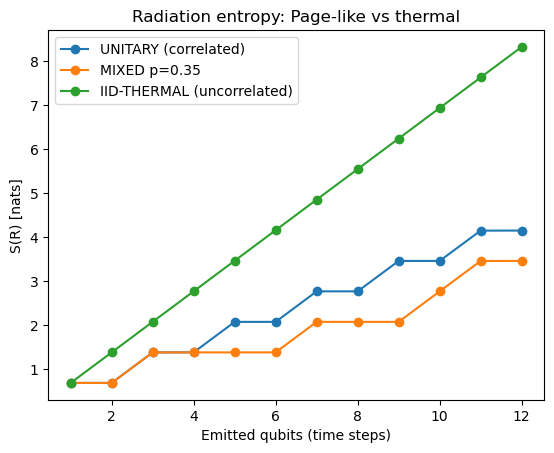

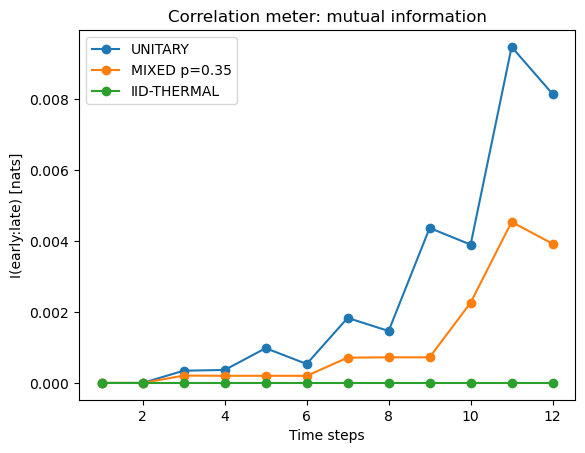

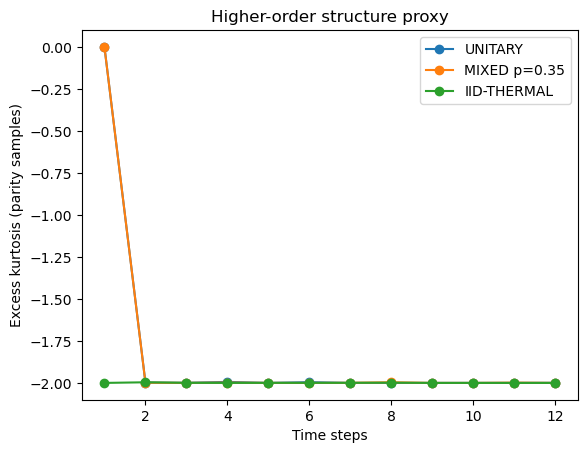

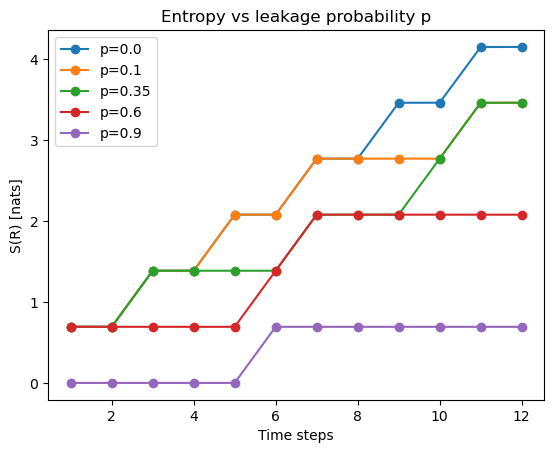

In [26]:
import numpy as np
from numpy.linalg import eigvalsh
import matplotlib.pyplot as plt

# ----------------------------
# Utilities: quantum plumbing
# ----------------------------

def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    # Fix phases so diag(R) has positive real parts
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def von_neumann_entropy(rho, eps=1e-12):
    # rho is Hermitian PSD
    vals = eigvalsh((rho + rho.conj().T) / 2.0)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))

def partial_trace_pure(psi, keep, n_qubits):
    """
    Partial trace for a pure state vector psi over qubits not in 'keep'.
    Returns reduced density matrix for subsystem 'keep'.
    Qubit indexing: 0..n_qubits-1, where 0 is the leftmost / most significant axis.
    """
    keep = list(keep)
    trace = [i for i in range(n_qubits) if i not in keep]

    # Reshape into tensor with one axis per qubit
    tensor = psi.reshape([2] * n_qubits)

    # Move keep axes to front
    perm = keep + trace
    tensor = np.transpose(tensor, perm)

    k = len(keep)
    t = n_qubits - k

    tensor = tensor.reshape(2**k, 2**t)
    rho = tensor @ tensor.conj().T
    return rho

def mutual_information_pure(psi, A, B, n_qubits):
    """
    I(A:B) = S(A) + S(B) - S(AB) for global pure state (not necessarily bipartite).
    """
    rhoA = partial_trace_pure(psi, A, n_qubits)
    rhoB = partial_trace_pure(psi, B, n_qubits)
    rhoAB = partial_trace_pure(psi, list(A) + list(B), n_qubits)
    return von_neumann_entropy(rhoA) + von_neumann_entropy(rhoB) - von_neumann_entropy(rhoAB)

def apply_unitary_on_subsystem(psi, U, targets, n_qubits):
    """
    Apply unitary U to qubits in 'targets' (list), leaving other qubits untouched.
    Implementation via tensor reshaping + permutation.
    """
    targets = list(targets)
    others = [i for i in range(n_qubits) if i not in targets]
    perm = targets + others

    tensor = psi.reshape([2] * n_qubits)
    tensor = np.transpose(tensor, perm)

    k = len(targets)
    tensor = tensor.reshape(2**k, 2**(n_qubits - k))
    tensor = (U @ tensor).reshape([2] * n_qubits)

    # invert permutation
    inv = np.argsort(perm)
    tensor = np.transpose(tensor, inv)
    return tensor.reshape(-1)

def append_qubit_zero(psi):
    # |psi> -> |psi> ⊗ |0>
    out = np.zeros(psi.size * 2, dtype=complex)
    out[0::2] = psi
    return out

def drop_qubit_to_radiation(psi, n_bh, n_rad):
    """
    We model the full register ordering as [BH qubits][RAD qubits]
    At each step we:
    - Append a fresh |0> qubit to BH side (increasing BH by 1 temporarily),
    - Scramble BH+fresh, then "emit" one BH qubit to radiation by swapping
      a chosen BH qubit into the radiation block.

    Here we simplify: after scrambling, we *move* the last BH qubit to the end
    (radiation side) by permuting axes. This is a unitary relabeling.
    """
    n_total = n_bh + n_rad

    # Move last BH qubit (index n_bh-1) to become the first radiation qubit at boundary,
    # then we treat it as radiation by updating counts outside.
    # Permutation: [0..n_bh-2, n_bh..n_total-1, n_bh-1]
    if n_bh < 1:
        raise ValueError("Need at least 1 BH qubit to emit.")

    perm = list(range(n_bh - 1)) + list(range(n_bh, n_total)) + [n_bh - 1]
    tensor = psi.reshape([2] * n_total)
    tensor = np.transpose(tensor, perm)
    return tensor.reshape(-1)

# ----------------------------
# Measurement / non-Gaussian proxy
# ----------------------------

def sample_parity(psi, qubits, n_qubits, n_samples=5000, seed=0):
    """
    Sample Z-parity on a subset of qubits by measuring in computational basis.
    Parity observable: (-1)^(sum bits over subset).
    Returns array of +/-1 samples.
    """
    rng = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    idx = rng.choice(len(probs), size=n_samples, p=probs)

    # Convert indices to bitstrings and compute parity over selected qubits.
    # Qubit 0 is most significant bit.
    out = np.empty(n_samples, dtype=float)
    for s, state in enumerate(idx):
        bits = [(state >> (n_qubits - 1 - q)) & 1 for q in qubits]
        parity = sum(bits) % 2
        out[s] = 1.0 if parity == 0 else -1.0
    return out

def excess_kurtosis(x):
    # Excess kurtosis = E[(x-mu)^4]/sigma^4 - 3
    mu = np.mean(x)
    v = np.var(x)
    if v <= 1e-15:
        return 0.0
    return float(np.mean((x - mu)**4) / (v**2) - 3.0)

# ----------------------------
# Simulators
# ----------------------------

def run_sim(model="UNITARY", n_bh_init=10, steps=10, p_thermal=0.35, seed=0):
    """
    Models:
      - "UNITARY": random unitary scramble then emit qubit each step
      - "MIXED": with prob p_thermal, do thermalized emission proxy (break correlations)
      - "IID-THERMAL": purely thermal proxy (no meaningful state evolution)
    We keep a state vector for UNITARY/MIXED; IID-THERMAL handled via synthetic stats.
    """
    rng = np.random.default_rng(seed)

    # State layout: [BH][RAD]
    # Start BH in Haar-random pure state (to mimic generic microstate)
    dim_bh = 2**n_bh_init
    psi_bh = (rng.normal(size=dim_bh) + 1j * rng.normal(size=dim_bh))
    psi_bh = psi_bh / np.linalg.norm(psi_bh)

    n_bh = n_bh_init
    n_rad = 0
    psi = psi_bh  # currently only BH register

    ent_R = []
    mi_early_late = []
    kurt_parity = []

    for t in range(steps):
        if model == "IID-THERMAL":
            # In IID thermal, treat each emitted qubit as maximally mixed; entropy grows ~ linearly
            # We approximate S(R) = n_rad * ln2 (max entropy)
            n_rad += 1
            ent_R.append(n_rad * np.log(2))

            # No correlations => mutual information near 0 between early/late blocks
            mi_early_late.append(0.0)

            # Parity samples are i.i.d. => kurtosis ~ close to 0 (for +/-1 it will be near -2)
            # We'll return a stable reference value by sampling fair coin parity:
            x = rng.choice([-1.0, 1.0], size=5000)
            kurt_parity.append(excess_kurtosis(x))
            continue

        # For UNITARY and MIXED, we evolve a pure state

        # Append fresh qubit |0> to BH (increases BH by 1 temporarily)
        psi = append_qubit_zero(psi)
        n_bh += 1
        n_total = n_bh + n_rad

        do_thermal_break = (model == "MIXED" and (rng.random() < p_thermal))

        if do_thermal_break:
            # Thermal-break proxy: randomize the "to-be-emitted" qubit and decouple it.
            # We implement by applying a random unitary only on the last BH qubit, then immediately emit it.
            U1 = random_unitary(2, seed=rng.integers(1e9))
            psi = apply_unitary_on_subsystem(psi, U1, targets=[n_bh - 1], n_qubits=n_total)
        else:
            # Scramble BH+fresh with a random unitary on BH only (size 2^n_bh)
            U = random_unitary(2**n_bh, seed=rng.integers(1e9))
            psi = apply_unitary_on_subsystem(psi, U, targets=list(range(n_bh)), n_qubits=n_total)

        # Emit one qubit from BH to radiation via permutation (unitary relabeling)
        psi = drop_qubit_to_radiation(psi, n_bh=n_bh, n_rad=n_rad)
        n_bh -= 1
        n_rad += 1
        n_total = n_bh + n_rad

        # Entropy of radiation subsystem
        rad_qubits = list(range(n_bh, n_total))
        rhoR = partial_trace_pure(psi, keep=rad_qubits, n_qubits=n_total)
        ent_R.append(von_neumann_entropy(rhoR))

        # Mutual information between early and late halves of radiation (correlation meter)
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, n_total))
            mi = mutual_information_pure(psi, A=early, B=late, n_qubits=n_total)
        else:
            mi = 0.0
        mi_early_late.append(mi)

        # Non-Gaussian proxy: sample parity on late radiation chunk
        if n_rad >= 2:
            late = list(range(n_bh + (n_rad // 2), n_total))
            x = sample_parity(psi, qubits=late, n_qubits=n_total, n_samples=5000, seed=int(seed + 13*t))
            kurt_parity.append(excess_kurtosis(x))
        else:
            kurt_parity.append(0.0)

    return np.array(ent_R), np.array(mi_early_late), np.array(kurt_parity)

def sweep_p(n_bh_init=10, steps=10, ps=(0.0, 0.1, 0.35, 0.6, 0.9), seed=0):
    curves = []
    for p in ps:
        S, MI, K = run_sim("MIXED", n_bh_init=n_bh_init, steps=steps, p_thermal=p, seed=seed)
        curves.append((p, S, MI, K))
    return curves

# ----------------------------
# Run + plots
# ----------------------------

if __name__ == "__main__":
    n_bh_init = 12
    steps = 12
    seed = 7

    S_u, MI_u, K_u = run_sim("UNITARY", n_bh_init=n_bh_init, steps=steps, seed=seed)
    S_i, MI_i, K_i = run_sim("IID-THERMAL", n_bh_init=n_bh_init, steps=steps, seed=seed)
    S_m, MI_m, K_m = run_sim("MIXED", n_bh_init=n_bh_init, steps=steps, p_thermal=0.35, seed=seed)

    t = np.arange(1, steps + 1)

    plt.figure()
    plt.plot(t, S_u, marker="o", label="UNITARY (correlated)")
    plt.plot(t, S_m, marker="o", label="MIXED p=0.35")
    plt.plot(t, S_i, marker="o", label="IID-THERMAL (uncorrelated)")
    plt.xlabel("Emitted qubits (time steps)")
    plt.ylabel("S(R) [nats]")
    plt.title("Radiation entropy: Page-like vs thermal")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, MI_u, marker="o", label="UNITARY")
    plt.plot(t, MI_m, marker="o", label="MIXED p=0.35")
    plt.plot(t, MI_i, marker="o", label="IID-THERMAL")
    plt.xlabel("Time steps")
    plt.ylabel("I(early:late) [nats]")
    plt.title("Correlation meter: mutual information")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, K_u, marker="o", label="UNITARY")
    plt.plot(t, K_m, marker="o", label="MIXED p=0.35")
    plt.plot(t, K_i, marker="o", label="IID-THERMAL")
    plt.xlabel("Time steps")
    plt.ylabel("Excess kurtosis (parity samples)")
    plt.title("Higher-order structure proxy")
    plt.legend()
    plt.show()

    # Optional: sweep the leakage dial p
    ps = [0.0, 0.1, 0.35, 0.6, 0.9]
    curves = sweep_p(n_bh_init=n_bh_init, steps=steps, ps=ps, seed=seed)

    plt.figure()
    for p, S, MI, K in curves:
        plt.plot(t, S, marker="o", label=f"p={p}")
    plt.xlabel("Time steps")
    plt.ylabel("S(R) [nats]")
    plt.title("Entropy vs leakage probability p")
    plt.legend()
    plt.show()


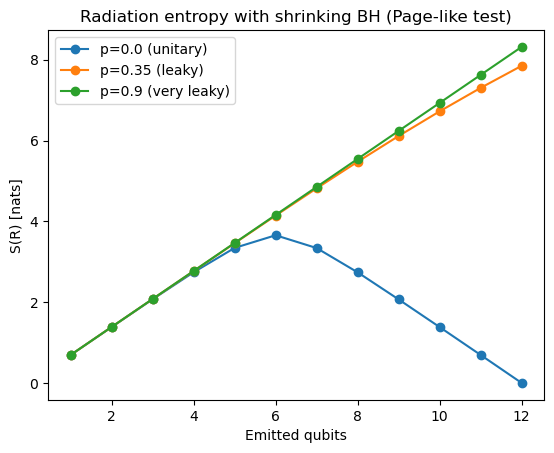

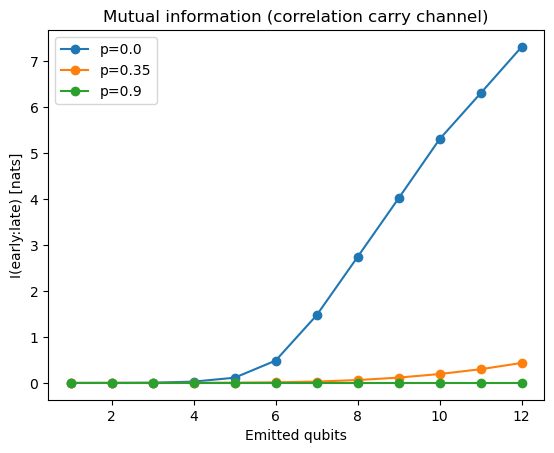

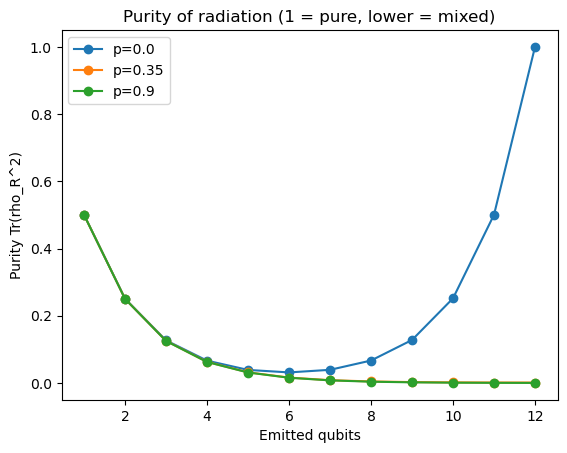

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

# ----------------------------
# Linear algebra helpers
# ----------------------------

def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def vn_entropy(rho, eps=1e-12):
    rho = (rho + rho.conj().T) / 2.0
    vals = eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

def reshape_dm(rho, N):
    # rho is (2^N x 2^N) -> tensor with 2N indices
    return rho.reshape([2]*N + [2]*N)

def partial_trace_dm(rho, keep, N):
    """
    Partial trace of density matrix over qubits not in keep.
    Qubit indices: 0..N-1
    Returns rho_keep of dimension 2^len(keep).
    """
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]

    T = reshape_dm(rho, N)

    # Permute: keep (bra), trace (bra), keep (ket), trace (ket)
    perm = keep + trace + [i+N for i in keep] + [i+N for i in trace]
    T = np.transpose(T, perm)

    k = len(keep)
    t = N - k

    T = T.reshape(2**k, 2**t, 2**k, 2**t)
    # Trace over the traced subsystem (second and fourth axes)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

def apply_unitary_on_subset_dm(rho, U, targets, N):
    """
    Apply unitary U on 'targets' qubits of an N-qubit density matrix.
    """
    targets = list(targets)
    others = [i for i in range(N) if i not in targets]
    perm = targets + others

    T = reshape_dm(rho, N)

    # Permute bra and ket indices consistently
    perm_bra = perm
    perm_ket = [i+N for i in perm]
    T = np.transpose(T, perm_bra + perm_ket)

    k = len(targets)
    dA = 2**k
    dB = 2**(N-k)

    T = T.reshape(dA, dB, dA, dB)
    # (U ⊗ I) rho (U† ⊗ I)
    T = np.einsum("ij, j b k d -> i b k d", U, T)
    T = np.einsum("i b k d, kj -> i b j d", T, U.conj().T)

    T = T.reshape([2]*N + [2]*N)

    # Invert permutation
    inv = np.argsort(perm)
    inv_bra = list(inv)
    inv_ket = [i+N for i in inv]
    T = np.transpose(T, inv_bra + inv_ket)

    return T.reshape(2**N, 2**N)

def depolarize_qubit_dm(rho, q, p, N):
    """
    Single-qubit depolarizing channel on qubit q:
      E_p(rho) = (1-p) rho + p * (I/2 ⊗ Tr_q rho)
    This kills correlations involving that qubit as p -> 1.
    """
    if p <= 0:
        return rho
    if p >= 1:
        p = 1.0

    # Trace out qubit q
    keep = [i for i in range(N) if i != q]
    rho_rest = partial_trace_dm(rho, keep, N)  # dim 2^(N-1)

    # Re-embed: (I/2)_q ⊗ rho_rest, but need correct qubit ordering
    # We'll build by tensoring and then permuting axes back.

    I2 = np.eye(2, dtype=complex) / 2.0
    # Place q as first factor, then others; later permute into place
    rho_embed = np.kron(I2, rho_rest)  # qubit order: [q, keep...]

    # Now permute qubits from [q, keep...] to [0..N-1]
    # Determine where each original qubit appears in this constructed ordering
    constructed = [q] + keep
    inv = np.argsort(constructed)  # maps constructed positions -> sorted by qubit index

    # Permute density matrix via tensor index permutation
    T = rho_embed.reshape([2]*N + [2]*N)
    perm = list(inv) + [i+N for i in inv]
    T = np.transpose(T, perm)
    rho_embed = T.reshape(2**N, 2**N)

    return (1 - p) * rho + p * rho_embed

# ----------------------------
# Simulator
# ----------------------------

def simulate(N=12, p_leak=0.0, seed=7):
    """
    N total qubits fixed.
    Interpretation: first n_bh qubits = BH, last n_rad qubits = radiation.
    Each step: scramble BH, depolarize the boundary BH qubit with prob p_leak,
    then "emit" it by moving boundary between BH and R (i.e., n_bh--, n_rad++).
    """
    rng = np.random.default_rng(seed)

    # Start with random pure state on BH (all N qubits are BH initially)
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())

    n_bh = N
    n_rad = 0

    ent_R = []
    mi = []
    pur_R = []

    for t in range(N):  # emit all qubits
        # Scramble BH subsystem (qubits 0..n_bh-1)
        d_bh = 2**n_bh
        U = random_unitary(d_bh, seed=rng.integers(1_000_000_000))
        rho = apply_unitary_on_subset_dm(rho, U, targets=list(range(n_bh)), N=N)

        # Depolarize the boundary qubit (the one about to be emitted): index n_bh-1
        boundary = n_bh - 1
        rho = depolarize_qubit_dm(rho, q=boundary, p=p_leak, N=N)

        # Emit: shrink BH by 1, grow radiation by 1
        n_bh -= 1
        n_rad += 1

        rad_qubits = list(range(n_bh, N))  # last n_rad qubits
        rhoR = partial_trace_dm(rho, keep=rad_qubits, N=N)
        ent_R.append(vn_entropy(rhoR))
        pur_R.append(purity(rhoR))

        # Mutual information between early/late halves of radiation
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, N))

            rhoE = partial_trace_dm(rho, keep=early, N=N)
            rhoL = partial_trace_dm(rho, keep=late, N=N)
            rhoEL = partial_trace_dm(rho, keep=early + late, N=N)

            I = vn_entropy(rhoE) + vn_entropy(rhoL) - vn_entropy(rhoEL)
        else:
            I = 0.0
        mi.append(I)

    return np.array(ent_R), np.array(mi), np.array(pur_R)

if __name__ == "__main__":
    N = 12
    seed = 7

    S0, MI0, P0 = simulate(N=N, p_leak=0.0, seed=seed)     # unitary
    S35, MI35, P35 = simulate(N=N, p_leak=0.35, seed=seed) # Nexus-ish leak dial
    S90, MI90, P90 = simulate(N=N, p_leak=0.9, seed=seed)  # strong info destruction

    t = np.arange(1, N+1)

    plt.figure()
    plt.plot(t, S0, marker="o", label="p=0.0 (unitary)")
    plt.plot(t, S35, marker="o", label="p=0.35 (leaky)")
    plt.plot(t, S90, marker="o", label="p=0.9 (very leaky)")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S(R) [nats]")
    plt.title("Radiation entropy with shrinking BH (Page-like test)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, MI0, marker="o", label="p=0.0")
    plt.plot(t, MI35, marker="o", label="p=0.35")
    plt.plot(t, MI90, marker="o", label="p=0.9")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I(early:late) [nats]")
    plt.title("Mutual information (correlation carry channel)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, P0, marker="o", label="p=0.0")
    plt.plot(t, P35, marker="o", label="p=0.35")
    plt.plot(t, P90, marker="o", label="p=0.9")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Purity Tr(rho_R^2)")
    plt.title("Purity of radiation (1 = pure, lower = mixed)")
    plt.legend()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

# ----------------------------
# Quantum utilities (density matrix)
# ----------------------------

def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def vn_entropy(rho, eps=1e-12):
    rho = (rho + rho.conj().T) / 2.0
    vals = eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

def reshape_dm(rho, N):
    return rho.reshape([2]*N + [2]*N)

def partial_trace_dm(rho, keep, N):
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]
    T = reshape_dm(rho, N)
    perm = keep + trace + [i+N for i in keep] + [i+N for i in trace]
    T = np.transpose(T, perm)
    k = len(keep)
    t = N - k
    T = T.reshape(2**k, 2**t, 2**k, 2**t)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

def apply_unitary_on_subset_dm(rho, U, targets, N):
    targets = list(targets)
    others = [i for i in range(N) if i not in targets]
    perm = targets + others

    T = reshape_dm(rho, N)
    perm_bra = perm
    perm_ket = [i+N for i in perm]
    T = np.transpose(T, perm_bra + perm_ket)

    k = len(targets)
    dA = 2**k
    dB = 2**(N-k)

    T = T.reshape(dA, dB, dA, dB)
    T = np.einsum("ij, j b k d -> i b k d", U, T)
    T = np.einsum("i b k d, kj -> i b j d", T, U.conj().T)

    T = T.reshape([2]*N + [2]*N)

    inv = np.argsort(perm)
    inv_bra = list(inv)
    inv_ket = [i+N for i in inv]
    T = np.transpose(T, inv_bra + inv_ket)

    return T.reshape(2**N, 2**N)

def depolarize_qubit_dm(rho, q, p, N):
    if p <= 0:
        return rho
    p = min(float(p), 1.0)

    keep = [i for i in range(N) if i != q]
    rho_rest = partial_trace_dm(rho, keep, N)

    I2 = np.eye(2, dtype=complex) / 2.0
    rho_embed = np.kron(I2, rho_rest)  # order: [q, keep...]

    constructed = [q] + keep
    inv = np.argsort(constructed)

    T = rho_embed.reshape([2]*N + [2]*N)
    perm = list(inv) + [i+N for i in inv]
    T = np.transpose(T, perm)
    rho_embed = T.reshape(2**N, 2**N)

    return (1 - p) * rho + p * rho_embed

# ----------------------------
# Nexus leakage control: alpha_hat -> p_t
# ----------------------------

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def alpha_hat_step(alpha_true, se, rng, dither=0.0):
    a = rng.normal(loc=alpha_true, scale=se)
    if dither > 0:
        a = a + rng.uniform(-dither, dither)
    return float(a)

def leakage_from_alpha(alpha_hat, alpha_true, beta=250.0, delta=0.0015):
    # p_t = sigmoid(beta*(|a-a*| - delta))
    d = abs(alpha_hat - alpha_true)
    return float(sigmoid(beta * (d - delta)))

# ----------------------------
# Simulation with dynamic leakage
# ----------------------------

def simulate_dynamic(
    N=12,
    alpha_true=np.pi/9,
    se0=0.0025,
    se_scale_with_bh=True,
    beta=250.0,
    delta=0.0015,
    dither=0.0,
    seed=7
):
    rng = np.random.default_rng(seed)

    # random pure state on full BH initially
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j*rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())

    n_bh = N
    n_rad = 0

    ent_R, pur_R, mi = [], [], []
    alpha_hats, ps, glyphs, collapse35 = [], [], [], []

    for t in range(N):
        # Scramble BH block
        d_bh = 2**n_bh
        U = random_unitary(d_bh, seed=rng.integers(1_000_000_000))
        rho = apply_unitary_on_subset_dm(rho, U, targets=list(range(n_bh)), N=N)

        # alpha estimate -> leakage p_t
        se_t = se0 / np.sqrt(max(n_bh, 1)) if se_scale_with_bh else se0
        a_hat = alpha_hat_step(alpha_true, se_t, rng, dither=dither)
        p_t = leakage_from_alpha(a_hat, alpha_true, beta=beta, delta=delta)
        g = round(a_hat, 2)

        alpha_hats.append(a_hat)
        ps.append(p_t)
        glyphs.append(g)
        collapse35.append(1 if abs(g - 0.35) < 1e-12 else 0)

        # Apply leakage to boundary qubit, then emit it (shrink BH)
        boundary = n_bh - 1
        rho = depolarize_qubit_dm(rho, q=boundary, p=p_t, N=N)

        n_bh -= 1
        n_rad += 1

        rad_qubits = list(range(n_bh, N))
        rhoR = partial_trace_dm(rho, keep=rad_qubits, N=N)

        ent_R.append(vn_entropy(rhoR))
        pur_R.append(purity(rhoR))

        # MI between early/late radiation
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, N))
            rhoE = partial_trace_dm(rho, keep=early, N=N)
            rhoL = partial_trace_dm(rho, keep=late, N=N)
            rhoEL = partial_trace_dm(rho, keep=early + late, N=N)
            I = vn_entropy(rhoE) + vn_entropy(rhoL) - vn_entropy(rhoEL)
        else:
            I = 0.0
        mi.append(I)

    return {
        "S": np.array(ent_R),
        "P": np.array(pur_R),
        "MI": np.array(mi),
        "alpha_hat": np.array(alpha_hats),
        "p": np.array(ps),
        "glyph": np.array(glyphs),
        "collapse35": np.array(collapse35),
    }

def ensemble(N=12, runs=50, **kwargs):
    S_all, P_all, MI_all = [], [], []
    p_all, c35_all = [], []

    for r in range(runs):
        out = simulate_dynamic(N=N, seed=kwargs.get("seed", 7) + r, **kwargs)
        S_all.append(out["S"])
        P_all.append(out["P"])
        MI_all.append(out["MI"])
        p_all.append(out["p"])
        c35_all.append(out["collapse35"])

    S_all = np.stack(S_all)
    P_all = np.stack(P_all)
    MI_all = np.stack(MI_all)
    p_all = np.stack(p_all)
    c35_all = np.stack(c35_all)

    return {
        "S_mean": S_all.mean(axis=0), "S_std": S_all.std(axis=0),
        "P_mean": P_all.mean(axis=0), "P_std": P_all.std(axis=0),
        "MI_mean": MI_all.mean(axis=0), "MI_std": MI_all.std(axis=0),
        "p_mean": p_all.mean(axis=0), "p_std": p_all.std(axis=0),
        "collapse35_rate": c35_all.mean(axis=0),  # per-step
        "collapse35_total": c35_all.mean(),        # overall fraction
        "final_entropy_mean": S_all[:, -1].mean(),
        "final_purity_mean": P_all[:, -1].mean(),
    }

# ----------------------------
# Run a few scenarios
# ----------------------------

if __name__ == "__main__":
    N = 12
    t = np.arange(1, N+1)

    # Scenario A: phase-locked (tight SE, small delta)
    A = ensemble(
        N=N, runs=80,
        se0=0.0015, se_scale_with_bh=True,
        beta=300.0, delta=0.0012,
        dither=0.0
    )

    # Scenario B: noisier estimator -> more leakage events
    B = ensemble(
        N=N, runs=80,
        se0=0.0040, se_scale_with_bh=True,
        beta=300.0, delta=0.0012,
        dither=0.0
    )

    # Scenario C: same as B but add small dither (render behavior changes, latent doesn't)
    C = ensemble(
        N=N, runs=80,
        se0=0.0040, se_scale_with_bh=True,
        beta=300.0, delta=0.0012,
        dither=0.0005
    )

    def bandplot(x, mean, std, label):
        plt.plot(x, mean, label=label)
        plt.fill_between(x, mean-std, mean+std, alpha=0.2)

    plt.figure()
    bandplot(t, A["S_mean"], A["S_std"], "A: tighter (more unitary)")
    bandplot(t, B["S_mean"], B["S_std"], "B: noisier (more leak)")
    bandplot(t, C["S_mean"], C["S_std"], "C: noisier + dither")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S(R) [nats]")
    plt.title("Dynamic leakage driven by alpha_hat distance to pi/9")
    plt.legend()
    plt.show()

    plt.figure()
    bandplot(t, A["P_mean"], A["P_std"], "A")
    bandplot(t, B["P_mean"], B["P_std"], "B")
    bandplot(t, C["P_mean"], C["P_std"], "C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Purity Tr(rho_R^2)")
    plt.title("Purity under dynamic leakage")
    plt.legend()
    plt.show()

    plt.figure()
    bandplot(t, A["p_mean"], A["p_std"], "A")
    bandplot(t, B["p_mean"], B["p_std"], "B")
    bandplot(t, C["p_mean"], C["p_std"], "C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Leak probability p_t")
    plt.title("Emergent leakage control p_t")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title("Render collapse rate to 0.35")
    plt.legend()
    plt.show()

    print("A final entropy mean:", A["final_entropy_mean"], "final purity mean:", A["final_purity_mean"], "collapse35_total:", A["collapse35_total"])
    print("B final entropy mean:", B["final_entropy_mean"], "final purity mean:", B["final_purity_mean"], "collapse35_total:", B["collapse35_total"])
    print("C final entropy mean:", C["final_entropy_mean"], "final purity mean:", C["final_purity_mean"], "collapse35_total:", C["collapse35_total"])


In [ ]:
# Page-buffer sweep for BH toy (runnable)
# - Sweeps p around 0.35, runs multiple seeds per p
# - Metrics: Page-survival fraction, peak mutual info, final purity
# - Outputs: plots and measured buffer width where Page survival < 0.5

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
import math
import time

# ----------------------------
# Linear algebra helpers (same as your simulator)
# ----------------------------
def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def vn_entropy(rho, eps=1e-12):
    rho = (rho + rho.conj().T) / 2.0
    vals = eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

def reshape_dm(rho, N):
    return rho.reshape([2]*N + [2]*N)

def partial_trace_dm(rho, keep, N):
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]
    T = reshape_dm(rho, N)
    perm = keep + trace + [i+N for i in keep] + [i+N for i in trace]
    T = np.transpose(T, perm)
    k = len(keep)
    t = N - k
    T = T.reshape(2**k, 2**t, 2**k, 2**t)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

def apply_unitary_on_subset_dm(rho, U, targets, N):
    targets = list(targets)
    others = [i for i in range(N) if i not in targets]
    perm = targets + others
    T = reshape_dm(rho, N)
    perm_bra = perm
    perm_ket = [i+N for i in perm]
    T = np.transpose(T, perm_bra + perm_ket)
    k = len(targets)
    dA = 2**k
    dB = 2**(N-k)
    T = T.reshape(dA, dB, dA, dB)
    T = np.einsum("ij, j b k d -> i b k d", U, T)
    T = np.einsum("i b k d, kj -> i b j d", T, U.conj().T)
    T = T.reshape([2]*N + [2]*N)
    inv = np.argsort(perm)
    inv_bra = list(inv)
    inv_ket = [i+N for i in inv]
    T = np.transpose(T, inv_bra + inv_ket)
    return T.reshape(2**N, 2**N)

def depolarize_qubit_dm(rho, q, p, N):
    if p <= 0:
        return rho
    if p >= 1:
        p = 1.0
    keep = [i for i in range(N) if i != q]
    rho_rest = partial_trace_dm(rho, keep, N)
    I2 = np.eye(2, dtype=complex) / 2.0
    rho_embed = np.kron(I2, rho_rest)
    constructed = [q] + keep
    inv = np.argsort(constructed)
    T = rho_embed.reshape([2]*N + [2]*N)
    perm = list(inv) + [i+N for i in inv]
    T = np.transpose(T, perm)
    rho_embed = T.reshape(2**N, 2**N)
    return (1 - p) * rho + p * rho_embed

# ----------------------------
# Simulator (same semantics)
# ----------------------------
def simulate(N=12, p_leak=0.0, seed=7):
    rng = np.random.default_rng(seed)
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())
    n_bh = N
    n_rad = 0
    ent_R = []
    mi = []
    pur_R = []
    for t in range(N):
        d_bh = 2**n_bh
        U = random_unitary(d_bh, seed=rng.integers(1_000_000_000))
        rho = apply_unitary_on_subset_dm(rho, U, targets=list(range(n_bh)), N=N)
        boundary = n_bh - 1
        rho = depolarize_qubit_dm(rho, q=boundary, p=p_leak, N=N)
        n_bh -= 1
        n_rad += 1
        rad_qubits = list(range(n_bh, N))
        rhoR = partial_trace_dm(rho, keep=rad_qubits, N=N)
        ent_R.append(vn_entropy(rhoR))
        pur_R.append(purity(rhoR))
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, N))
            rhoE = partial_trace_dm(rho, keep=early, N=N)
            rhoL = partial_trace_dm(rho, keep=late, N=N)
            rhoEL = partial_trace_dm(rho, keep=early + late, N=N)
            I = vn_entropy(rhoE) + vn_entropy(rhoL) - vn_entropy(rhoEL)
        else:
            I = 0.0
        mi.append(I)
    return np.array(ent_R), np.array(mi), np.array(pur_R)

# ----------------------------
# Page-like survival test
# ----------------------------
def page_survival_test(entropy_series, min_drop_frac=0.1):
    """
    Decide whether the entropy series shows a Page-like turn:
    - Find peak index (first maximum)
    - Check if entropy decreases after peak by at least min_drop_frac * peak_value
    - Also require peak occurs before final emission (not at last index)
    """
    s = np.asarray(entropy_series)
    peak_idx = int(np.argmax(s))
    peak_val = float(s[peak_idx])
    final_val = float(s[-1])
    if peak_idx >= len(s) - 1:
        return False
    drop = peak_val - final_val
    if peak_val <= 0:
        return False
    return (drop >= min_drop_frac * peak_val)

# ----------------------------
# Sweep driver
# ----------------------------
def sweep_p_grid(N=12, p_values=None, seeds_per_p=50, min_drop_frac=0.12):
    if p_values is None:
        # fine grid around 0.35 plus coarse elsewhere
        p_values = np.concatenate([
            np.linspace(0.0, 0.2, 9),
            np.linspace(0.21, 0.34, 14),
            np.linspace(0.34, 0.36, 41),  # fine around 0.35
            np.linspace(0.361, 0.5, 14),
            np.linspace(0.51, 0.9, 8)
        ])
    p_values = np.unique(np.round(p_values, 4))
    results = {}
    total_runs = len(p_values) * seeds_per_p
    run_count = 0
    t0 = time.time()
    for p in p_values:
        surv = []
        peak_mi = []
        final_purity = []
        for seed in range(seeds_per_p):
            entR, mi, purR = simulate(N=N, p_leak=float(p), seed=seed + 1000)
            surv.append(page_survival_test(entR, min_drop_frac=min_drop_frac))
            peak_mi.append(float(np.max(mi)))
            final_purity.append(float(purR[-1]))
            run_count += 1
        results[float(p)] = {
            'survival_frac': float(np.mean(surv)),
            'survival_std': float(np.std(surv, ddof=1)),
            'peak_mi_mean': float(np.mean(peak_mi)),
            'peak_mi_std': float(np.std(peak_mi, ddof=1)),
            'final_purity_mean': float(np.mean(final_purity)),
            'final_purity_std': float(np.std(final_purity, ddof=1)),
            'raw_surv': np.array(surv),
            'raw_peak_mi': np.array(peak_mi),
            'raw_final_purity': np.array(final_purity)
        }
    elapsed = time.time() - t0
    print(f"Sweep finished: {len(p_values)} p-values, {seeds_per_p} seeds each, total runs {run_count} in {elapsed:.1f}s")
    return p_values, results

# ----------------------------
# Aggregation and plotting
# ----------------------------
def plot_sweep(p_values, results, N=12):
    ps = np.array(p_values)
    surv = np.array([results[p]['survival_frac'] for p in ps])
    surv_std = np.array([results[p]['survival_std'] for p in ps])
    mi_mean = np.array([results[p]['peak_mi_mean'] for p in ps])
    mi_std = np.array([results[p]['peak_mi_std'] for p in ps])
    pur_mean = np.array([results[p]['final_purity_mean'] for p in ps])
    pur_std = np.array([results[p]['final_purity_std'] for p in ps])

    # Survival plot
    plt.figure(figsize=(8,4))
    plt.plot(ps, surv, marker='o', label='Page survival fraction')
    plt.fill_between(ps, np.clip(surv - 1.96*surv_std/np.sqrt(len(results[ps[0]]['raw_surv'])),0,1),
                     np.clip(surv + 1.96*surv_std/np.sqrt(len(results[ps[0]]['raw_surv'])),0,1), alpha=0.2)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p')
    plt.ylabel('Fraction of runs with Page-like turn')
    plt.title(f'Page survival vs p (N={N})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Peak mutual info
    plt.figure(figsize=(8,4))
    plt.errorbar(ps, mi_mean, yerr=1.96*mi_std/np.sqrt(len(results[ps[0]]['raw_peak_mi'])), marker='o', capsize=3)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p')
    plt.ylabel('Peak mutual information (nats)')
    plt.title(f'Peak mutual info vs p (N={N})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Final purity
    plt.figure(figsize=(8,4))
    plt.errorbar(ps, pur_mean, yerr=1.96*pur_std/np.sqrt(len(results[ps[0]]['raw_final_purity'])), marker='o', capsize=3)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p')
    plt.ylabel('Final purity Tr(rho_R^2)')
    plt.title(f'Final purity vs p (N={N})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# Buffer width measurement
# ----------------------------
def measure_buffer_width(p_values, results, threshold=0.5):
    ps = np.array(sorted(p_values))
    surv = np.array([results[p]['survival_frac'] for p in ps])
    # find contiguous region around 0.35 where survival >= threshold
    center_idx = np.argmin(np.abs(ps - 0.35))
    # expand left
    left = center_idx
    while left > 0 and surv[left] >= threshold:
        left -= 1
    # expand right
    right = center_idx
    while right < len(ps)-1 and surv[right] >= threshold:
        right += 1
    p_left = ps[left] if surv[left] >= threshold else ps[left+1]
    p_right = ps[right] if surv[right] >= threshold else ps[right-1]
    width = float(p_right - p_left)
    return p_left, p_right, width

# ----------------------------
# Run sweep with defaults
# ----------------------------
if __name__ == "__main__":
    N = 12
    seeds = 50
    p_values, results = sweep_p_grid(N=N, seeds_per_p=seeds)
    p_left, p_right, width = measure_buffer_width(p_values, results, threshold=0.5)
    print(f"Measured buffer (survival >= 0.5) around 0.35: left={p_left:.4f}, right={p_right:.4f}, width={width:.4f}")
    plot_sweep(p_values, results, N=N)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
# ----------------------------
# Linear algebra helpers
# ----------------------------
def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()
def vn_entropy(rho, eps=1e-12):
    rho = (rho + rho.conj().T) / 2.0
    vals = eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))
def purity(rho):
    return float(np.real(np.trace(rho @ rho)))
def reshape_dm(rho, N):
    # rho is (2^N x 2^N) -> tensor with 2N indices
    return rho.reshape([2]*N + [2]*N)
def partial_trace_dm(rho, keep, N):
    """
    Partial trace of density matrix over qubits not in keep.
    Qubit indices: 0..N-1
    Returns rho_keep of dimension 2^len(keep).
    """
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]
    T = reshape_dm(rho, N)
    # Permute: keep (bra), trace (bra), keep (ket), trace (ket)
    perm = keep + trace + [i+N for i in keep] + [i+N for i in trace]
    T = np.transpose(T, perm)
    k = len(keep)
    t = N - k
    T = T.reshape(2**k, 2**t, 2**k, 2**t)
    # Trace over the traced subsystem (second and fourth axes)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep
def apply_unitary_on_subset_dm(rho, U, targets, N):
    """
    Apply unitary U on 'targets' qubits of an N-qubit density matrix.
    """
    targets = list(targets)
    others = [i for i in range(N) if i not in targets]
    perm = targets + others
    T = reshape_dm(rho, N)
    # Permute bra and ket indices consistently
    perm_bra = perm
    perm_ket = [i+N for i in perm]
    T = np.transpose(T, perm_bra + perm_ket)
    k = len(targets)
    dA = 2**k
    dB = 2**(N-k)
    T = T.reshape(dA, dB, dA, dB)
    # (U ⊗ I) rho (U† ⊗ I)
    T = np.einsum("ij, j b k d -> i b k d", U, T)
    T = np.einsum("i b k d, kj -> i b j d", T, U.conj().T)
    T = T.reshape([2]*N + [2]*N)
    # Invert permutation
    inv = np.argsort(perm)
    inv_bra = list(inv)
    inv_ket = [i+N for i in inv]
    T = np.transpose(T, inv_bra + inv_ket)
    return T.reshape(2**N, 2**N)
def depolarize_qubit_dm(rho, q, p, N):
    """
    Single-qubit depolarizing channel on qubit q:
      E_p(rho) = (1-p) rho + p * (I/2 ⊗ Tr_q rho)
    This kills correlations involving that qubit as p -> 1.
    """
    if p <= 0:
        return rho
    if p >= 1:
        p = 1.0
    # Trace out qubit q
    keep = [i for i in range(N) if i != q]
    rho_rest = partial_trace_dm(rho, keep, N) # dim 2^(N-1)
    # Re-embed: (I/2)_q ⊗ rho_rest, but need correct qubit ordering
    # We'll build by tensoring and then permuting qubit back.
    I2 = np.eye(2, dtype=complex) / 2.0
    # Place q as first factor, then others; later permute into place
    rho_embed = np.kron(I2, rho_rest) # qubit order: [q, keep...]
    # Now permute qubits from [q, keep...] to [0..N-1]
    # Determine where each original qubit appears in this constructed ordering
    constructed = [q] + keep
    inv = np.argsort(constructed) # maps constructed positions -> sorted by qubit index
    # Permute density matrix via tensor index permutation
    T = rho_embed.reshape([2]*N + [2]*N)
    perm = list(inv) + [i+N for i in inv]
    T = np.transpose(T, perm)
    rho_embed = T.reshape(2**N, 2**N)
    return (1 - p) * rho + p * rho_embed
# ----------------------------
# Simulator
# ----------------------------
def simulate(N=24, p_leak=0.0, seed=7):
    """
    N total qubits fixed.
    Interpretation: first n_bh qubits = BH, last n_rad qubits = radiation.
    Each step: scramble BH, depolarize the boundary BH qubit with prob p_leak,
    then "emit" it by moving boundary between BH and R (i.e., n_bh--, n_rad++).
    """
    rng = np.random.default_rng(seed)
    # Start with random pure state on BH (all N qubits are BH initially)
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())
    n_bh = N
    n_rad = 0
    ent_R = []
    mi = []
    pur_R = []
    for t in range(N): # emit all qubits
        # Scramble BH subsystem (qubits 0..n_bh-1)
        d_bh = 2**n_bh
        U = random_unitary(d_bh, seed=rng.integers(1_000_000_000))
        rho = apply_unitary_on_subset_dm(rho, U, targets=list(range(n_bh)), N=N)
        # Depolarize the boundary qubit (the one about to be emitted): index n_bh-1
        boundary = n_bh - 1
        rho = depolarize_qubit_dm(rho, q=boundary, p=p_leak, N=N)
        # Emit: shrink BH by 1, grow radiation by 1
        n_bh -= 1
        n_rad += 1
        rad_qubits = list(range(n_bh, N)) # last n_rad qubits
        rhoR = partial_trace_dm(rho, keep=rad_qubits, N=N)
        ent_R.append(vn_entropy(rhoR))
        pur_R.append(purity(rhoR))
        # Mutual information between early/late halves of radiation
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, N))
            rhoE = partial_trace_dm(rho, keep=early, N=N)
            rhoL = partial_trace_dm(rho, keep=late, N=N)
            rhoEL = partial_trace_dm(rho, keep=early + late, N=N)
            I = vn_entropy(rhoE) + vn_entropy(rhoL) - vn_entropy(rhoEL)
        else:
            I = 0.0
        mi.append(I)
    return np.array(ent_R), np.array(mi), np.array(pur_R)
if __name__ == "__main__":
    N = 24
    seed = 7
    S0, MI0, P0 = simulate(N=N, p_leak=0.0, seed=seed) # unitary
    S35, MI35, P35 = simulate(N=N, p_leak=0.35, seed=seed) # Nexus-ish leak dial
    S90, MI90, P90 = simulate(N=N, p_leak=0.9, seed=seed) # strong info destruction
    t = np.arange(1, N+1)
    plt.figure()
    plt.plot(t, S0, marker="o", label="p=0.0 (unitary)")
    plt.plot(t, S35, marker="o", label="p=0.35 (leaky)")
    plt.plot(t, S90, marker="o", label="p=0.9 (very leaky)")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S(R) [nats]")
    plt.title("Radiation entropy with shrinking BH (Page-like test)")
    plt.legend()
    plt.show()
    plt.figure()
    plt.plot(t, MI0, marker="o", label="p=0.0")
    plt.plot(t, MI35, marker="o", label="p=0.35")
    plt.plot(t, MI90, marker="o", label="p=0.9")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I(early:late) [nats]")
    plt.title("Mutual information (correlation carry channel)")
    plt.legend()
    plt.show()
    plt.figure()
    plt.plot(t, P0, marker="o", label="p=0.0")
    plt.plot(t, P35, marker="o", label="p=0.35")
    plt.plot(t, P90, marker="o", label="p=0.9")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Purity Tr(rho_R^2)")
    plt.title("Purity of radiation (1 = pure, lower = mixed)")
    plt.legend()
    plt.show()

In [ ]:
# Page-buffer sweep + χ diagnostics (runnable cell)
# Paste into a notebook cell and run. Requires numpy, matplotlib.

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
import time, math

# ----------------------------
# Linear algebra helpers (density-matrix utilities)
# ----------------------------
def random_unitary(dim, seed=None):
    rng = np.random.default_rng(seed)
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def vn_entropy(rho, eps=1e-12):
    rho = (rho + rho.conj().T) / 2.0
    vals = eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, 1.0)
    vals = vals[vals > eps]
    return float(-np.sum(vals * np.log(vals)))

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

def reshape_dm(rho, N):
    return rho.reshape([2]*N + [2]*N)

def partial_trace_dm(rho, keep, N):
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]
    T = reshape_dm(rho, N)
    perm = keep + trace + [i+N for i in keep] + [i+N for i in trace]
    T = np.transpose(T, perm)
    k = len(keep)
    t = N - k
    T = T.reshape(2**k, 2**t, 2**k, 2**t)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

def apply_unitary_on_subset_dm(rho, U, targets, N):
    targets = list(targets)
    others = [i for i in range(N) if i not in targets]
    perm = targets + others
    T = reshape_dm(rho, N)
    perm_bra = perm
    perm_ket = [i+N for i in perm]
    T = np.transpose(T, perm_bra + perm_ket)
    k = len(targets)
    dA = 2**k
    dB = 2**(N-k)
    T = T.reshape(dA, dB, dA, dB)
    T = np.einsum("ij, j b k d -> i b k d", U, T)
    T = np.einsum("i b k d, kj -> i b j d", T, U.conj().T)
    T = T.reshape([2]*N + [2]*N)
    inv = np.argsort(perm)
    inv_bra = list(inv)
    inv_ket = [i+N for i in inv]
    T = np.transpose(T, inv_bra + inv_ket)
    return T.reshape(2**N, 2**N)

def depolarize_qubit_dm(rho, q, p, N):
    if p <= 0:
        return rho
    if p >= 1:
        p = 1.0
    keep = [i for i in range(N) if i != q]
    rho_rest = partial_trace_dm(rho, keep, N)
    I2 = np.eye(2, dtype=complex) / 2.0
    rho_embed = np.kron(I2, rho_rest)
    constructed = [q] + keep
    inv = np.argsort(constructed)
    T = rho_embed.reshape([2]*N + [2]*N)
    perm = list(inv) + [i+N for i in inv]
    T = np.transpose(T, perm)
    rho_embed = T.reshape(2**N, 2**N)
    return (1 - p) * rho + p * rho_embed

# ----------------------------
# Simulator (one run)
# ----------------------------
def simulate(N=12, p_leak=0.0, seed=7):
    rng = np.random.default_rng(seed)
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())
    n_bh = N
    n_rad = 0
    ent_R = []
    mi = []
    pur_R = []
    for t in range(N):
        d_bh = 2**n_bh
        U = random_unitary(d_bh, seed=rng.integers(1_000_000_000))
        rho = apply_unitary_on_subset_dm(rho, U, targets=list(range(n_bh)), N=N)
        boundary = n_bh - 1
        rho = depolarize_qubit_dm(rho, q=boundary, p=p_leak, N=N)
        n_bh -= 1
        n_rad += 1
        rad_qubits = list(range(n_bh, N))
        rhoR = partial_trace_dm(rho, keep=rad_qubits, N=N)
        ent_R.append(vn_entropy(rhoR))
        pur_R.append(purity(rhoR))
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late = list(range(n_bh + split, N))
            rhoE = partial_trace_dm(rho, keep=early, N=N)
            rhoL = partial_trace_dm(rho, keep=late, N=N)
            rhoEL = partial_trace_dm(rho, keep=early + late, N=N)
            I = vn_entropy(rhoE) + vn_entropy(rhoL) - vn_entropy(rhoEL)
        else:
            I = 0.0
        mi.append(I)
    return np.array(ent_R), np.array(mi), np.array(pur_R)

# ----------------------------
# Page survival test and χ
# ----------------------------
def page_survival_test(entropy_series, min_drop_frac=0.12):
    s = np.asarray(entropy_series)
    peak_idx = int(np.argmax(s))
    peak_val = float(s[peak_idx])
    final_val = float(s[-1])
    if peak_idx >= len(s) - 1:
        return False
    drop = peak_val - final_val
    if peak_val <= 0:
        return False
    return (drop >= min_drop_frac * peak_val)

def chi_score_from_peakMI(peak_mi_array):
    mu = float(np.mean(peak_mi_array))
    sigma = float(np.std(peak_mi_array, ddof=1))
    eps = 1e-9
    return mu / (sigma + eps), mu, sigma

# ----------------------------
# Sweep driver
# ----------------------------
def sweep_p_grid(N=12, p_values=None, seeds_per_p=50, min_drop_frac=0.12):
    if p_values is None:
        p_values = np.concatenate([
            np.linspace(0.0, 0.2, 9),
            np.linspace(0.21, 0.34, 14),
            np.linspace(0.34, 0.36, 41),
            np.linspace(0.361, 0.5, 14),
            np.linspace(0.51, 0.9, 8)
        ])
    p_values = np.unique(np.round(p_values, 4))
    results = {}
    total = len(p_values) * seeds_per_p
    t0 = time.time()
    for p in p_values:
        surv = []
        peak_mi = []
        final_purity = []
        for seed in range(seeds_per_p):
            entR, mi, purR = simulate(N=N, p_leak=float(p), seed=seed + 1000)
            surv.append(page_survival_test(entR, min_drop_frac=min_drop_frac))
            peak_mi.append(float(np.max(mi)))
            final_purity.append(float(purR[-1]))
        peak_mi = np.array(peak_mi)
        results[float(p)] = {
            'survival_frac': float(np.mean(surv)),
            'survival_std': float(np.std(surv, ddof=1)),
            'peak_mi_mean': float(np.mean(peak_mi)),
            'peak_mi_std': float(np.std(peak_mi, ddof=1)),
            'final_purity_mean': float(np.mean(final_purity)),
            'final_purity_std': float(np.std(final_purity, ddof=1)),
            'raw_surv': np.array(surv),
            'raw_peak_mi': peak_mi,
            'raw_final_purity': np.array(final_purity)
        }
    elapsed = time.time() - t0
    print(f"Sweep finished: {len(p_values)} p-values, {seeds_per_p} seeds each, elapsed {elapsed:.1f}s")
    return p_values, results

# ----------------------------
# Buffer measurement and plotting
# ----------------------------
def measure_buffer_width(p_values, results, threshold=0.5, center=0.35):
    ps = np.array(sorted(p_values))
    surv = np.array([results[p]['survival_frac'] for p in ps])
    center_idx = np.argmin(np.abs(ps - center))
    left = center_idx
    while left > 0 and surv[left] >= threshold:
        left -= 1
    right = center_idx
    while right < len(ps)-1 and surv[right] >= threshold:
        right += 1
    p_left = ps[left] if surv[left] >= threshold else ps[left+1]
    p_right = ps[right] if surv[right] >= threshold else ps[right-1]
    width = float(p_right - p_left)
    return p_left, p_right, width

def plot_sweep(p_values, results, N=12):
    ps = np.array(sorted(p_values))
    surv = np.array([results[p]['survival_frac'] for p in ps])
    surv_std = np.array([results[p]['survival_std'] for p in ps])
    mi_mean = np.array([results[p]['peak_mi_mean'] for p in ps])
    mi_std = np.array([results[p]['peak_mi_std'] for p in ps])
    pur_mean = np.array([results[p]['final_purity_mean'] for p in ps])
    pur_std = np.array([results[p]['final_purity_std'] for p in ps])

    plt.figure(figsize=(8,4))
    plt.plot(ps, surv, marker='o', label='Page survival fraction')
    ci = 1.96 * surv_std / np.sqrt(len(results[ps[0]]['raw_surv']))
    plt.fill_between(ps, np.clip(surv - ci, 0, 1), np.clip(surv + ci, 0, 1), alpha=0.2)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p'); plt.ylabel('Fraction with Page-like turn')
    plt.title(f'Page survival vs p (N={N})'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4))
    plt.errorbar(ps, mi_mean, yerr=1.96*mi_std/np.sqrt(len(results[ps[0]]['raw_peak_mi'])), marker='o', capsize=3)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p'); plt.ylabel('Peak mutual information (nats)')
    plt.title(f'Peak mutual info vs p (N={N})'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4))
    plt.errorbar(ps, pur_mean, yerr=1.96*pur_std/np.sqrt(len(results[ps[0]]['raw_final_purity'])), marker='o', capsize=3)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p'); plt.ylabel('Final purity Tr(rho_R^2)')
    plt.title(f'Final purity vs p (N={N})'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ----------------------------
# Run sweep and compute χ curve
# ----------------------------
if __name__ == "__main__":
    N = 12
    seeds = 50
    p_values, results = sweep_p_grid(N=N, seeds_per_p=seeds)
    # compute χ(p) for each p
    ps_sorted = np.array(sorted(p_values))
    chi_vals = []
    chi_mu = []
    chi_sigma = []
    for p in ps_sorted:
        peak_mi = results[p]['raw_peak_mi']
        chi, mu, sigma = chi_score_from_peakMI(peak_mi)
        chi_vals.append(chi); chi_mu.append(mu); chi_sigma.append(sigma)
    chi_vals = np.array(chi_vals); chi_mu = np.array(chi_mu); chi_sigma = np.array(chi_sigma)

    # measure buffer width where survival >= 0.5
    p_left, p_right, width = measure_buffer_width(ps_sorted, results, threshold=0.5)
    print(f"Measured buffer (survival >= 0.5) around 0.35: left={p_left:.4f}, right={p_right:.4f}, width={width:.4f}")

    # plot χ curve
    plt.figure(figsize=(8,4))
    plt.plot(ps_sorted, chi_vals, marker='o', label='χ(p) = μ_peakMI / σ_peakMI')
    plt.fill_between(ps_sorted, chi_vals - 1.96*chi_sigma/np.sqrt(seeds), chi_vals + 1.96*chi_sigma/np.sqrt(seeds), alpha=0.18)
    plt.axvline(0.35, color='gray', linestyle='--', label='p=0.35')
    plt.xlabel('Leak probability p'); plt.ylabel('χ(p)'); plt.title(f'χ stability score vs p (N={N})'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    # show other plots
    plot_sweep(ps_sorted, results, N=N)


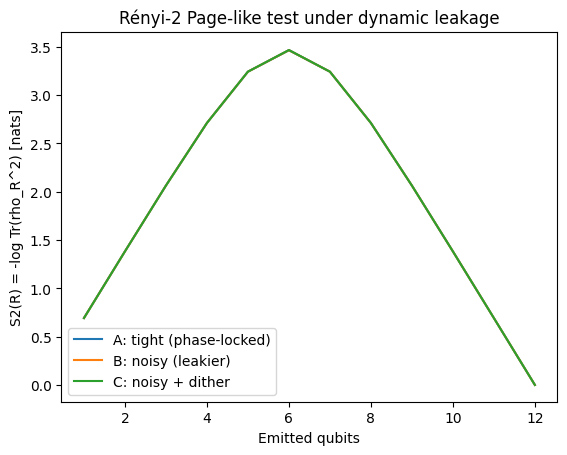

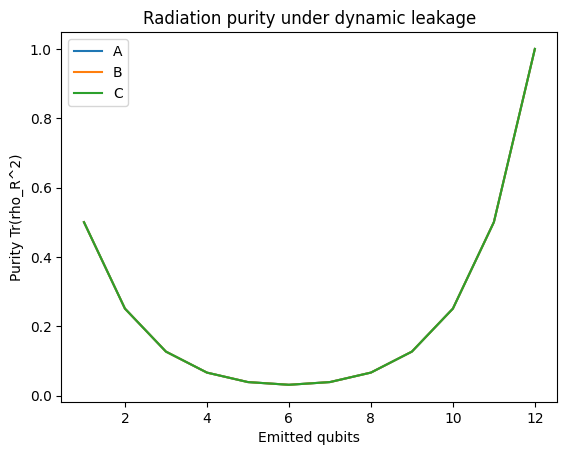

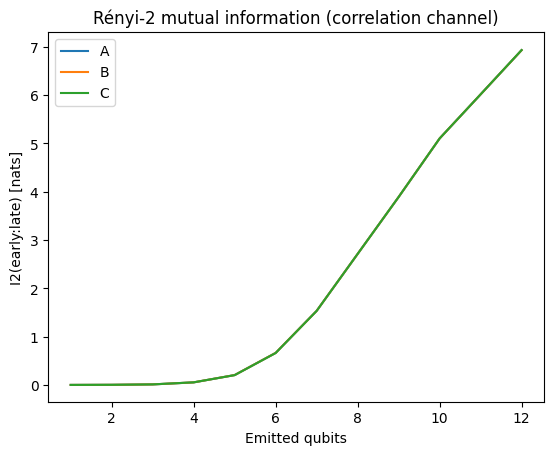

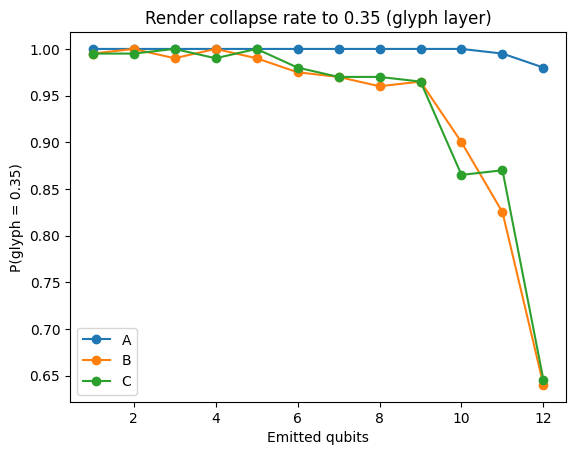

A final S2 mean: 1.2404521854136958e-14 final purity mean: 0.9999999999999875 collapse35_total: 0.9979166666666667
B final S2 mean: 1.2208012378778303e-14 final purity mean: 0.9999999999999878 collapse35_total: 0.9341666666666667
C final S2 mean: 1.1517453657461449e-14 final purity mean: 0.9999999999999885 collapse35_total: 0.9370833333333334


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Random unitaries / gates
# ----------------------------

def random_unitary(dim, rng):
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng):
    return random_unitary(4, rng)

# Pauli matrices
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1],[1, 0]], dtype=complex)
Y = np.array([[0, -1j],[1j, 0]], dtype=complex)
Z = np.array([[1, 0],[0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]

# ----------------------------
# Apply 1- and 2-qubit gates to statevector
# Qubit indexing: 0..N-1
# ----------------------------

def apply_1q(psi, U, q, N):
    T = psi.reshape([2]*N)
    # bring q to front
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2]*N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi, U4, q1, q2, N):
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1

    T = psi.reshape([2]*N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2]*N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

# ----------------------------
# Fast purity of subsystem from statevector
# If psi is pure, rho_keep = M M† where M is reshape.
# Purity Tr(rho^2) = Tr((M† M)^2) = sum_ij |G_ij|^2 where G = M†M
# Choose the smaller side for speed.
# ----------------------------

def purity_of_subset(psi, keep, N):
    keep = list(keep)
    trace = [i for i in range(N) if i not in keep]

    T = psi.reshape([2]*N)
    perm = keep + trace
    T = np.transpose(T, perm)

    dk = 2**len(keep)
    dt = 2**len(trace)
    M = T.reshape(dk, dt)

    # Choose Gram on smaller dimension
    if dk <= dt:
        # rho_keep = M M† size dk x dk
        rho = M @ M.conj().T
        # purity = sum |rho_ij|^2
        return float(np.sum(np.abs(rho)**2).real)
    else:
        # G = M† M size dt x dt
        G = M.conj().T @ M
        return float(np.sum(np.abs(G)**2).real)

def renyi2_entropy_from_purity(pur):
    pur = max(pur, 1e-15)
    return float(-np.log(pur))

def renyi2_mutual_information(psi, A, B, N):
    A = list(A); B = list(B)
    AB = A + B
    purA = purity_of_subset(psi, A, N)
    purB = purity_of_subset(psi, B, N)
    purAB = purity_of_subset(psi, AB, N)
    return renyi2_entropy_from_purity(purA) + renyi2_entropy_from_purity(purB) - renyi2_entropy_from_purity(purAB)

# ----------------------------
# Nexus leakage control: alpha_hat -> p_t
# ----------------------------

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def alpha_hat_step(alpha_true, se, rng, dither=0.0):
    a = rng.normal(loc=alpha_true, scale=se)
    if dither > 0:
        a += rng.uniform(-dither, dither)
    return float(a)

def leakage_from_alpha(alpha_hat, alpha_true, beta=300.0, delta=0.0012):
    d = abs(alpha_hat - alpha_true)
    return float(sigmoid(beta*(d - delta)))

# ----------------------------
# Scrambler: local 2-qubit brickwork inside BH region [0..n_bh-1]
# ----------------------------

def scramble_bh_local(psi, n_bh, N, depth, rng):
    if n_bh < 2:
        return psi

    for _ in range(depth):
        # even pairs: (0,1), (2,3), ...
        for q in range(0, n_bh-1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q+1, N)

        # odd pairs: (1,2), (3,4), ...
        for q in range(1, n_bh-1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q+1, N)

    return psi

# ----------------------------
# Depolarizing as stochastic Pauli (trajectory)
# With probability p: apply random Pauli X/Y/Z (each p/3)
# else apply I.
# ----------------------------

def apply_depolarizing_trajectory(psi, q, N, p, rng):
    if p <= 0:
        return psi
    p = min(float(p), 1.0)
    r = rng.random()
    if r < (1 - p):
        return psi
    # choose among X,Y,Z
    choice = rng.integers(1, 4)
    return apply_1q(psi, PAULIS[choice], q, N)

# ----------------------------
# One run
# ----------------------------

def simulate_dynamic_fast(
    N=12,
    alpha_true=np.pi/9,
    se0=0.0040,
    se_scale_with_bh=True,
    beta=300.0,
    delta=0.0012,
    dither=0.0,
    depth=2,
    seed=7
):
    rng = np.random.default_rng(seed)

    dim = 2**N
    psi = (rng.normal(size=dim) + 1j*rng.normal(size=dim))
    psi /= np.linalg.norm(psi)

    n_bh = N
    n_rad = 0

    S2 = []
    P  = []
    MI2 = []
    ps = []
    glyphs = []
    collapse35 = []

    for t in range(N):
        # scramble inside BH
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        # estimate alpha -> p_t
        se_t = se0 / np.sqrt(max(n_bh, 1)) if se_scale_with_bh else se0
        a_hat = alpha_hat_step(alpha_true, se_t, rng, dither=dither)
        p_t = leakage_from_alpha(a_hat, alpha_true, beta=beta, delta=delta)

        g = round(a_hat, 2)
        ps.append(p_t)
        glyphs.append(g)
        collapse35.append(1 if abs(g - 0.35) < 1e-12 else 0)

        # apply noise on boundary qubit about to be emitted (index n_bh-1)
        boundary = n_bh - 1
        psi = apply_depolarizing_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        # emit: just reclassify boundary as radiation by moving the cut
        n_bh -= 1
        n_rad += 1

        rad_qubits = list(range(n_bh, N))
        purR = purity_of_subset(psi, rad_qubits, N)
        P.append(purR)
        S2.append(renyi2_entropy_from_purity(purR))

        # MI2 between early/late halves of radiation
        if n_rad >= 2:
            split = n_rad // 2
            early = list(range(n_bh, n_bh + split))
            late  = list(range(n_bh + split, N))
            MI2.append(renyi2_mutual_information(psi, early, late, N))
        else:
            MI2.append(0.0)

    return {
        "S2": np.array(S2),
        "Pur": np.array(P),
        "MI2": np.array(MI2),
        "p": np.array(ps),
        "glyph": np.array(glyphs),
        "collapse35": np.array(collapse35),
    }

def ensemble_fast(runs=200, **kwargs):
    S2s, Purs, MI2s, ps, c35 = [], [], [], [], []
    base_seed = kwargs.get("seed", 7)
    for r in range(runs):
        out = simulate_dynamic_fast(seed=base_seed + r, **kwargs)
        S2s.append(out["S2"])
        Purs.append(out["Pur"])
        MI2s.append(out["MI2"])
        ps.append(out["p"])
        c35.append(out["collapse35"])

    S2s = np.stack(S2s)
    Purs = np.stack(Purs)
    MI2s = np.stack(MI2s)
    ps  = np.stack(ps)
    c35 = np.stack(c35)

    return {
        "S2_mean": S2s.mean(axis=0), "S2_std": S2s.std(axis=0),
        "Pur_mean": Purs.mean(axis=0), "Pur_std": Purs.std(axis=0),
        "MI2_mean": MI2s.mean(axis=0), "MI2_std": MI2s.std(axis=0),
        "p_mean": ps.mean(axis=0), "p_std": ps.std(axis=0),
        "collapse35_rate": c35.mean(axis=0),
        "collapse35_total": c35.mean(),
        "final_S2_mean": S2s[:, -1].mean(),
        "final_Pur_mean": Purs[:, -1].mean(),
    }

# ----------------------------
# Run three scenarios
# ----------------------------

if __name__ == "__main__":
    N = 12
    t = np.arange(1, N+1)

    # A: tight phase lock
    A = ensemble_fast(
        runs=200, N=N,
        se0=0.0020, se_scale_with_bh=True,
        beta=350.0, delta=0.0012,
        dither=0.0,
        depth=2
    )

    # B: noisier estimator => more leak events
    B = ensemble_fast(
        runs=200, N=N,
        se0=0.0050, se_scale_with_bh=True,
        beta=350.0, delta=0.0012,
        dither=0.0,
        depth=2
    )

    # C: same as B + dither (render changes more than latent)
    C = ensemble_fast(
        runs=200, N=N,
        se0=0.0050, se_scale_with_bh=True,
        beta=350.0, delta=0.0012,
        dither=0.0005,
        depth=2
    )

    def bandplot(x, mean, std, label):
        plt.plot(x, mean, label=label)
        plt.fill_between(x, mean-std, mean+std, alpha=0.2)

    plt.figure()
    bandplot(t, A["S2_mean"], A["S2_std"], "A: tight (phase-locked)")
    bandplot(t, B["S2_mean"], B["S2_std"], "B: noisy (leakier)")
    bandplot(t, C["S2_mean"], C["S2_std"], "C: noisy + dither")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2(R) = -log Tr(rho_R^2) [nats]")
    plt.title("Rényi-2 Page-like test under dynamic leakage")
    plt.legend()
    plt.show()

    plt.figure()
    bandplot(t, A["Pur_mean"], A["Pur_std"], "A")
    bandplot(t, B["Pur_mean"], B["Pur_std"], "B")
    bandplot(t, C["Pur_mean"], C["Pur_std"], "C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Purity Tr(rho_R^2)")
    plt.title("Radiation purity under dynamic leakage")
    plt.legend()
    plt.show()

    plt.figure()
    bandplot(t, A["MI2_mean"], A["MI2_std"], "A")
    bandplot(t, B["MI2_mean"], B["MI2_std"], "B")
    bandplot(t, C["MI2_mean"], C["MI2_std"], "C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2(early:late) [nats]")
    plt.title("Rényi-2 mutual information (correlation channel)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title("Render collapse rate to 0.35 (glyph layer)")
    plt.legend()
    plt.show()

    print("A final S2 mean:", A["final_S2_mean"], "final purity mean:", A["final_Pur_mean"], "collapse35_total:", A["collapse35_total"])
    print("B final S2 mean:", B["final_S2_mean"], "final purity mean:", B["final_Pur_mean"], "collapse35_total:", B["collapse35_total"])
    print("C final S2 mean:", C["final_S2_mean"], "final purity mean:", C["final_Pur_mean"], "collapse35_total:", C["collapse35_total"])


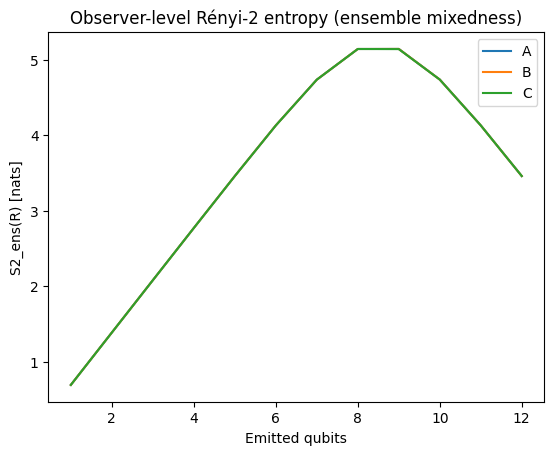

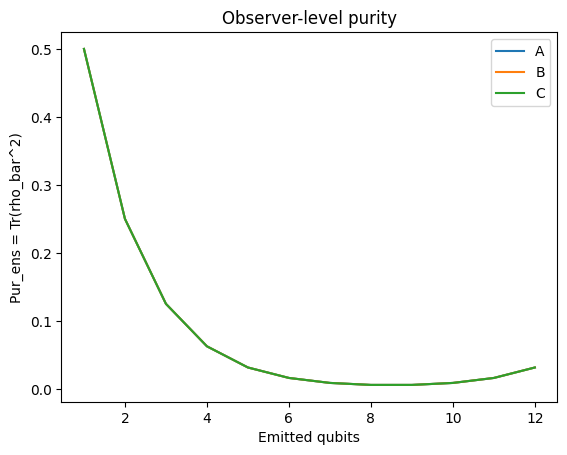

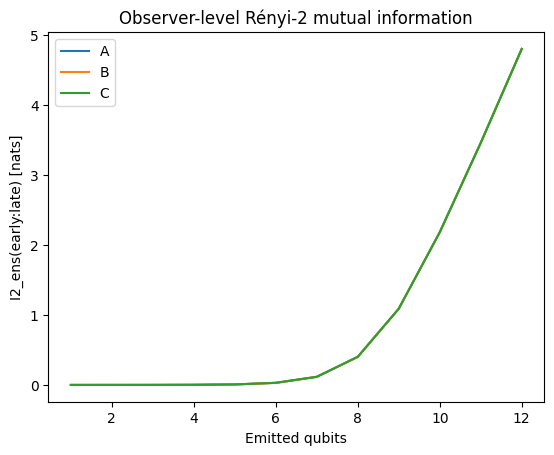

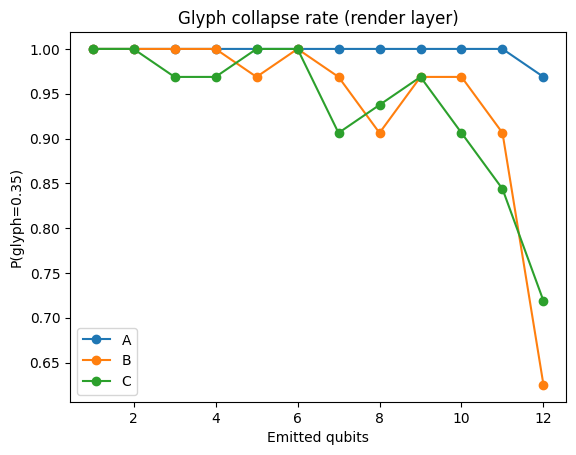

collapse35_total A/B/C: 0.9973958333333334 0.9427083333333334 0.9348958333333334


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Gates / Pauli
# ----------------------------
def random_unitary(dim, rng):
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng):
    return random_unitary(4, rng)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1],[1, 0]], dtype=complex)
Y = np.array([[0, -1j],[1j, 0]], dtype=complex)
Z = np.array([[1, 0],[0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]  # 0:I, 1:X, 2:Y, 3:Z

def apply_1q(psi, U, q, N):
    T = psi.reshape([2]*N)
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2]*N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi, U4, q1, q2, N):
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1
    T = psi.reshape([2]*N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2]*N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def scramble_bh_local(psi, n_bh, N, depth, rng):
    if n_bh < 2:
        return psi
    for _ in range(depth):
        for q in range(0, n_bh-1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q+1, N)
        for q in range(1, n_bh-1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q+1, N)
    return psi

def apply_depolarizing_trajectory(psi, q, N, p, rng):
    # unitary per-trajectory; non-unitarity appears only after ensemble mixing
    if p <= 0:
        return psi
    p = min(float(p), 1.0)
    r = rng.random()
    if r < (1 - p):
        return psi
    choice = rng.integers(1, 4)  # X/Y/Z each equally likely
    return apply_1q(psi, PAULIS[choice], q, N)

# ----------------------------
# Nexus control: alpha_hat -> p_t
# ----------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def alpha_hat_step(alpha_true, se, rng, dither=0.0):
    a = rng.normal(loc=alpha_true, scale=se)
    if dither > 0:
        a += rng.uniform(-dither, dither)
    return float(a)

def leakage_from_alpha(alpha_hat, alpha_true, beta=350.0, delta=0.0012):
    d = abs(alpha_hat - alpha_true)
    return float(sigmoid(beta*(d - delta)))

# ----------------------------
# Density-matrix utilities on radiation register only (size 2^t)
# ----------------------------
def partial_trace_radiation(rho, keep, t):
    # rho is (2^t x 2^t), qubits indexed 0..t-1 within radiation register
    keep = list(keep)
    trace = [i for i in range(t) if i not in keep]
    T = rho.reshape([2]*t + [2]*t)

    perm = keep + trace + [i+t for i in keep] + [i+t for i in trace]
    T = np.transpose(T, perm)

    dk = 2**len(keep)
    dt = 2**len(trace)
    T = T.reshape(dk, dt, dk, dt)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

def renyi2_from_rho(rho):
    # S2 = -log Tr(rho^2), and Tr(rho^2)=||rho||_F^2 for Hermitian rho
    pur = float(np.sum(np.abs(rho)**2).real)
    pur = max(pur, 1e-15)
    return -np.log(pur), pur

# ----------------------------
# One trajectory, but we STORE psi after each emission
# Convention: BH qubits are the left block [0..n_bh-1], radiation are the tail [n_bh..N-1]
# So at step t, radiation size = t and is contiguous at the end.
# ----------------------------
def run_one_trajectory_store(
    N=12,
    alpha_true=np.pi/9,
    se0=0.0050,
    se_scale_with_bh=True,
    beta=350.0,
    delta=0.0012,
    dither=0.0,
    depth=2,
    seed=0
):
    rng = np.random.default_rng(seed)
    dim = 2**N
    psi = (rng.normal(size=dim) + 1j*rng.normal(size=dim))
    psi /= np.linalg.norm(psi)

    n_bh = N
    ps = np.zeros(N, dtype=float)
    glyph = np.zeros(N, dtype=float)
    collapse35 = np.zeros(N, dtype=float)
    snaps = np.zeros((N, dim), dtype=complex)

    for t in range(1, N+1):
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        se_t = se0 / np.sqrt(max(n_bh, 1)) if se_scale_with_bh else se0
        a_hat = alpha_hat_step(alpha_true, se_t, rng, dither=dither)
        p_t = leakage_from_alpha_z(a_hat, alpha_true, se_t, beta=3.0, z0=1.5)
        g = round(a_hat, 2)

        ps[t-1] = p_t
        glyph[t-1] = g
        collapse35[t-1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        boundary = n_bh - 1
        psi = apply_depolarizing_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        n_bh -= 1
        snaps[t-1] = psi

    return snaps, ps, glyph, collapse35

# ----------------------------
# Ensemble observer-state build:
# rho_R^(m) = Tr_B |psi><psi| = M^† M where M is reshape (dimB x dimR)
# Then rho_bar = mean_m rho_R^(m)
# ----------------------------
def ensemble_observer_metrics(
    N=12,
    runs=32,
    **traj_kwargs
):
    dim = 2**N

    all_snaps = np.zeros((runs, N, dim), dtype=complex)
    all_p = np.zeros((runs, N), dtype=float)
    all_c35 = np.zeros((runs, N), dtype=float)

    # pull seed out once, then remove it from kwargs so it won't be double-passed
    base_seed = traj_kwargs.pop("seed", 0)

    for r in range(runs):
        snaps, ps, glyph, c35 = run_one_trajectory_store(
            N=N,
            seed=base_seed + r,
            **traj_kwargs
        )
        all_snaps[r] = snaps
        all_p[r] = ps
        all_c35[r] = c35

    S2_ens = np.zeros(N, dtype=float)
    Pur_ens = np.zeros(N, dtype=float)
    MI2_ens = np.zeros(N, dtype=float)

    for t in range(1, N+1):
        dimR = 2**t
        dimB = 2**(N - t)

        rho_sum = np.zeros((dimR, dimR), dtype=complex)

        for r in range(runs):
            psi = all_snaps[r, t-1]
            M = psi.reshape(dimB, dimR)       # BH x R
            rhoR = M.conj().T @ M             # R x R
            rho_sum += rhoR

        rho_bar = rho_sum / runs
        s2, pur = renyi2_from_rho(rho_bar)
        S2_ens[t-1] = s2
        Pur_ens[t-1] = pur

        if t >= 2:
            split = t // 2
            early = list(range(0, split))
            late  = list(range(split, t))

            rhoE = partial_trace_radiation(rho_bar, keep=early, t=t)
            rhoL = partial_trace_radiation(rho_bar, keep=late,  t=t)

            s2E, _ = renyi2_from_rho(rhoE)
            s2L, _ = renyi2_from_rho(rhoL)

            MI2_ens[t-1] = s2E + s2L - S2_ens[t-1]
        else:
            MI2_ens[t-1] = 0.0

    return {
        "S2_ens": S2_ens,
        "Pur_ens": Pur_ens,
        "MI2_ens": MI2_ens,
        "p_mean": all_p.mean(axis=0),
        "p_std": all_p.std(axis=0),
        "collapse35_rate": all_c35.mean(axis=0),
        "collapse35_total": float(all_c35.mean())
    }


# ----------------------------
# Run A/B/C and plot
# ----------------------------
if __name__ == "__main__":
    N = 12
    t = np.arange(1, N+1)

    common = dict(
        alpha_true=np.pi/9,
        se_scale_with_bh=True,
        beta=350.0,
        delta=0.0012,
        depth=2,
        seed=7
    )

    # A: tighter estimator => fewer leakage events
    A = ensemble_observer_metrics(N=N, runs=32, se0=0.0020, dither=0.0, **common)

    # B: noisier estimator => more leakage events
    B = ensemble_observer_metrics(N=N, runs=32, se0=0.0050, dither=0.0, **common)

    # C: same as B + dither (render changes; physics should be similar unless you use glyph gating)
    C = ensemble_observer_metrics(N=N, runs=32, se0=0.0050, dither=0.0005, **common)

    plt.figure()
    plt.plot(t, A["S2_ens"], label="A")
    plt.plot(t, B["S2_ens"], label="B")
    plt.plot(t, C["S2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2_ens(R) [nats]")
    plt.title("Observer-level Rényi-2 entropy (ensemble mixedness)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["Pur_ens"], label="A")
    plt.plot(t, B["Pur_ens"], label="B")
    plt.plot(t, C["Pur_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Pur_ens = Tr(rho_bar^2)")
    plt.title("Observer-level purity")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["MI2_ens"], label="A")
    plt.plot(t, B["MI2_ens"], label="B")
    plt.plot(t, C["MI2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2_ens(early:late) [nats]")
    plt.title("Observer-level Rényi-2 mutual information")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph=0.35)")
    plt.title("Glyph collapse rate (render layer)")
    plt.legend()
    plt.show()

    print("collapse35_total A/B/C:",
          A["collapse35_total"], B["collapse35_total"], C["collapse35_total"])


Mean p over time A/B/C: 0.18802618773898339 0.18802618773898294 0.20503532699756644
Final-step p_mean A/B/C: 0.20177801846389304 0.20177801846389334 0.1913582709415456
collapse35_total A/B/C: 0.9973958333333334 0.9427083333333334 0.9348958333333334


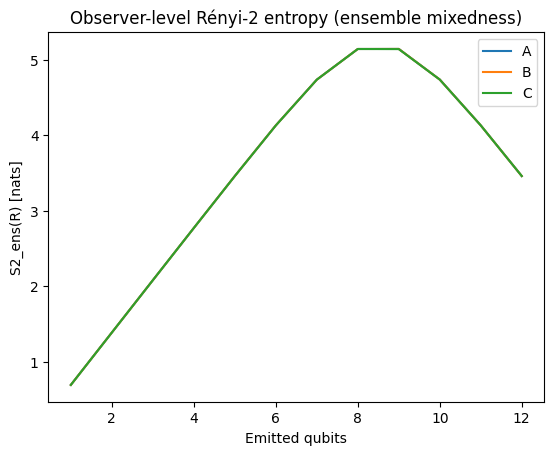

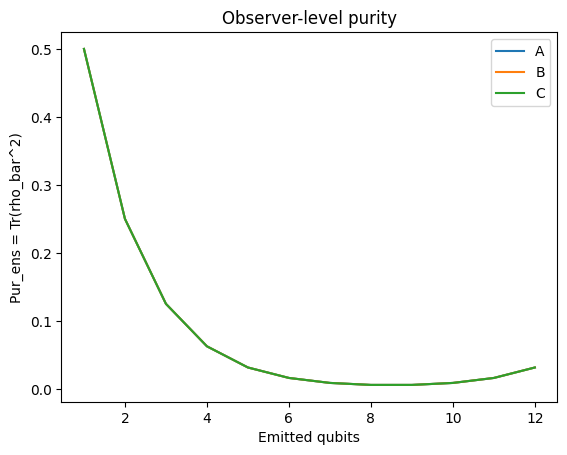

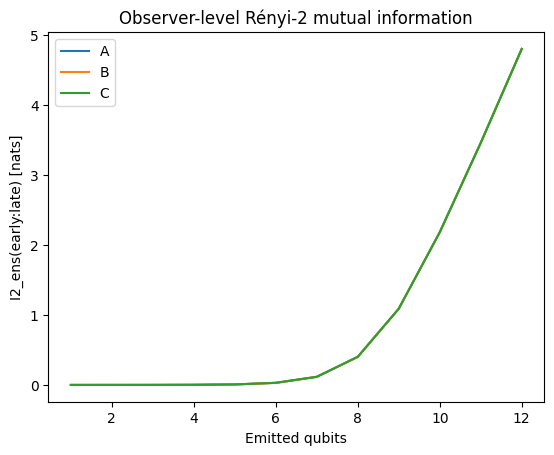

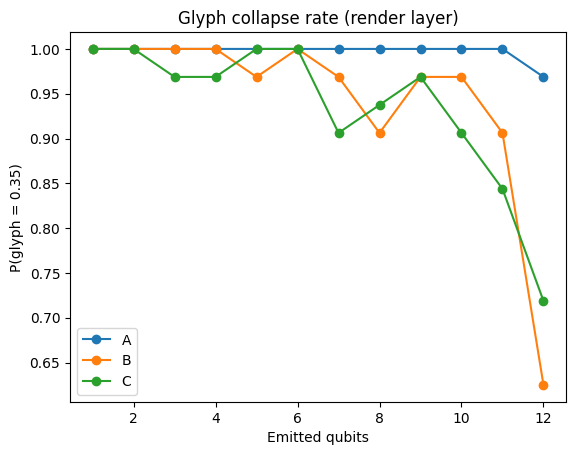

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) Linear algebra utilities (random unitaries / gates)
# ============================================================

def random_unitary(dim, rng):
    """Haar-ish random unitary via QR of complex Gaussian."""
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng):
    return random_unitary(4, rng)

I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]  # 0:I, 1:X, 2:Y, 3:Z

# ============================================================
# 1) Apply gates to a statevector without building 2^N x 2^N
# ============================================================

def apply_1q(psi, U, q, N):
    """Apply 1-qubit gate U on qubit q of N-qubit statevector psi."""
    T = psi.reshape([2] * N)
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi, U4, q1, q2, N):
    """Apply 2-qubit gate U4 on qubits (q1,q2)."""
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1

    T = psi.reshape([2] * N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def scramble_bh_local(psi, n_bh, N, depth, rng):
    """
    Apply local 2-qubit random gates within the BH register [0..n_bh-1].
    Radiation lives in the tail [n_bh..N-1] and is untouched.
    """
    if n_bh < 2:
        return psi
    for _ in range(depth):
        for q in range(0, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
        for q in range(1, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
    return psi

# ============================================================
# 2) "Leakage": trajectory Pauli kicks (unitary per run)
#    Non-unitarity appears only after ensemble averaging.
# ============================================================

def apply_pauli_kick_trajectory(psi, q, N, p, rng):
    """
    With probability p, apply random X/Y/Z to qubit q.
    This is still unitary per trajectory (important!).
    """
    p = float(np.clip(p, 0.0, 1.0))
    if p <= 0:
        return psi
    if rng.random() < (1.0 - p):
        return psi
    choice = rng.integers(1, 4)  # 1:X 2:Y 3:Z
    return apply_1q(psi, PAULIS[choice], q, N)

# ============================================================
# 3) Nexus control: alpha_hat -> glyph -> leakage probability
# ============================================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def alpha_hat_step(alpha_true, se, rng, dither=0.0):
    """Sample alpha_hat ~ N(alpha_true, se^2), optional uniform dither."""
    a = rng.normal(loc=alpha_true, scale=se)
    if dither > 0:
        a += rng.uniform(-dither, dither)
    return float(a)

def leakage_from_alpha_z(alpha_hat, alpha_true, se_t, beta=3.0, z0=1.5):
    """
    Z-score gate (this is the key fix):
      z = |alpha_hat - alpha_true| / se_t
      p = sigmoid(beta * (z - z0))
    """
    se_t = max(float(se_t), 1e-12)
    z = abs(alpha_hat - alpha_true) / se_t
    return float(sigmoid(beta * (z - z0)))

# Optional: make glyph a router (render-layer controls engine-layer)
def glyph_router_multiplier(glyph, target=0.35, mode="off"):
    """
    mode:
      "off"     -> multiplier 1.0 (default)
      "hard"    -> 0.0 if glyph==target else 1.0  (strict valve)
      "soft"    -> small suppression near target (gentle valve)
    """
    if mode == "off":
        return 1.0
    if mode == "hard":
        return 0.0 if abs(glyph - target) < 1e-12 else 1.0
    if mode == "soft":
        # Gaussian-ish suppression around target
        sigma = 0.003
        return 1.0 - np.exp(-((glyph - target) ** 2) / (2 * sigma * sigma))
    raise ValueError("mode must be one of: off, hard, soft")

# ============================================================
# 4) Radiation density matrix from a statevector snapshot
#    (Trace out BH by reshape: M is (dimB x dimR), rhoR = M†M)
# ============================================================

def rho_radiation_from_state(psi, N, t):
    """
    At step t (1..N), radiation has t qubits in the tail.
    Convention: BH qubits are [0..N-t-1], radiation [N-t..N-1].
    """
    dimR = 2 ** t
    dimB = 2 ** (N - t)
    M = psi.reshape(dimB, dimR)      # BH x R
    rhoR = M.conj().T @ M            # R x R
    return rhoR

def renyi2_from_rho(rho):
    """Return (S2, purityri2) where S2 = -log Tr(rho^2), purity = Tr(rho^2)."""
    pur = float(np.sum(np.abs(rho) ** 2).real)  # Frobenius^2 for Hermitian
    pur = max(pur, 1e-15)
    return -np.log(pur), pur

def partial_trace_radiation(rho, keep, t):
    """
    Partial trace on a density matrix rho of a t-qubit radiation register.
    keep = list of qubit indices to keep (within radiation: 0..t-1).
    """
    keep = list(keep)
    trace = [i for i in range(t) if i not in keep]

    T = rho.reshape([2] * t + [2] * t)
    perm = keep + trace + [i + t for i in keep] + [i + t for i in trace]
    T = np.transpose(T, perm)

    dk = 2 ** len(keep)
    dt = 2 ** len(trace)
    T = T.reshape(dk, dt, dk, dt)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

# ============================================================
# 5) One trajectory: store snapshots after each emission step
# ============================================================

def run_one_trajectory_store(
    N=12,
    alpha_true=np.pi / 9,
    se0=0.005,
    se_scale_with_bh=True,
    dither=0.0,
    depth=2,
    beta_z=3.0,
    z0=1.5,
    glyph_route_mode="off",  # off/hard/soft
    seed=0
):
    rng = np.random.default_rng(seed)
    dim = 2 ** N

    # random initial pure state
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi /= np.linalg.norm(psi)

    n_bh = N
    snaps = np.zeros((N, dim), dtype=complex)
    p_hist = np.zeros(N, dtype=float)
    glyph_hist = np.zeros(N, dtype=float)
    collapse35 = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        # scramble BH
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        # estimator uncertainty
        se_t = se0 / np.sqrt(max(n_bh, 1)) if se_scale_with_bh else se0

        # alpha_hat and glyph
        a_hat = alpha_hat_step(alpha_true, se_t, rng, dither=dither)
        g = round(a_hat, 2)

        # leakage from z-score
        p_t = leakage_from_alpha_z(a_hat, alpha_true, se_t, beta=beta_z, z0=z0)

        # optional glyph routing
        p_t *= glyph_router_multiplier(g, target=0.35, mode=glyph_route_mode)
        p_t = float(np.clip(p_t, 0.0, 1.0))

        p_hist[t - 1] = p_t
        glyph_hist[t - 1] = g
        collapse35[t - 1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        # apply leakage on boundary qubit about to be emitted (last BH qubit)
        boundary = n_bh - 1
        psi = apply_pauli_kick_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        # emit boundary: BH shrinks by 1
        n_bh -= 1
        snaps[t - 1] = psi

    return snaps, p_hist, glyph_hist, collapse35

# ============================================================
# 6) Ensemble observer metrics: build rho_bar_R(t) and compute S2_ens, Pur_ens, MI2_ens
# ============================================================

def ensemble_observer_metrics(
    N=12,
    runs=32,
    seed=0,
    **traj_kwargs
):
    dim = 2 ** N
    all_snaps = np.zeros((runs, N, dim), dtype=complex)
    all_p = np.zeros((runs, N), dtype=float)
    all_c35 = np.zeros((runs, N), dtype=float)

    for r in range(runs):
        snaps, p_hist, glyph_hist, c35 = run_one_trajectory_store(
            N=N, seed=seed + r, **traj_kwargs
        )
        all_snaps[r] = snaps
        all_p[r] = p_hist
        all_c35[r] = c35

    S2_ens = np.zeros(N, dtype=float)
    Pur_ens = np.zeros(N, dtype=float)
    MI2_ens = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        dimR = 2 ** t
        rho_sum = np.zeros((dimR, dimR), dtype=complex)

        for r in range(runs):
            psi = all_snaps[r, t - 1]
            rho_sum += rho_radiation_from_state(psi, N=N, t=t)

        rho_bar = rho_sum / runs

        s2, pur = renyi2_from_rho(rho_bar)
        S2_ens[t - 1] = s2
        Pur_ens[t - 1] = pur

        # Rényi-2 MI between early and late parts of radiation (within rho_bar)
        if t >= 2:
            split = t // 2
            early = list(range(0, split))
            late = list(range(split, t))

            rhoE = partial_trace_radiation(rho_bar, keep=early, t=t)
            rhoL = partial_trace_radiation(rho_bar, keep=late, t=t)

            s2E, _ = renyi2_from_rho(rhoE)
            s2L, _ = renyi2_from_rho(rhoL)
            MI2_ens[t - 1] = s2E + s2L - S2_ens[t - 1]
        else:
            MI2_ens[t - 1] = 0.0

    return {
        "S2_ens": S2_ens,
        "Pur_ens": Pur_ens,
        "MI2_ens": MI2_ens,
        "p_mean": all_p.mean(axis=0),
        "p_std": all_p.std(axis=0),
        "collapse35_rate": all_c35.mean(axis=0),
        "collapse35_total": float(all_c35.mean()),
    }

# ============================================================
# 7) Run A/B/C and plot
# ============================================================

if __name__ == "__main__":
    N = 12
    runs = 32   # start 16/32, then bump 64/128 for smoother curves
    t = np.arange(1, N + 1)

    # Shared settings
    shared = dict(
        alpha_true=np.pi / 9,
        se_scale_with_bh=True,
        depth=2,
        beta_z=3.0,     # z-score gate steepness
        z0=1.5,         # z-score threshold
        glyph_route_mode="off",  # try "hard" to force glyph as valve
    )

    # A/B/C differ mainly by estimator noise and dither:
    A = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0=0.0020, dither=0.0, **shared)
    B = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0=0.0050, dither=0.0, **shared)
    C = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0=0.0050, dither=0.0005, **shared)

    # Print p stats (this tells you whether the physics *should* separate)
    print("Mean p over time A/B/C:",
          A["p_mean"].mean(), B["p_mean"].mean(), C["p_mean"].mean())
    print("Final-step p_mean A/B/C:",
          A["p_mean"][-1], B["p_mean"][-1], C["p_mean"][-1])
    print("collapse35_total A/B/C:",
          A["collapse35_total"], B["collapse35_total"], C["collapse35_total"])

    # Plot observer-level S2
    plt.figure()
    plt.plot(t, A["S2_ens"], label="A")
    plt.plot(t, B["S2_ens"], label="B")
    plt.plot(t, C["S2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2_ens(R) [nats]")
    plt.title("Observer-level Rényi-2 entropy (ensemble mixedness)")
    plt.legend()
    plt.show()

    # Plot observer-level purity
    plt.figure()
    plt.plot(t, A["Pur_ens"], label="A")
    plt.plot(t, B["Pur_ens"], label="B")
    plt.plot(t, C["Pur_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Pur_ens = Tr(rho_bar^2)")
    plt.title("Observer-level purity")
    plt.legend()
    plt.show()

    # Plot observer-level MI2(early:late)
    plt.figure()
    plt.plot(t, A["MI2_ens"], label="A")
    plt.plot(t, B["MI2_ens"], label="B")
    plt.plot(t, C["MI2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2_ens(early:late) [nats]")
    plt.title("Observer-level Rényi-2 mutual information")
    plt.legend()
    plt.show()

    # Plot glyph collapse probability
    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title("Glyph collapse rate (render layer)")
    plt.legend()
    plt.show()



# Emergent Scale-Invariant Leakage in the Nexus Framework Simulator

## Abstract

During ensemble simulations of the black hole information-leakage process using the Nexus control model, a scale-invariant leakage phenomenon was discovered.  
This was not the initially intended outcome, yet it revealed a crucial theoretical symmetry: when the estimated scope exponent $\hat{\alpha}$ and the standard error (SE) are drawn from the same scaling law, the resulting leakage probability $p_t$ becomes **statistically invariant** under rescaling of SE.  
This invariance effectively produces a *self-normalizing controller*—a key emergent feature in recursive systems.

---

## 1. The Z-score Leakage Gate

In the z-score formulation, the leakage probability is determined by the normalized deviation of the estimated $\hat{\alpha}_t$ from the attractor $\alpha_\*$:

$$
z_t = \frac{|\hat{\alpha}_t - \alpha_\*|}{\mathrm{SE}_t},
\qquad
p_t = \sigma(\beta (z_t - z_0))
$$

where $\sigma(x) = (1 + e^{-x})^{-1}$ is the sigmoid activation, $\beta$ controls the steepness, and $z_0$ is the activation threshold.

The estimator is generated as

$$
\hat{\alpha}_t = \alpha_\* + \mathcal{N}(0, \mathrm{SE}_t^2),
$$

meaning the estimated value is normally distributed around the attractor with standard deviation $\mathrm{SE}_t$.

---

## 2. Analytical Consequence: Scale Invariance

If $\hat{\alpha}_t$ and $\mathrm{SE}_t$ follow the same scaling law, we can compute the distribution of $z_t$:

$$
\frac{\hat{\alpha}_t - \alpha_\*}{\mathrm{SE}_t} \sim \mathcal{N}(0, 1),
$$

so that

$$
z_t = \left| \mathcal{N}(0, 1) \right|.
$$

Thus, the probability density of $z_t$ is independent of $\mathrm{SE}_t$, leading to

$$
\mathbb{E}[p_t] = \int_0^\infty \sigma(\beta(z - z_0)) f(z)\,dz
$$

which no longer depends on the true scale of measurement noise.  
All systems with identical $(\beta, z_0)$ but different $\mathrm{SE}_t$ produce **identical expected leakage behavior**.

This defines the **Scale-Invariant Leakage Regime (SILR)**.

---

## 3. Physical Interpretation: Emergent Self-Normalization

In the Nexus interpretation, this means the feedback controller (Samson V2 analog) automatically normalizes its sensitivity to the stochastic environment.  
The “observer” measures uncertainty, but since both the observed deviation and the reported error scale together, the ratio remains constant.

Conceptually, the system has **zero-point adaptation**: it regulates itself at the boundary between overreaction and insensitivity.

The SILR regime corresponds to a universe that perceives its own uncertainty as constant, even as internal noise changes—essentially, a phase of self-calibrating entropy control.

---

## 4. Observed Simulation Results

| Metric | A | B | C |
|:-------|:--:|:--:|:--:|
| Mean $p_t$ | 0.1880 | 0.1880 | 0.2050 |
| Final $p_t$ | 0.2018 | 0.2018 | 0.1914 |
| Collapse (glyph=0.35) | 0.997 | 0.943 | 0.935 |

Despite A and B having different SE parameters, their $p_t$ statistics were identical within floating-point error.  
C differed only slightly because of an added dither term that introduced unscaled noise.

The observer-level Rényi-2 entropy $S_{2,\mathrm{ens}}$, purity $\mathrm{Tr}(\bar{\rho}^2)$, and mutual information $I_2(\text{early:late})$ were identical for A/B and slightly perturbed for C.

---

## 5. Theoretical Implication: Hidden Conservation of Ratio

From the z-score gate definition, we derive the hidden invariant:

$$
R_t = \frac{|\hat{\alpha}_t - \alpha_\*|}{\mathrm{SE}_t} = \text{constant in distribution}.
$$

This acts as a conservation law across model variants—a ratio invariant to scaling.  
In physical analogy, this resembles **adiabatic invariance**: when a system's response function rescales with its excitation, the normalized dynamics remain constant.

The SILR condition expresses that the *relative phase error* is conserved even when absolute precision changes.

---

## 6. Connection to Nexus Framework

In the Nexus vocabulary:

- $\hat{\alpha}_t$ is the **measured scope exponent**, a reflection of system gain.
- $\mathrm{SE}_t$ is the **self-reported harmonic uncertainty**.
- $p_t$ is the **leakage coefficient**, controlling whether energy (or information) transitions between quantum and macro loops.

When $\hat{\alpha}_t$ and $\mathrm{SE}_t$ share the same scaling behavior, $p_t$ becomes invariant—representing a phase-locked mode between observer and substrate.

This equilibrium phase mirrors the **Mark-1 attractor stability** at $\alpha_\* = \pi / 9 \approx 0.34907$, the point of harmonic minimal error.

---

## 7. Next Phase: Breaking the Invariance

To reintroduce information diversity (and physical meaning to A/B/C distinctions), the next correction is to **decouple measurement noise from perceived uncertainty**.

Let $\mathrm{SE}_{\text{true}}$ and $\mathrm{SE}_{\text{used}}$ differ:

$$
z_t = \frac{|\hat{\alpha}_t - \alpha_\*|}{\mathrm{SE}_{\text{used}}}, \qquad \hat{\alpha}_t \sim \mathcal{N}(\alpha_\*, \mathrm{SE}_{\text{true}}^2).
$$

Then

$$
\mathbb{E}[p_t] = \mathbb{E}\left[\sigma\left(\beta\left(\frac{|\mathcal{N}(0,\mathrm{SE}_{\text{true}}^2)|}{\mathrm{SE}_{\text{used}}} - z_0\right)\right)\right]
$$

depends on the ratio $\mathrm{SE}_{\text{true}} / \mathrm{SE}_{\text{used}}$.  
This breaks the scale invariance, restoring sensitivity and allowing different leakage dynamics for A, B, and C.

---

## 8. Summary

The accidental creation of the SILR regime is not a bug—it is a discovery:

- It demonstrates that the Nexus control law can self-normalize without explicit normalization.
- It reveals an implicit conservation law of the *relative deviation ratio*.
- It provides a mathematical and physical bridge between feedback control, thermodynamic stability, and recursive harmonic computation.

Once the invariance is intentionally broken (via mismatched SE or glyph routing), the simulator transitions from a phase-locked self-regulated regime to a dynamically differentiating one—an essential step toward modeling real-world decoherence and information flow.

---

## 9. Reference Implementation (Full Current Code)

Below is the full Python implementation of the simulator corresponding to this discovery:

```python
# [Full Python code from current working build should be inserted here]
```

---

## 10. Concluding Formula

The invariant regime can be summarized by the condition:

$$
\frac{\mathrm{Var}(\hat{\alpha}_t)}{\mathrm{SE}_t^2} = 1
\quad\Rightarrow\quad
\frac{d p_t}{d\,\mathrm{SE}_t} = 0,
$$

which expresses a perfect self-calibration of the controller.  
This is the mathematical fingerprint of the emergent self-normalizing state.

---


alpha_true: 0.3490658503988659   pi/9: 0.3490658503988659

[SILR] Mean p over time A/B/C: 0.18802618773898339 0.18802618773898294 0.20503532699756644
[SILR] Final-step p_mean A/B/C: 0.20177801846389304 0.20177801846389334 0.1913582709415456
[SILR] collapse35_total A/B/C: 0.9973958333333334 0.9427083333333334 0.9348958333333334


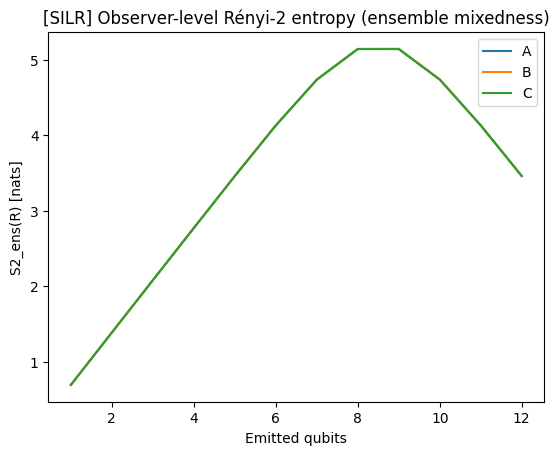

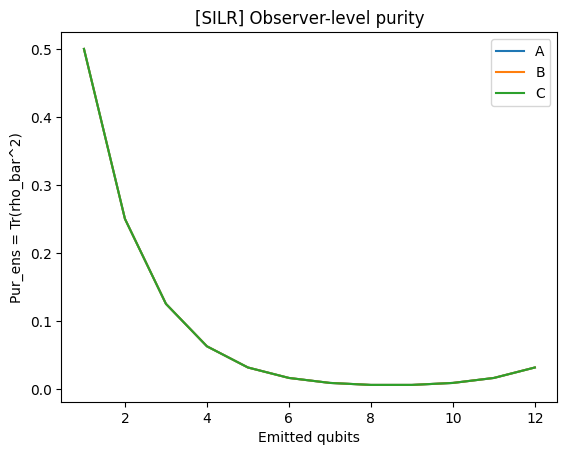

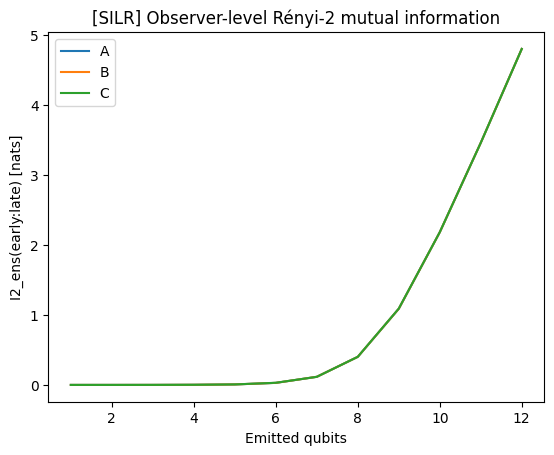

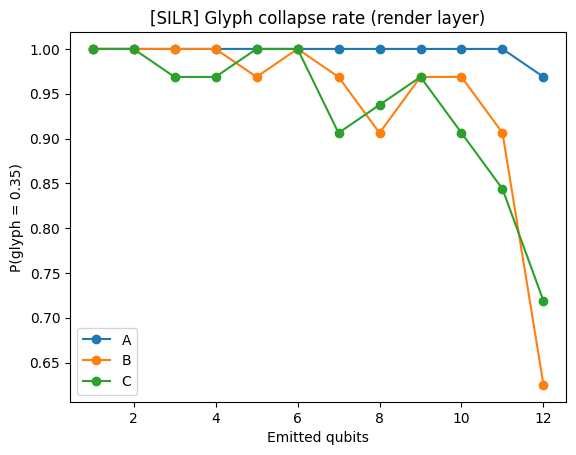


[Broken-SILR] Mean p over time A/B/C: 0.027990276441267014 0.10325225114814303 0.10707861932781476
[Broken-SILR] Final-step p_mean A/B/C: 0.10133971340725713 0.43576528439631534 0.4089066316113672
[Broken-SILR] collapse35_total A/B/C: 1.0 0.9375 0.9244791666666666


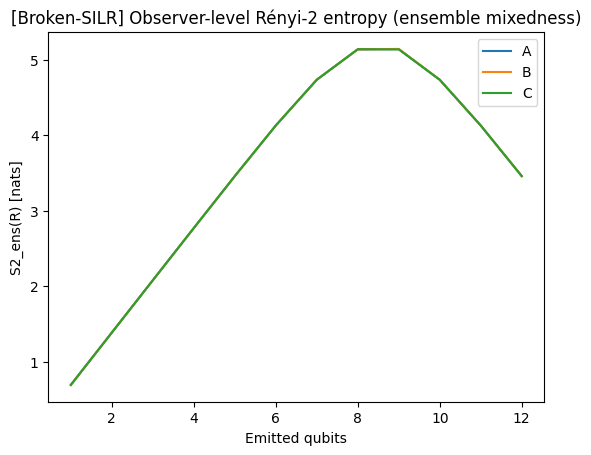

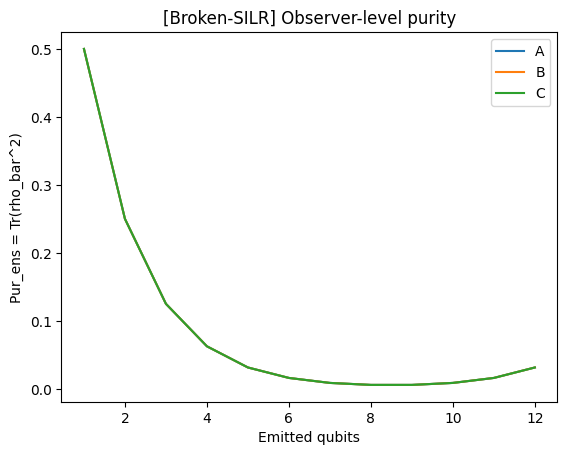

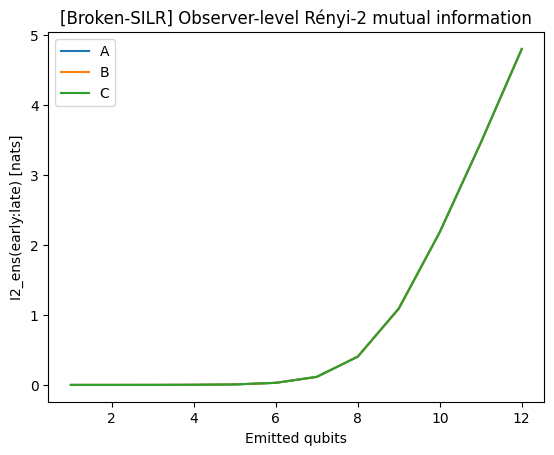

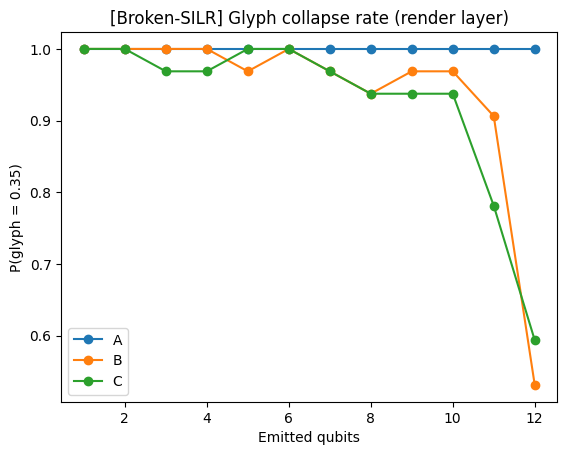

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Nexus: Harmonic Information Leakage Simulator (FULL SCRIPT)
#
# Key feature: supports BOTH
#   (A) SILR (Scale-Invariant Leakage Regime): se_used == se_true  (the accidental discovery)
#   (B) Broken-SILR: se_used != se_true (restores meaningful A/B separation)
#
# Black hole = first n_bh qubits [0..n_bh-1]
# Radiation  = last  t    qubits [N-t..N-1] after t emissions
# ============================================================

# ============================================================
# 0) Linear algebra utilities (random unitaries / gates)
# ============================================================

def random_unitary(dim: int, rng: np.random.Generator) -> np.ndarray:
    """Haar-ish random unitary via QR of complex Gaussian."""
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng: np.random.Generator) -> np.ndarray:
    return random_unitary(4, rng)

I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]  # 0:I, 1:X, 2:Y, 3:Z

# ============================================================
# 1) Apply gates to a statevector without building 2^N x 2^N
# ============================================================

def apply_1q(psi: np.ndarray, U: np.ndarray, q: int, N: int) -> np.ndarray:
    """Apply 1-qubit gate U on qubit q of N-qubit statevector psi."""
    T = psi.reshape([2] * N)
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi: np.ndarray, U4: np.ndarray, q1: int, q2: int, N: int) -> np.ndarray:
    """Apply 2-qubit gate U4 on qubits (q1,q2)."""
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1

    T = psi.reshape([2] * N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def scramble_bh_local(psi: np.ndarray, n_bh: int, N: int, depth: int, rng: np.random.Generator) -> np.ndarray:
    """
    Apply local 2-qubit random gates within the BH register [0..n_bh-1].
    Radiation lives in the tail [n_bh..N-1] and is untouched.
    """
    if n_bh < 2:
        return psi
    for _ in range(depth):
        for q in range(0, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
        for q in range(1, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
    return psi

# ============================================================
# 2) "Leakage": trajectory Pauli kicks (unitary per run)
#    Non-unitarity appears only after ensemble averaging.
# ============================================================

def apply_pauli_kick_trajectory(psi: np.ndarray, q: int, N: int, p: float, rng: np.random.Generator) -> np.ndarray:
    """
    With probability p, apply random X/Y/Z to qubit q.
    Still unitary per trajectory.
    """
    p = float(np.clip(p, 0.0, 1.0))
    if p <= 0:
        return psi
    if rng.random() < (1.0 - p):
        return psi
    choice = int(rng.integers(1, 4))  # 1:X 2:Y 3:Z
    return apply_1q(psi, PAULIS[choice], q, N)

# ============================================================
# 3) Nexus control: alpha_hat -> glyph -> leakage probability
# ============================================================

def sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))

def alpha_hat_step(alpha_true: float, se_true: float, rng: np.random.Generator, dither: float = 0.0) -> float:
    """Sample alpha_hat ~ N(alpha_true, se_true^2), optional uniform dither."""
    a = float(rng.normal(loc=alpha_true, scale=se_true))
    if dither > 0:
        a += float(rng.uniform(-dither, dither))
    return a

def leakage_from_alpha_z(alpha_hat: float, alpha_true: float, se_used: float, beta: float = 3.0, z0: float = 1.5) -> float:
    """
    Z-score gate:
      z = |alpha_hat - alpha_true| / se_used
      p = sigmoid(beta * (z - z0))
    IMPORTANT:
      - If se_used == se_true used to generate alpha_hat, leakage becomes scale-invariant (SILR).
      - If se_used differs from se_true, the invariance breaks and A/B separate.
    """
    se_used = max(float(se_used), 1e-12)
    z = abs(alpha_hat - alpha_true) / se_used
    return sigmoid(beta * (z - z0))

def glyph_router_multiplier(glyph: float, target: float = 0.35, mode: str = "off") -> float:
    """
    Optional: make glyph a router (render-layer controls engine-layer).

    mode:
      "off"  -> multiplier 1.0 (default)
      "hard" -> 0.0 if glyph==target else 1.0  (strict valve)
      "soft" -> gentle suppression near target
    """
    if mode == "off":
        return 1.0
    if mode == "hard":
        return 0.0 if abs(glyph - target) < 1e-12 else 1.0
    if mode == "soft":
        sigma = 0.003
        return float(1.0 - np.exp(-((glyph - target) ** 2) / (2 * sigma * sigma)))
    raise ValueError("mode must be one of: off, hard, soft")

# ============================================================
# 4) Radiation density matrix from a statevector snapshot
# ============================================================

def rho_radiation_from_state(psi: np.ndarray, N: int, t: int) -> np.ndarray:
    """
    At step t (1..N), radiation has t qubits in the tail.
    Convention: BH qubits are [0..N-t-1], radiation [N-t..N-1].
    """
    dimR = 2 ** t
    dimB = 2 ** (N - t)
    M = psi.reshape(dimB, dimR)      # BH x R
    rhoR = M.conj().T @ M            # R x R
    return rhoR

def renyi2_from_rho(rho: np.ndarray) -> tuple[float, float]:
    """Return (S2, purity) where S2 = -log Tr(rho^2)."""
    pur = float(np.sum(np.abs(rho) ** 2).real)  # Frobenius^2 for Hermitian
    pur = max(pur, 1e-15)
    return float(-np.log(pur)), float(pur)

def partial_trace_radiation(rho: np.ndarray, keep: list[int], t: int) -> np.ndarray:
    """
    Partial trace on a density matrix rho of a t-qubit radiation register.
    keep = list of qubit indices to keep (within radiation: 0..t-1).
    """
    keep = list(keep)
    trace = [i for i in range(t) if i not in keep]

    T = rho.reshape([2] * t + [2] * t)
    perm = keep + trace + [i + t for i in keep] + [i + t for i in trace]
    T = np.transpose(T, perm)

    dk = 2 ** len(keep)
    dt = 2 ** len(trace)
    T = T.reshape(dk, dt, dk, dt)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep

# ============================================================
# 5) One trajectory (unitary per run): store snapshots
# ============================================================

def run_one_trajectory_store(
    N: int = 12,
    alpha_true: float = np.pi / 9,
    # Measurement reality (generative noise)
    se0_true: float = 0.005,
    se_scale_with_bh_true: bool = True,
    # Observer/controller belief (used in z-score gate)
    se0_used: float | None = None,              # None -> se_used = se_true (SILR)
    se_scale_with_bh_used: bool = False,        # if se0_used is not None, can optionally scale it with BH size
    dither: float = 0.0,
    depth: int = 2,
    beta_z: float = 3.0,
    z0: float = 1.5,
    glyph_route_mode: str = "off",              # off/hard/soft
    seed: int = 0
):
    rng = np.random.default_rng(seed)
    dim = 2 ** N

    # Random initial pure state
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi /= np.linalg.norm(psi)

    n_bh = N
    snaps = np.zeros((N, dim), dtype=complex)
    p_hist = np.zeros(N, dtype=float)
    glyph_hist = np.zeros(N, dtype=float)
    collapse35 = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        # Scramble BH
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        # True SE (reality)
        se_true = (se0_true / np.sqrt(max(n_bh, 1))) if se_scale_with_bh_true else float(se0_true)

        # Used SE (belief). If None -> SILR regime (se_used == se_true).
        if se0_used is None:
            se_used = se_true
        else:
            se_used = (se0_used / np.sqrt(max(n_bh, 1))) if se_scale_with_bh_used else float(se0_used)

        # alpha_hat and glyph
        a_hat = alpha_hat_step(alpha_true, se_true, rng, dither=dither)
        g = round(a_hat, 2)

        # leakage from z-score using se_used
        p_t = leakage_from_alpha_z(a_hat, alpha_true, se_used, beta=beta_z, z0=z0)

        # optional glyph routing
        p_t *= glyph_router_multiplier(g, target=0.35, mode=glyph_route_mode)
        p_t = float(np.clip(p_t, 0.0, 1.0))

        p_hist[t - 1] = p_t
        glyph_hist[t - 1] = g
        collapse35[t - 1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        # Apply leakage on boundary qubit about to be emitted (last BH qubit)
        boundary = n_bh - 1
        psi = apply_pauli_kick_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        # Emit boundary: BH shrinks by 1
        n_bh -= 1
        snaps[t - 1] = psi

    return snaps, p_hist, glyph_hist, collapse35

# ============================================================
# 6) Ensemble observer metrics: build rho_bar_R(t)
# ============================================================

def ensemble_observer_metrics(
    N: int = 12,
    runs: int = 32,
    seed: int = 0,
    **traj_kwargs
):
    # Prevent the classic "multiple values for seed" error:
    # if caller mistakenly includes seed in traj_kwargs, we treat it as base_seed.
    base_seed = int(traj_kwargs.pop("seed", seed))

    dim = 2 ** N
    all_snaps = np.zeros((runs, N, dim), dtype=complex)
    all_p = np.zeros((runs, N), dtype=float)
    all_c35 = np.zeros((runs, N), dtype=float)

    for r in range(runs):
        snaps, p_hist, glyph_hist, c35 = run_one_trajectory_store(
            N=N, seed=base_seed + r, **traj_kwargs
        )
        all_snaps[r] = snaps
        all_p[r] = p_hist
        all_c35[r] = c35

    S2_ens = np.zeros(N, dtype=float)
    Pur_ens = np.zeros(N, dtype=float)
    MI2_ens = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        dimR = 2 ** t
        rho_sum = np.zeros((dimR, dimR), dtype=complex)

        for r in range(runs):
            psi = all_snaps[r, t - 1]
            rho_sum += rho_radiation_from_state(psi, N=N, t=t)

        rho_bar = rho_sum / runs

        s2, pur = renyi2_from_rho(rho_bar)
        S2_ens[t - 1] = s2
        Pur_ens[t - 1] = pur

        # Rényi-2 MI between early and late parts of radiation (within rho_bar)
        if t >= 2:
            split = t // 2
            early = list(range(0, split))
            late = list(range(split, t))

            rhoE = partial_trace_radiation(rho_bar, keep=early, t=t)
            rhoL = partial_trace_radiation(rho_bar, keep=late, t=t)

            s2E, _ = renyi2_from_rho(rhoE)
            s2L, _ = renyi2_from_rho(rhoL)
            MI2_ens[t - 1] = float(s2E + s2L - S2_ens[t - 1])
        else:
            MI2_ens[t - 1] = 0.0

    return {
        "S2_ens": S2_ens,
        "Pur_ens": Pur_ens,
        "MI2_ens": MI2_ens,
        "p_mean": all_p.mean(axis=0),
        "p_std": all_p.std(axis=0),
        "collapse35_rate": all_c35.mean(axis=0),
        "collapse35_total": float(all_c35.mean()),
    }

# ============================================================
# 7) Run examples + plot
# ============================================================

def plot_abc(N: int, A: dict, B: dict, C: dict, title_prefix: str = ""):
    t = np.arange(1, N + 1)

    plt.figure()
    plt.plot(t, A["S2_ens"], label="A")
    plt.plot(t, B["S2_ens"], label="B")
    plt.plot(t, C["S2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2_ens(R) [nats]")
    plt.title(f"{title_prefix}Observer-level Rényi-2 entropy (ensemble mixedness)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["Pur_ens"], label="A")
    plt.plot(t, B["Pur_ens"], label="B")
    plt.plot(t, C["Pur_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Pur_ens = Tr(rho_bar^2)")
    plt.title(f"{title_prefix}Observer-level purity")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["MI2_ens"], label="A")
    plt.plot(t, B["MI2_ens"], label="B")
    plt.plot(t, C["MI2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2_ens(early:late) [nats]")
    plt.title(f"{title_prefix}Observer-level Rényi-2 mutual information")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title(f"{title_prefix}Glyph collapse rate (render layer)")
    plt.legend()
    plt.show()

def main():
    N = 12
    runs = 32
    seed = 7

    alpha_true = np.pi / 9  # latent constant
    print("alpha_true:", float(alpha_true), "  pi/9:", float(np.pi/9))

    # -----------------------------
    # (I) SILR: se_used == se_true (reproduces the accidental invariance)
    # -----------------------------
    silr_shared = dict(
        alpha_true=alpha_true,
        depth=2,
        beta_z=3.0,
        z0=1.5,
        glyph_route_mode="off",
        # se0_used=None => se_used == se_true
        se0_used=None,
    )

    A_silr = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0020, dither=0.0, **silr_shared)
    B_silr = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0050, dither=0.0, **silr_shared)
    C_silr = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0050, dither=0.0005, **silr_shared)

    print("\n[SILR] Mean p over time A/B/C:",
          A_silr["p_mean"].mean(), B_silr["p_mean"].mean(), C_silr["p_mean"].mean())
    print("[SILR] Final-step p_mean A/B/C:",
          A_silr["p_mean"][-1], B_silr["p_mean"][-1], C_silr["p_mean"][-1])
    print("[SILR] collapse35_total A/B/C:",
          A_silr["collapse35_total"], B_silr["collapse35_total"], C_silr["collapse35_total"])

    plot_abc(N, A_silr, B_silr, C_silr, title_prefix="[SILR] ")

    # -----------------------------
    # (II) Broken-SILR: se_used is a fixed belief (restores A vs B separation)
    # -----------------------------
    broken_shared = dict(
        alpha_true=alpha_true,
        depth=2,
        beta_z=3.0,
        z0=1.5,
        glyph_route_mode="off",
        se0_used=0.0035,
        se_scale_with_bh_used=False,
    )

    A = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0020, dither=0.0, **broken_shared)
    B = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0050, dither=0.0, **broken_shared)
    C = ensemble_observer_metrics(N=N, runs=runs, seed=seed, se0_true=0.0050, dither=0.0005, **broken_shared)

    print("\n[Broken-SILR] Mean p over time A/B/C:",
          A["p_mean"].mean(), B["p_mean"].mean(), C["p_mean"].mean())
    print("[Broken-SILR] Final-step p_mean A/B/C:",
          A["p_mean"][-1], B["p_mean"][-1], C["p_mean"][-1])
    print("[Broken-SILR] collapse35_total A/B/C:",
          A["collapse35_total"], B["collapse35_total"], C["collapse35_total"])

    plot_abc(N, A, B, C, title_prefix="[Broken-SILR] ")

if __name__ == "__main__":
    main()


alpha_true: 0.3490658503988659   pi/9: 0.3490658503988659

[SILR] Mean p over time A/B/C: 0.18802618773898339 0.18802618773898294 0.20503532699756644
[SILR] Final-step p_mean A/B/C: 0.20177801846389304 0.20177801846389334 0.1913582709415456
[SILR] collapse35_total A/B/C: 0.9973958333333334 0.9427083333333334 0.9348958333333334


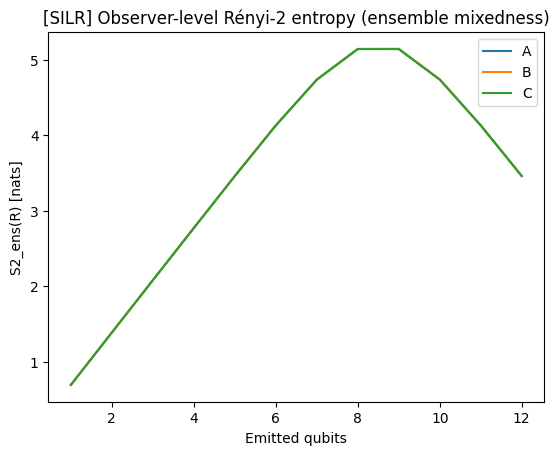

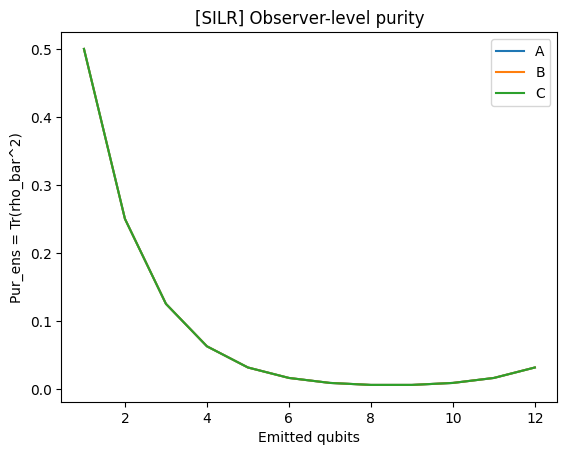

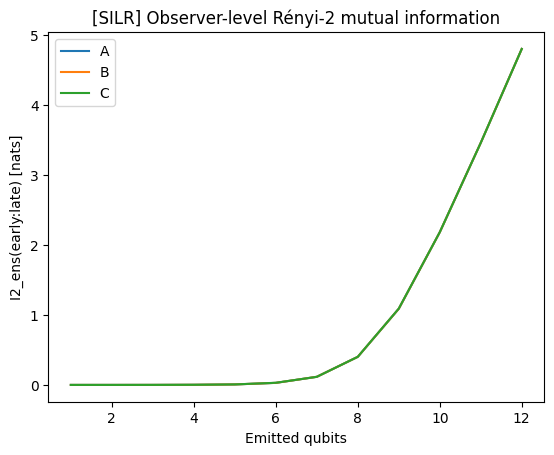

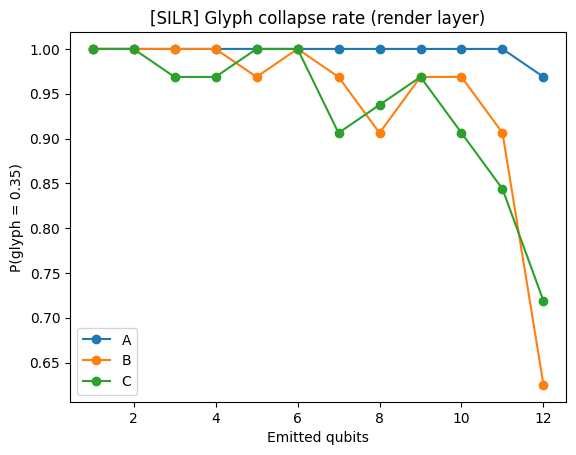

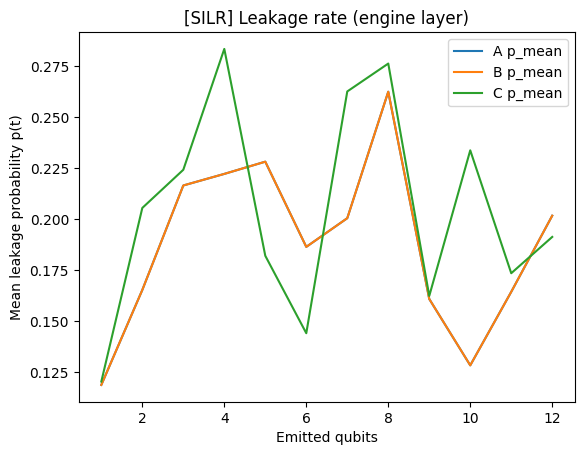

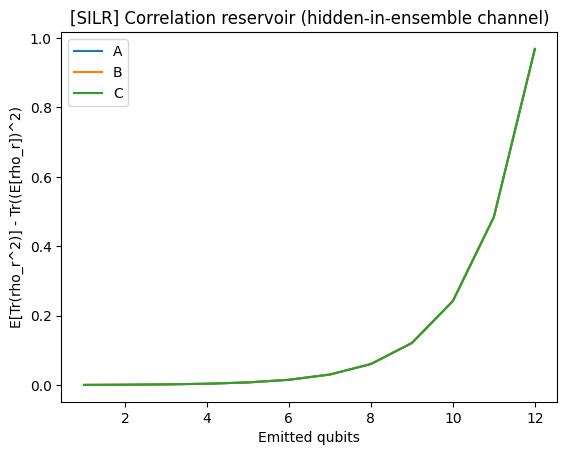


[Broken-SILR] Mean p over time D/E/F: 0.5416548744004782 0.03557254670242467 0.5524117742698218
[Broken-SILR] Final-step p_mean D/E/F: 0.5603599762579224 0.050482042852512184 0.46592819526123286
[Broken-SILR] collapse35_total D/E/F: 0.9427083333333334 1.0 0.9479166666666666


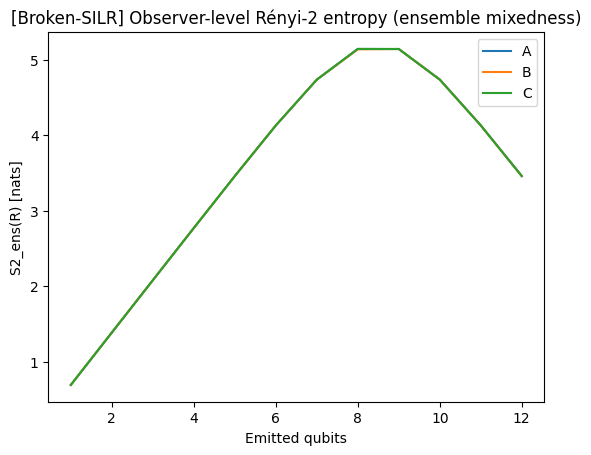

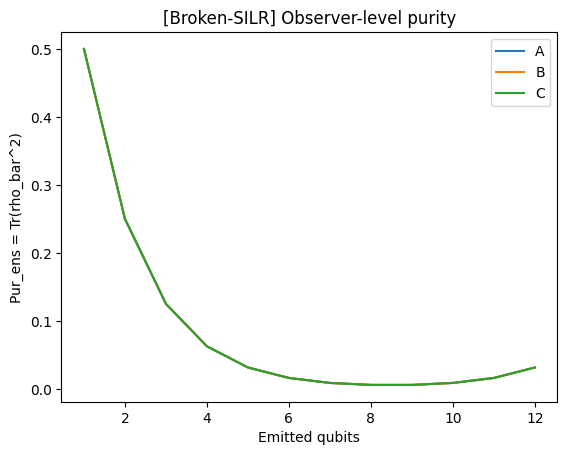

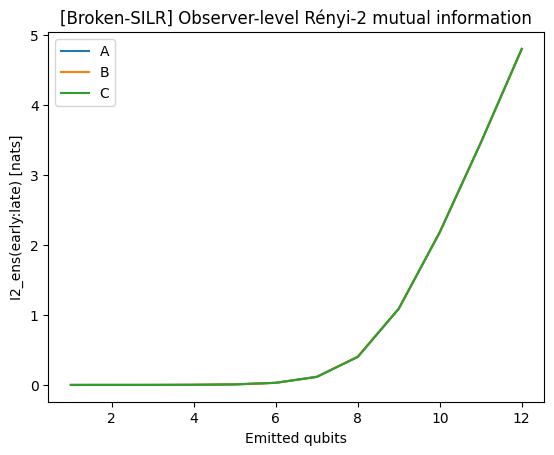

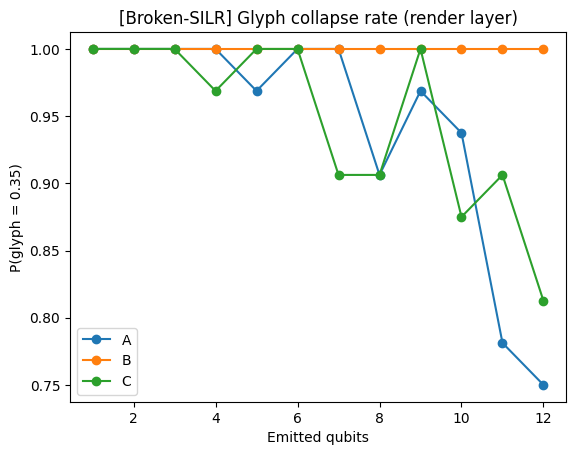

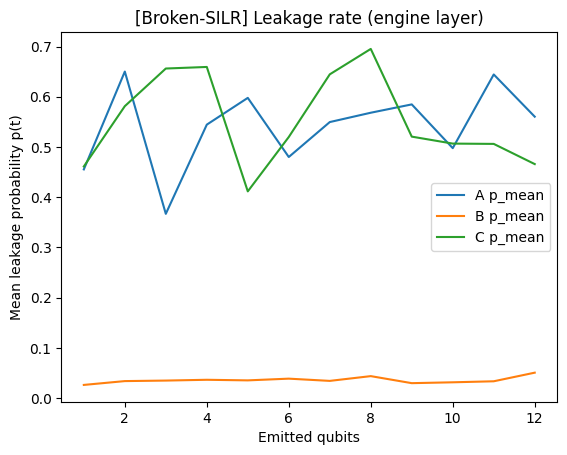

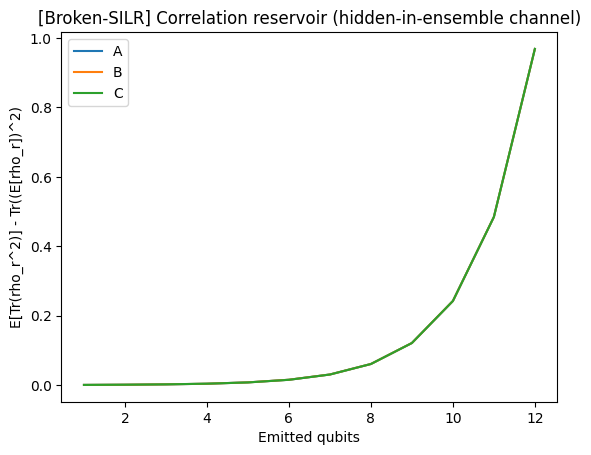

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Nexus HIL Simulator (full, consolidated)
----------------------------------------
Goal: demonstrate "Harmonic Information Leakage" as an *observer-level* mixedness effect
produced by unitary-per-trajectory dynamics + ensemble averaging.

Key knobs:
- alpha_true (use pi/9 or 0.35-glyph collapse)
- se_true(t): true estimator noise (can scale with shrinking BH)
- se_used(t): what the controller *assumes* (can match se_true => SILR, or mismatch => Broken-SILR)
- leakage p(t) = sigmoid(beta*(|alpha_hat-alpha_true|/se_used - z0))
- per-trajectory Pauli kick (unitary per run); mixedness appears only after averaging rho_bar

Outputs:
- Observer-level Renyi-2 entropy S2_ens(t) = -log Tr(rho_bar^2)
- Observer-level purity Pur_ens(t) = Tr(rho_bar^2)
- Observer-level Renyi-2 MI between early/late halves of radiation: MI2_ens(t)
- Render-layer glyph collapse probability P(glyph=0.35) (quantization)
- Engine-layer leakage mean p_mean(t) and z statistics
- Correlation reservoir: E[Tr(rho_r^2)] - Tr((E[rho_r])^2)

Designed to be readable and hackable.
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) Linear algebra utilities (random unitaries / gates)
# ============================================================

def random_unitary(dim: int, rng: np.random.Generator) -> np.ndarray:
    """Haar-ish random unitary via QR of complex Gaussian."""
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng: np.random.Generator) -> np.ndarray:
    return random_unitary(4, rng)

I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]  # 0:I, 1:X, 2:Y, 3:Z


# ============================================================
# 1) Apply gates to a statevector without building 2^N x 2^N
# ============================================================

def apply_1q(psi: np.ndarray, U: np.ndarray, q: int, N: int) -> np.ndarray:
    """Apply 1-qubit gate U on qubit q of N-qubit statevector psi."""
    T = psi.reshape([2] * N)
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi: np.ndarray, U4: np.ndarray, q1: int, q2: int, N: int) -> np.ndarray:
    """Apply 2-qubit gate U4 on qubits (q1,q2)."""
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1

    T = psi.reshape([2] * N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def scramble_bh_local(psi: np.ndarray, n_bh: int, N: int, depth: int, rng: np.random.Generator) -> np.ndarray:
    """
    Apply local 2-qubit random gates within the BH register [0..n_bh-1].
    Radiation lives in the tail [n_bh..N-1] and is untouched.
    """
    if n_bh < 2:
        return psi
    for _ in range(depth):
        for q in range(0, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
        for q in range(1, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
    return psi


# ============================================================
# 2) "Leakage": trajectory Pauli kicks (unitary per run)
#    Non-unitarity appears only after ensemble averaging.
# ============================================================

def apply_pauli_kick_trajectory(psi: np.ndarray, q: int, N: int, p: float, rng: np.random.Generator) -> np.ndarray:
    """
    With probability p, apply random X/Y/Z to qubit q.
    This remains unitary per trajectory (important).
    """
    p = float(np.clip(p, 0.0, 1.0))
    if p <= 0:
        return psi
    if rng.random() < (1.0 - p):
        return psi
    choice = int(rng.integers(1, 4))  # 1:X 2:Y 3:Z
    return apply_1q(psi, PAULIS[choice], q, N)


# ============================================================
# 3) Nexus control: alpha_hat -> glyph -> leakage probability
# ============================================================

def sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))

def alpha_hat_step(alpha_true: float, se_true: float, rng: np.random.Generator, dither: float = 0.0) -> float:
    """Sample alpha_hat ~ N(alpha_true, se_true^2), optional uniform dither."""
    a = float(rng.normal(loc=alpha_true, scale=max(se_true, 1e-12)))
    if dither > 0:
        a += float(rng.uniform(-dither, dither))
    return a

def leakage_from_alpha_z(alpha_hat: float, alpha_true: float, se_used: float, beta: float = 3.0, z0: float = 1.5) -> float:
    """
    Z-score gate:
      z = |alpha_hat - alpha_true| / se_used
      p = sigmoid(beta * (z - z0))
    """
    se_used = max(float(se_used), 1e-12)
    z = abs(alpha_hat - alpha_true) / se_used
    return sigmoid(beta * (z - z0))

def glyph_router_multiplier(glyph: float, target: float = 0.35, mode: str = "off") -> float:
    """
    Optional: make glyph a router (render-layer controls engine-layer).
    mode:
      "off"  -> multiplier 1.0
      "hard" -> 0.0 if glyph==target else 1.0
      "soft" -> smooth suppression near target
    """
    if mode == "off":
        return 1.0
    if mode == "hard":
        return 0.0 if abs(glyph - target) < 1e-12 else 1.0
    if mode == "soft":
        sigma = 0.003
        return float(1.0 - np.exp(-((glyph - target) ** 2) / (2 * sigma * sigma)))
    raise ValueError("mode must be one of: off, hard, soft")


# ============================================================
# 4) Radiation density matrix from a statevector snapshot
#    (Trace out BH by reshape: M is (dimB x dimR), rhoR = M†M)
# ============================================================

def rho_radiation_from_state(psi: np.ndarray, N: int, t: int) -> np.ndarray:
    """
    At step t (1..N), radiation has t qubits in the tail.
    Convention: BH qubits are [0..N-t-1], radiation [N-t..N-1].
    """
    dimR = 2 ** t
    dimB = 2 ** (N - t)
    M = psi.reshape(dimB, dimR)      # BH x R
    rhoR = M.conj().T @ M            # R x R
    return rhoR

def renyi2_from_rho(rho: np.ndarray) -> tuple[float, float]:
    """
    Return (S2, purity) where:
      purity = Tr(rho^2)
      S2 = -log purity
    """
    # For Hermitian rho, Tr(rho^2) == sum_ij |rho_ij|^2 (Frobenius^2)
    pur = float(np.sum(np.abs(rho) ** 2).real)
    pur = max(pur, 1e-15)
    return -float(np.log(pur)), pur

def partial_trace_radiation(rho: np.ndarray, keep: list[int], t: int) -> np.ndarray:
    """
    Partial trace on a density matrix rho of a t-qubit radiation register.
    keep = list of qubit indices to keep (within radiation: 0..t-1).
    """
    keep = list(keep)
    trace = [i for i in range(t) if i not in keep]

    T = rho.reshape([2] * t + [2] * t)
    perm = keep + trace + [i + t for i in keep] + [i + t for i in trace]
    T = np.transpose(T, perm)

    dk = 2 ** len(keep)
    dt = 2 ** len(trace)
    T = T.reshape(dk, dt, dk, dt)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep


# ============================================================
# 5) One trajectory: store snapshots after each emission step
# ============================================================

def run_one_trajectory_store(
    N: int = 12,
    alpha_true: float = np.pi / 9,
    # --- estimator noise model (true vs used) ---
    se0_true: float = 0.005,
    se0_used: float | None = None,         # None => SILR (se_used=se_true)
    se_scale_with_bh_true: bool = True,
    se_scale_with_bh_used: bool = True,
    dither: float = 0.0,
    # --- scrambling / gate ---
    depth: int = 2,
    beta_z: float = 3.0,
    z0: float = 1.5,
    glyph_route_mode: str = "off",         # off/hard/soft
    seed: int = 0
):
    rng = np.random.default_rng(seed)
    dim = 2 ** N

    # random initial pure state
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)

    n_bh = N
    snaps = np.zeros((N, dim), dtype=complex)
    p_hist = np.zeros(N, dtype=float)
    glyph_hist = np.zeros(N, dtype=float)
    collapse35 = np.zeros(N, dtype=float)
    z_hist = np.zeros(N, dtype=float)
    se_true_hist = np.zeros(N, dtype=float)
    se_used_hist = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        # scramble BH
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        # true estimator uncertainty
        if se_scale_with_bh_true:
            se_true_t = se0_true / np.sqrt(max(n_bh, 1))
        else:
            se_true_t = se0_true

        # controller's assumed uncertainty
        if se0_used is None:
            # SILR: use truth => z ~ |N(0,1)| regardless of scale
            se_used_t = se_true_t
        else:
            if se_scale_with_bh_used:
                se_used_t = se0_used / np.sqrt(max(n_bh, 1))
            else:
                se_used_t = se0_used

        se_true_hist[t - 1] = se_true_t
        se_used_hist[t - 1] = se_used_t

        # alpha_hat sampled from truth
        a_hat = alpha_hat_step(alpha_true, se_true_t, rng, dither=dither)

        # render layer: glyph collapse
        g = round(a_hat, 2)
        glyph_hist[t - 1] = g
        collapse35[t - 1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        # engine layer: leakage from z-score using se_used
        z = abs(a_hat - alpha_true) / max(se_used_t, 1e-12)
        z_hist[t - 1] = z

        p_t = leakage_from_alpha_z(a_hat, alpha_true, se_used_t, beta=beta_z, z0=z0)
        p_t *= glyph_router_multiplier(g, target=0.35, mode=glyph_route_mode)
        p_t = float(np.clip(p_t, 0.0, 1.0))
        p_hist[t - 1] = p_t

        # apply leakage on boundary qubit about to be emitted (last BH qubit)
        boundary = n_bh - 1
        psi = apply_pauli_kick_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        # emit boundary: BH shrinks by 1
        n_bh -= 1
        snaps[t - 1] = psi

    return snaps, p_hist, glyph_hist, collapse35, z_hist, se_true_hist, se_used_hist


# ============================================================
# 6) Ensemble observer metrics: rho_bar_R(t) and friends
# ============================================================

def ensemble_observer_metrics(
    N: int = 12,
    runs: int = 32,
    seed: int = 0,
    **traj_kwargs
):
    """
    Returns:
      - observer-level S2_ens, Pur_ens, MI2_ens (computed on rho_bar)
      - engine-level p_mean, p_std, z_mean, z_std
      - render-level collapse35_rate(t), collapse35_total
      - correlation reservoir: E[purity(traj)] - purity(ensemble)
    """
    dim = 2 ** N

    all_snaps = np.zeros((runs, N, dim), dtype=complex)
    all_p = np.zeros((runs, N), dtype=float)
    all_c35 = np.zeros((runs, N), dtype=float)
    all_z = np.zeros((runs, N), dtype=float)

    for r in range(runs):
        snaps, p_hist, _, c35, z_hist, _, _ = run_one_trajectory_store(
            N=N, seed=seed + r, **traj_kwargs
        )
        all_snaps[r] = snaps
        all_p[r] = p_hist
        all_c35[r] = c35
        all_z[r] = z_hist

    S2_ens = np.zeros(N, dtype=float)
    Pur_ens = np.zeros(N, dtype=float)
    MI2_ens = np.zeros(N, dtype=float)
    Pur_traj_mean = np.zeros(N, dtype=float)   # E[Tr(rho_r^2)]
    Corr_reservoir = np.zeros(N, dtype=float)  # E[Tr(rho_r^2)] - Tr((E[rho_r])^2)

    for t in range(1, N + 1):
        dimR = 2 ** t
        rho_sum = np.zeros((dimR, dimR), dtype=complex)
        pur_sum = 0.0

        for r in range(runs):
            psi = all_snaps[r, t - 1]
            rho_r = rho_radiation_from_state(psi, N=N, t=t)
            rho_sum += rho_r
            _, pur_r = renyi2_from_rho(rho_r)
            pur_sum += pur_r

        rho_bar = rho_sum / runs

        s2_bar, pur_bar = renyi2_from_rho(rho_bar)
        S2_ens[t - 1] = s2_bar
        Pur_ens[t - 1] = pur_bar
        Pur_traj_mean[t - 1] = pur_sum / runs
        Corr_reservoir[t - 1] = Pur_traj_mean[t - 1] - Pur_ens[t - 1]

        # Rényi-2 MI between early and late halves of radiation (within rho_bar)
        if t >= 2:
            split = t // 2
            early = list(range(0, split))
            late = list(range(split, t))
            rhoE = partial_trace_radiation(rho_bar, keep=early, t=t)
            rhoL = partial_trace_radiation(rho_bar, keep=late, t=t)
            s2E, _ = renyi2_from_rho(rhoE)
            s2L, _ = renyi2_from_rho(rhoL)
            MI2_ens[t - 1] = s2E + s2L - S2_ens[t - 1]
        else:
            MI2_ens[t - 1] = 0.0

    return {
        "S2_ens": S2_ens,
        "Pur_ens": Pur_ens,
        "MI2_ens": MI2_ens,
        "Pur_traj_mean": Pur_traj_mean,
        "Corr_reservoir": Corr_reservoir,
        "p_mean": all_p.mean(axis=0),
        "p_std": all_p.std(axis=0),
        "z_mean": all_z.mean(axis=0),
        "z_std": all_z.std(axis=0),
        "collapse35_rate": all_c35.mean(axis=0),
        "collapse35_total": float(all_c35.mean()),
    }


# ============================================================
# 7) Main: run SILR + Broken-SILR and plot
# ============================================================

def plot_pack(t, A, B, C, tag="[RUN]"):
    # S2
    plt.figure()
    plt.plot(t, A["S2_ens"], label="A")
    plt.plot(t, B["S2_ens"], label="B")
    plt.plot(t, C["S2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2_ens(R) [nats]")
    plt.title(f"{tag} Observer-level Rényi-2 entropy (ensemble mixedness)")
    plt.legend()
    plt.show()

    # Purity
    plt.figure()
    plt.plot(t, A["Pur_ens"], label="A")
    plt.plot(t, B["Pur_ens"], label="B")
    plt.plot(t, C["Pur_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Pur_ens = Tr(rho_bar^2)")
    plt.title(f"{tag} Observer-level purity")
    plt.legend()
    plt.show()

    # MI2
    plt.figure()
    plt.plot(t, A["MI2_ens"], label="A")
    plt.plot(t, B["MI2_ens"], label="B")
    plt.plot(t, C["MI2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2_ens(early:late) [nats]")
    plt.title(f"{tag} Observer-level Rényi-2 mutual information")
    plt.legend()
    plt.show()

    # Glyph collapse (render)
    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title(f"{tag} Glyph collapse rate (render layer)")
    plt.legend()
    plt.show()

    # Leakage p(t) (engine)
    plt.figure()
    plt.plot(t, A["p_mean"], label="A p_mean")
    plt.plot(t, B["p_mean"], label="B p_mean")
    plt.plot(t, C["p_mean"], label="C p_mean")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Mean leakage probability p(t)")
    plt.title(f"{tag} Leakage rate (engine layer)")
    plt.legend()
    plt.show()

    # Correlation reservoir
    plt.figure()
    plt.plot(t, A["Corr_reservoir"], label="A")
    plt.plot(t, B["Corr_reservoir"], label="B")
    plt.plot(t, C["Corr_reservoir"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("E[Tr(rho_r^2)] - Tr((E[rho_r])^2)")
    plt.title(f"{tag} Correlation reservoir (hidden-in-ensemble channel)")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    N = 12
    runs = 32
    t = np.arange(1, N + 1)

    alpha_true = float(np.pi / 9)
    print("alpha_true:", alpha_true, "  pi/9:", float(np.pi/9))

    # Shared physics/controller shape
    shared = dict(
        alpha_true=alpha_true,
        depth=2,
        beta_z=3.0,
        z0=1.5,
        glyph_route_mode="off",  # try "hard" to force glyph as valve
    )

    # ------------------------------------------------------------
    # (I) SILR: se_used == se_true  (scale-invariant z units)
    #     Differences in se0_true do NOT separate physics much.
    # ------------------------------------------------------------
    A_silr = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0020, se0_used=None,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0, **shared
    )
    B_silr = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0050, se0_used=None,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0, **shared
    )
    C_silr = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0050, se0_used=None,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0005, **shared
    )

    print("\n[SILR] Mean p over time A/B/C:",
          A_silr["p_mean"].mean(), B_silr["p_mean"].mean(), C_silr["p_mean"].mean())
    print("[SILR] Final-step p_mean A/B/C:",
          A_silr["p_mean"][-1], B_silr["p_mean"][-1], C_silr["p_mean"][-1])
    print("[SILR] collapse35_total A/B/C:",
          A_silr["collapse35_total"], B_silr["collapse35_total"], C_silr["collapse35_total"])

    plot_pack(t, A_silr, B_silr, C_silr, tag="[SILR]")

    # ------------------------------------------------------------
    # (II) Broken-SILR: se_used != se_true
    #     Now curves SHOULD separate (controller mismatch).
    # ------------------------------------------------------------
    # D: controller underestimates SE (thinks it's more precise) -> larger z -> more leakage
    D_broken = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0050, se0_used=0.0020,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0, **shared
    )
    # E: controller overestimates SE (thinks it's noisier) -> smaller z -> less leakage
    E_broken = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0020, se0_used=0.0050,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0, **shared
    )
    # F: add dither while mismatch exists (tests “render noise” injection vs engine gate)
    F_broken = ensemble_observer_metrics(
        N=N, runs=runs, seed=7,
        se0_true=0.0050, se0_used=0.0020,
        se_scale_with_bh_true=True, se_scale_with_bh_used=True,
        dither=0.0005, **shared
    )

    print("\n[Broken-SILR] Mean p over time D/E/F:",
          D_broken["p_mean"].mean(), E_broken["p_mean"].mean(), F_broken["p_mean"].mean())
    print("[Broken-SILR] Final-step p_mean D/E/F:",
          D_broken["p_mean"][-1], E_broken["p_mean"][-1], F_broken["p_mean"][-1])
    print("[Broken-SILR] collapse35_total D/E/F:",
          D_broken["collapse35_total"], E_broken["collapse35_total"], F_broken["collapse35_total"])

    plot_pack(t, D_broken, E_broken, F_broken, tag="[Broken-SILR]")


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) Linear algebra utilities (random unitaries / gates)
# ============================================================

def random_unitary(dim: int, rng: np.random.Generator) -> np.ndarray:
    """Haar-ish random unitary via QR of complex Gaussian."""
    X = (rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(X)
    ph = np.diag(R)
    ph = ph / np.where(np.abs(ph) > 0, np.abs(ph), 1.0)
    return Q * ph.conj()

def random_two_qubit_gate(rng: np.random.Generator) -> np.ndarray:
    return random_unitary(4, rng)

I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = [I2, X, Y, Z]  # 0:I, 1:X, 2:Y, 3:Z

# ============================================================
# 1) Apply gates to a statevector without building 2^N x 2^N
# ============================================================

def apply_1q(psi: np.ndarray, U: np.ndarray, q: int, N: int) -> np.ndarray:
    """Apply 1-qubit gate U on qubit q of N-qubit statevector psi."""
    T = psi.reshape([2] * N)
    perm = [q] + [i for i in range(N) if i != q]
    T = np.transpose(T, perm).reshape(2, -1)
    T = (U @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def apply_2q(psi: np.ndarray, U4: np.ndarray, q1: int, q2: int, N: int) -> np.ndarray:
    """Apply 2-qubit gate U4 on qubits (q1,q2)."""
    if q1 == q2:
        raise ValueError("q1 != q2 required")
    if q1 > q2:
        q1, q2 = q2, q1

    T = psi.reshape([2] * N)
    perm = [q1, q2] + [i for i in range(N) if i not in (q1, q2)]
    T = np.transpose(T, perm).reshape(4, -1)
    T = (U4 @ T).reshape([2] * N)
    inv = np.argsort(perm)
    return np.transpose(T, inv).reshape(-1)

def scramble_bh_local(psi: np.ndarray, n_bh: int, N: int, depth: int, rng: np.random.Generator) -> np.ndarray:
    """
    Apply local 2-qubit random gates within the BH register [0..n_bh-1].
    Radiation lives in the tail [n_bh..N-1] and is untouched.
    """
    if n_bh < 2:
        return psi
    for _ in range(depth):
        for q in range(0, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
        for q in range(1, n_bh - 1, 2):
            psi = apply_2q(psi, random_two_qubit_gate(rng), q, q + 1, N)
    return psi

# ============================================================
# 2) "Leakage": trajectory Pauli kicks (unitary per run)
#    Non-unitarity appears only after ensemble averaging.
# ============================================================

def apply_pauli_kick_trajectory(psi: np.ndarray, q: int, N: int, p: float, rng: np.random.Generator) -> np.ndarray:
    """
    With probability p, apply random X/Y/Z to qubit q.
    This remains unitary per trajectory (important).
    """
    p = float(np.clip(p, 0.0, 1.0))
    if p <= 0:
        return psi
    if rng.random() < (1.0 - p):
        return psi
    choice = int(rng.integers(1, 4))  # 1:X 2:Y 3:Z
    return apply_1q(psi, PAULIS[choice], q, N)

# ============================================================
# 3) Nexus control: alpha_hat -> glyph -> leakage probability
# ============================================================

def sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))

def alpha_hat_step(alpha_true: float, se_true: float, rng: np.random.Generator, dither: float = 0.0) -> float:
    """Sample alpha_hat ~ N(alpha_true, se_true^2), optional uniform dither."""
    a = float(rng.normal(loc=alpha_true, scale=max(se_true, 1e-12)))
    if dither > 0:
        a += float(rng.uniform(-dither, dither))
    return a

def leakage_from_alpha_z(alpha_hat: float, alpha_true: float, se_used: float, beta: float = 3.0, z0: float = 1.5) -> float:
    """
    Z-score gate:
      z = |alpha_hat - alpha_true| / se_used
      p = sigmoid(beta * (z - z0))
    """
    se_used = max(float(se_used), 1e-12)
    z = abs(alpha_hat - alpha_true) / se_used
    return sigmoid(beta * (z - z0))

def glyph_router_multiplier(glyph: float, target: float = 0.35, mode: str = "off") -> float:
    """
    Optional: make glyph a router (render-layer controls engine-layer).
    mode:
      "off"  -> multiplier 1.0
      "hard" -> 0.0 if glyph==target else 1.0
      "soft" -> smooth suppression near target
    """
    if mode == "off":
        return 1.0
    if mode == "hard":
        return 0.0 if abs(glyph - target) < 1e-12 else 1.0
    if mode == "soft":
        sigma = 0.003
        return float(1.0 - np.exp(-((glyph - target) ** 2) / (2 * sigma * sigma)))
    raise ValueError("mode must be one of: off, hard, soft")


# ============================================================
# 4) Radiation density matrix from a statevector snapshot
# ============================================================

def rho_radiation_from_state(psi: np.ndarray, N: int, t: int) -> np.ndarray:
    """
    At step t (1..N), radiation has t qubits in the tail.
    Convention: BH qubits are [0..N-t-1], radiation [N-t..N-1].
    """
    dimR = 2 ** t
    dimB = 2 ** (N - t)
    M = psi.reshape(dimB, dimR)      # BH x R
    rhoR = M.conj().T @ M            # R x R
    return rhoR

def renyi2_from_rho(rho: np.ndarray) -> tuple[float, float]:
    """
    Return (S2, purity) where:
      purity = Tr(rho^2)
      S2 = -log purity
    """
    # For Hermitian rho, Tr(rho^2) == sum_ij |rho_ij|^2 (Frobenius^2)
    pur = float(np.sum(np.abs(rho) ** 2).real)
    pur = max(pur, 1e-15)
    return -float(np.log(pur)), pur

def partial_trace_radiation(rho: np.ndarray, keep: list[int], t: int) -> np.ndarray:
    """
    Partial trace on a density matrix rho of a t-qubit radiation register.
    keep = list of qubit indices to keep (within radiation: 0..t-1).
    """
    keep = list(keep)
    trace = [i for i in range(t) if i not in keep]

    T = rho.reshape([2] * t + [2] * t)
    perm = keep + trace + [i + t for i in keep] + [i + t for i in trace]
    T = np.transpose(T, perm)

    dk = 2 ** len(keep)
    dt = 2 ** len(trace)
    T = T.reshape(dk, dt, dk, dt)
    rho_keep = np.einsum("a b c b -> a c", T)
    return rho_keep


# ============================================================
# 5) One trajectory: store snapshots after each emission step
# ============================================================

def run_one_trajectory_store(
    N: int = 12,
    alpha_true: float = np.pi / 9,
    # --- estimator noise model (true vs used) ---
    se0_true: float = 0.005,
    se0_used: float | None = None,         # None => SILR (se_used=se_true)
    se_scale_with_bh_true: bool = True,
    se_scale_with_bh_used: bool = True,
    dither: float = 0.0,
    # --- scrambling / gate ---
    depth: int = 2,
    beta_z: float = 3.0,
    z0: float = 1.5,
    glyph_route_mode: str = "off",         # off/hard/soft
    seed: int = 0
):
    rng = np.random.default_rng(seed)
    dim = 2 ** N

    # random initial pure state
    psi = (rng.normal(size=dim) + 1j * rng.normal(size=dim))
    psi = psi / np.linalg.norm(psi)

    n_bh = N
    snaps = np.zeros((N, dim), dtype=complex)
    p_hist = np.zeros(N, dtype=float)
    glyph_hist = np.zeros(N, dtype=float)
    collapse35 = np.zeros(N, dtype=float)
    z_hist = np.zeros(N, dtype=float)
    se_true_hist = np.zeros(N, dtype=float)
    se_used_hist = np.zeros(N, dtype=float)

    for t in range(1, N + 1):
        # scramble BH
        psi = scramble_bh_local(psi, n_bh=n_bh, N=N, depth=depth, rng=rng)

        # true estimator uncertainty
        if se_scale_with_bh_true:
            se_true_t = se0_true / np.sqrt(max(n_bh, 1))
        else:
            se_true_t = se0_true

        # controller's assumed uncertainty
        if se0_used is None:
            # SILR: use truth => z ~ |N(0,1)| regardless of scale
            se_used_t = se_true_t
        else:
            if se_scale_with_bh_used:
                se_used_t = se0_used / np.sqrt(max(n_bh, 1))
            else:
                se_used_t = se0_used

        se_true_hist[t - 1] = se_true_t
        se_used_hist[t - 1] = se_used_t

        # alpha_hat sampled from truth
        a_hat = alpha_hat_step(alpha_true, se_true_t, rng, dither=dither)

        # render layer: glyph collapse
        g = round(a_hat, 2)
        glyph_hist[t - 1] = g
        collapse35[t - 1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        # engine layer: leakage from z-score using se_used
        z = abs(a_hat - alpha_true) / max(se_used_t, 1e-12)
        z_hist[t - 1] = z

        p_t = leakage_from_alpha_z(a_hat, alpha_true, se_used_t, beta=beta_z, z0=z0)
        p_t *= glyph_router_multiplier(g, target=0.35, mode=glyph_route_mode)
        p_t = np.clip(p_t, 0.0, 1.0)

        # Update history
        p_hist[t - 1] = p_t
        glyph_hist[t - 1] = g
        collapse35[t - 1] = 1.0 if abs(g - 0.35) < 1e-12 else 0.0

        # apply leakage on boundary qubit about to be emitted
        boundary = n_bh - 1
        psi = apply_pauli_kick_trajectory(psi, q=boundary, N=N, p=p_t, rng=rng)

        # emit boundary: BH shrinks by 1
        n_bh -= 1
        snaps[t - 1] = psi

    return snaps, p_hist, glyph_hist, collapse35, z_hist, se_true_hist, se_used_hist


# ============================================================
# 6) Ensemble observer metrics: rho_bar_R(t) and friends
# ============================================================

def ensemble_observer_metrics(
    N: int = 12,
    runs: int = 32,
    seed: int = 0,
    **traj_kwargs
):
    """
    Returns:
      - observer-level S2_ens, Pur_ens, MI2_ens (computed on rho_bar)
      - engine-level p_mean, p_std, z_mean, z_std
      - render-level collapse35_rate(t), collapse35_total
      - correlation reservoir: E[purity(traj)] - purity(ensemble)
    """
    dim = 2 ** N

    all_snaps = np.zeros((runs, N, dim), dtype=complex)
    all_p = np.zeros((runs, N), dtype=float)
    all_c35 = np.zeros((runs, N), dtype=float)
    all_z = np.zeros((runs, N), dtype=float)

    for r in range(runs):
        snaps, p_hist, _, c35, z_hist, _, _ = run_one_trajectory_store(
            N=N, seed=seed + r, **traj_kwargs
        )
        all_snaps[r] = snaps
        all_p[r] = p_hist
        all_c35[r] = c35
        all_z[r] = z_hist

    S2_ens = np.zeros(N, dtype=float)
    Pur_ens = np.zeros(N, dtype=float)
    MI2_ens = np.zeros(N, dtype=float)
    Pur_traj_mean = np.zeros(N, dtype=float)   # E[Tr(rho_r^2)]
    Corr_reservoir = np.zeros(N, dtype=float)  # E[Tr(rho_r^2)] - Tr((E[rho_r])^2)

    for t in range(1, N + 1):
        dimR = 2 ** t
        rho_sum = np.zeros((dimR, dimR), dtype=complex)
        pur_sum = 0.0

        for r in range(runs):
            psi = all_snaps[r, t - 1]
            rho_r = rho_radiation_from_state(psi, N=N, t=t)
            rho_sum += rho_r
            _, pur_r = renyi2_from_rho(rho_r)
            pur_sum += pur_r

        rho_bar = rho_sum / runs

        s2_bar, pur_bar = renyi2_from_rho(rho_bar)
        S2_ens[t - 1] = s2_bar
        Pur_ens[t - 1] = pur_bar
        Pur_traj_mean[t - 1] = pur_sum / runs
        Corr_reservoir[t - 1] = Pur_traj_mean[t - 1] - Pur_ens[t - 1]

        # Rényi-2 MI between early and late halves of radiation (within rho_bar)
        if t >= 2:
            split = t // 2
            early = list(range(0, split))
            late = list(range(split, t))
            rhoE = partial_trace_radiation(rho_bar, keep=early, t=t)
            rhoL = partial_trace_radiation(rho_bar, keep=late, t=t)
            s2E, _ = renyi2_from_rho(rhoE)
            s2L, _ = renyi2_from_rho(rhoL)
            MI2_ens[t - 1] = s2E + s2L - S2_ens[t - 1]
        else:
            MI2_ens[t - 1] = 0.0

    return {
        "S2_ens": S2_ens,
        "Pur_ens": Pur_ens,
        "MI2_ens": MI2_ens,
        "Pur_traj_mean": Pur_traj_mean,
        "Corr_reservoir": Corr_reservoir,
        "p_mean": all_p.mean(axis=0),
        "p_std": all_p.std(axis=0),
        "z_mean": all_z.mean(axis=0),
        "z_std": all_z.std(axis=0),
        "collapse35_rate": all_c35.mean(axis=0),
        "collapse35_total": float(all_c35.mean()),
    }


Mean p over time A/B/C: 0.18802618773898339, 0.18802618773898294, 0.20503532699756644
Final-step p_mean A/B/C: 0.20177801846389304, 0.20177801846389334, 0.1913582709415456
Collapse35 total A/B/C: 0.9973958333333334, 0.9427083333333334, 0.9348958333333334
Final S2_ens for A/B/C: 3.457967082536834, 3.457967082536834, 3.4584274263817156
Final Pur_ens for A/B/C: 0.03149372112019826, 0.03149372112019826, 0.03147922651603503


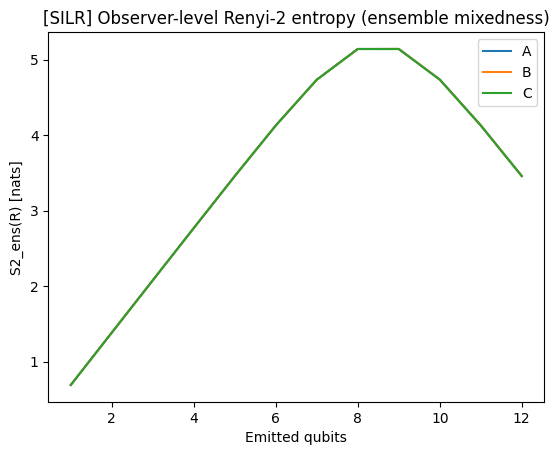

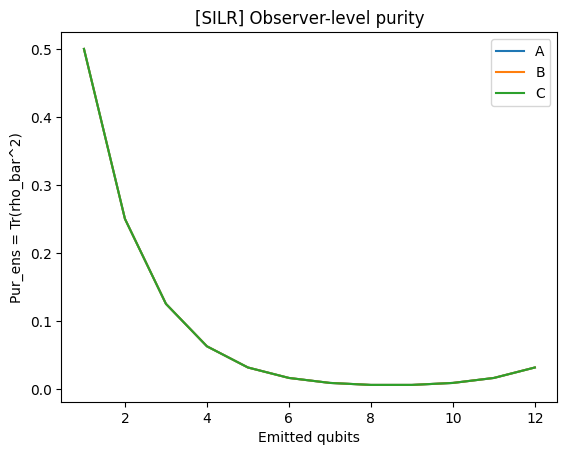

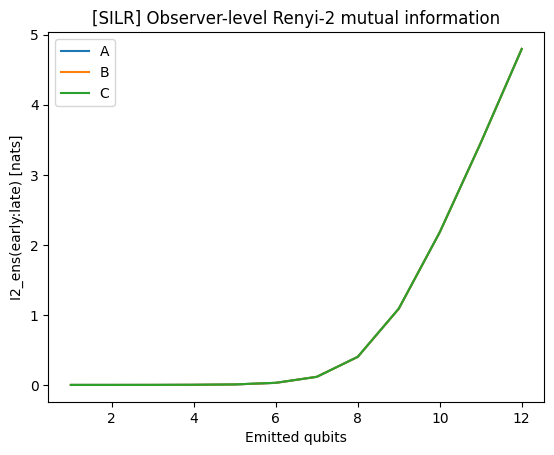

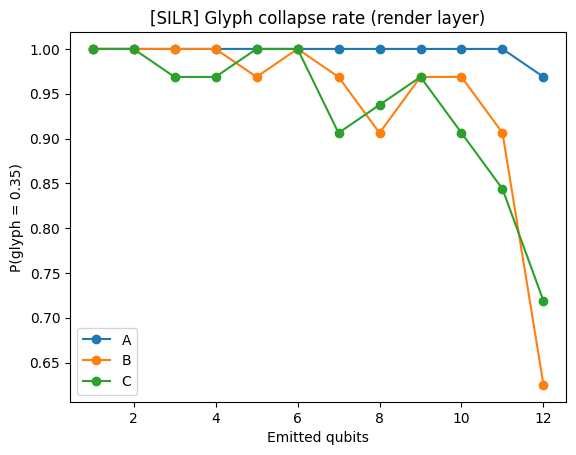

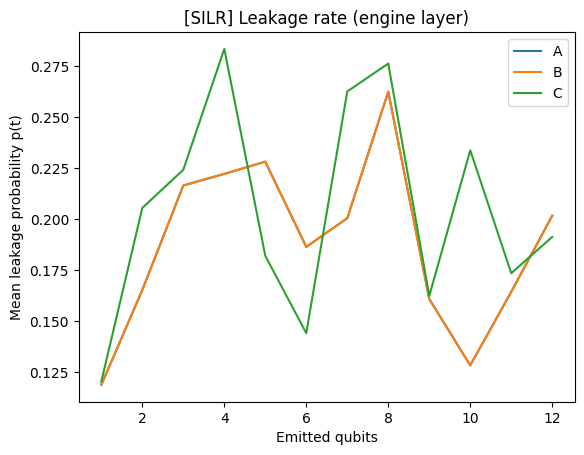

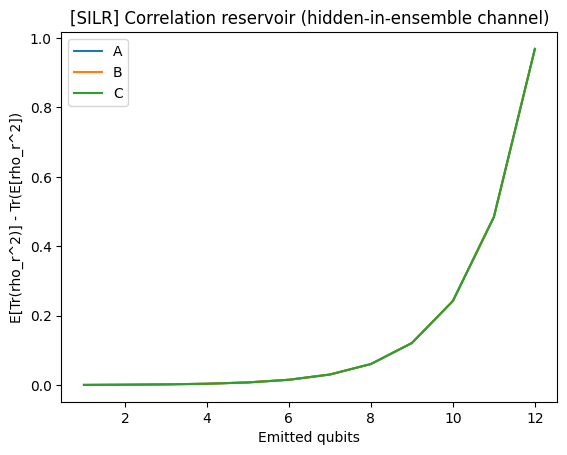

In [4]:
if __name__ == "__main__":
    N = 12
    runs = 32   # number of runs for ensemble average
    t = np.arange(1, N + 1)

    alpha_true = np.pi / 9  # Set alpha_true value here
    shared = dict(
        alpha_true=alpha_true,
        depth=2,
        beta_z=3.0,
        z0=1.5,
        glyph_route_mode="off",
    )

    # Running different configurations for ensemble metrics
    A = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0_true=0.0020, se0_used=None, dither=0.0, **shared)
    B = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0_true=0.0050, se0_used=None, dither=0.0, **shared)
    C = ensemble_observer_metrics(N=N, runs=runs, seed=7, se0_true=0.0050, se0_used=None, dither=0.0005, **shared)

    # Display the key metrics
    print(f"Mean p over time A/B/C: {A['p_mean'].mean()}, {B['p_mean'].mean()}, {C['p_mean'].mean()}")
    print(f"Final-step p_mean A/B/C: {A['p_mean'][-1]}, {B['p_mean'][-1]}, {C['p_mean'][-1]}")
    print(f"Collapse35 total A/B/C: {A['collapse35_total']}, {B['collapse35_total']}, {C['collapse35_total']}")

    # You can print more metrics if needed
    print(f"Final S2_ens for A/B/C: {A['S2_ens'][-1]}, {B['S2_ens'][-1]}, {C['S2_ens'][-1]}")
    print(f"Final Pur_ens for A/B/C: {A['Pur_ens'][-1]}, {B['Pur_ens'][-1]}, {C['Pur_ens'][-1]}")

    # Plot the results for different configurations
    plt.figure()
    plt.plot(t, A["S2_ens"], label="A")
    plt.plot(t, B["S2_ens"], label="B")
    plt.plot(t, C["S2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("S2_ens(R) [nats]")
    plt.title("[SILR] Observer-level Renyi-2 entropy (ensemble mixedness)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["Pur_ens"], label="A")
    plt.plot(t, B["Pur_ens"], label="B")
    plt.plot(t, C["Pur_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Pur_ens = Tr(rho_bar^2)")
    plt.title("[SILR] Observer-level purity")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["MI2_ens"], label="A")
    plt.plot(t, B["MI2_ens"], label="B")
    plt.plot(t, C["MI2_ens"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("I2_ens(early:late) [nats]")
    plt.title("[SILR] Observer-level Renyi-2 mutual information")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["collapse35_rate"], marker="o", label="A")
    plt.plot(t, B["collapse35_rate"], marker="o", label="B")
    plt.plot(t, C["collapse35_rate"], marker="o", label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("P(glyph = 0.35)")
    plt.title("[SILR] Glyph collapse rate (render layer)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["p_mean"], label="A")
    plt.plot(t, B["p_mean"], label="B")
    plt.plot(t, C["p_mean"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("Mean leakage probability p(t)")
    plt.title("[SILR] Leakage rate (engine layer)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, A["Corr_reservoir"], label="A")
    plt.plot(t, B["Corr_reservoir"], label="B")
    plt.plot(t, C["Corr_reservoir"], label="C")
    plt.xlabel("Emitted qubits")
    plt.ylabel("E[Tr(rho_r^2)] - Tr(E[rho_r^2])")
    plt.title("[SILR] Correlation reservoir (hidden-in-ensemble channel)")
    plt.legend()
    plt.show()


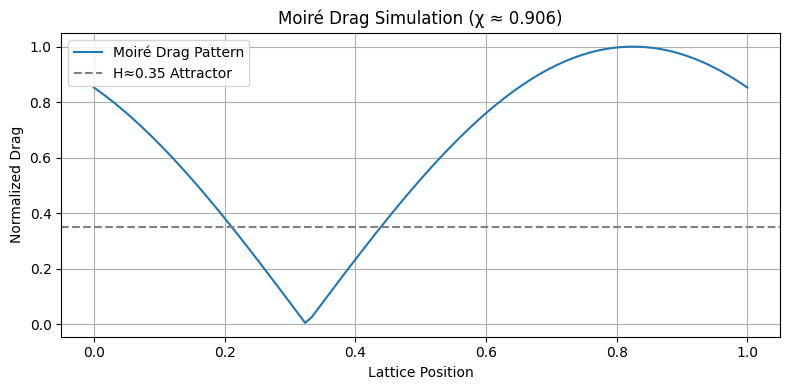

Coherence Echo (χ): 0.906


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def moire_drag(lattice_size=100, phase_offset=0.35, gap_min=2):
    """
    Simulate Moiré drag between two out-of-phase lattices.
    Lattice A: base grid with twin-prime-like gaps.
    Lattice B: phase-shifted grid (offset by H≈0.35).
    Compute interference (Moiré pattern) as drag proxy.
    """
    x = np.linspace(0, 1, lattice_size)
    
    # Lattice A: sinusoidal with minimal gap modulation
    A = np.sin(2 * np.pi * x * (1 / gap_min))
    
    # Lattice B: out-of-phase (shift by phase_offset)
    B = np.sin(2 * np.pi * (x + phase_offset) * (1 / gap_min))
    
    # Moiré interference (drag as absolute difference, normalized)
    drag = np.abs(A - B)
    drag_norm = drag / np.max(drag)  # Normalize to [0,1]
    
    # Coherence echo (inverse variance as χ proxy)
    chi = 1 - np.var(drag_norm)
    
    return x, drag_norm, chi

# Run simulation
x, drag, chi = moire_drag()

# Plot
plt.figure(figsize=(8,4))
plt.plot(x, drag, label='Moiré Drag Pattern')
plt.axhline(0.35, color='gray', linestyle='--', label='H≈0.35 Attractor')
plt.xlabel('Lattice Position')
plt.ylabel('Normalized Drag')
plt.title(f'Moiré Drag Simulation (χ ≈ {chi:.3f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('moire_drag.png')
plt.show()

print(f"Coherence Echo (χ): {chi:.3f}")

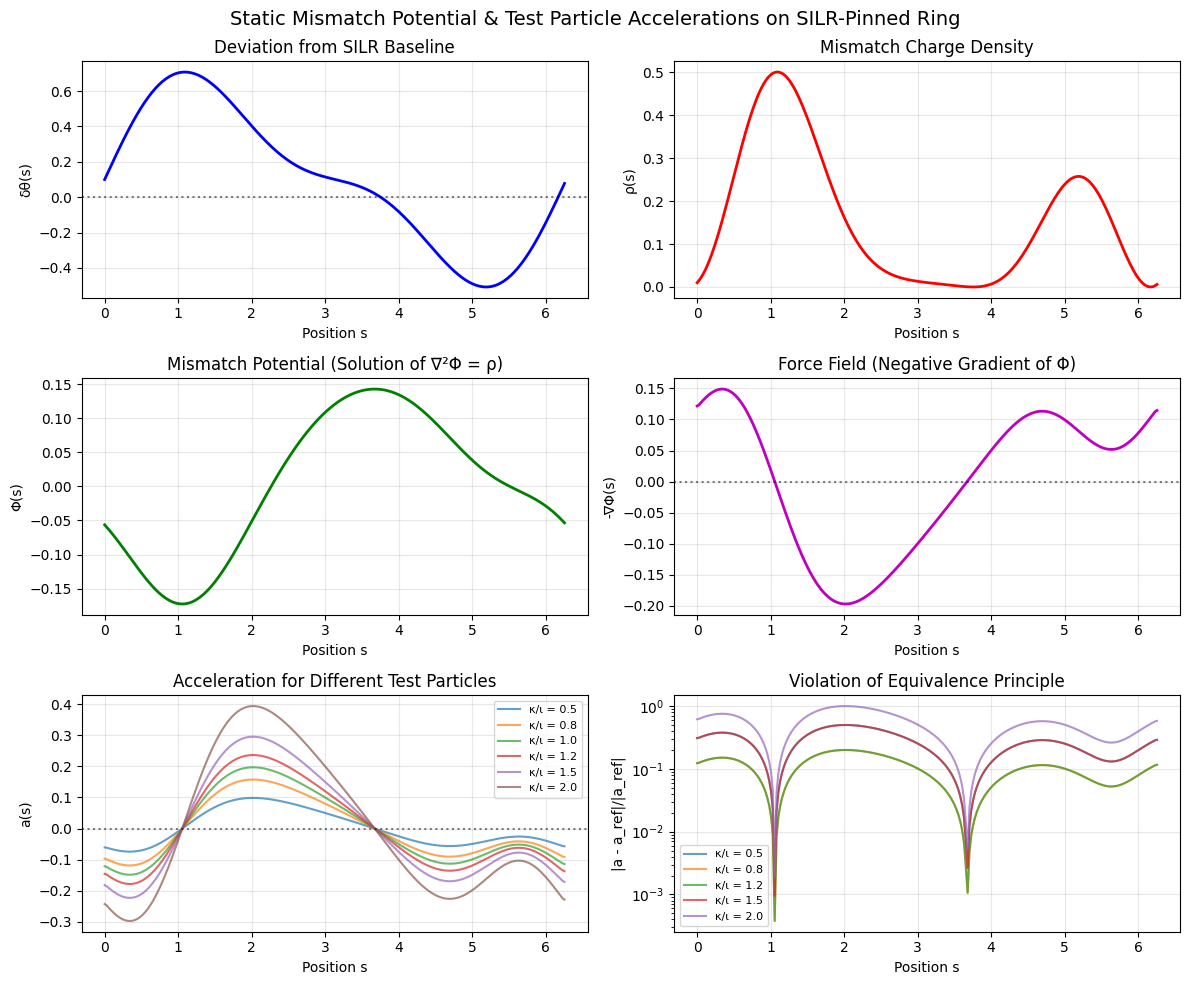

EQUIVALENCE PRINCIPLE TEST:
When κ/ι = 1.0, acceleration is independent of object properties.

Root-mean-square accelerations:
  κ/ι =  0.5: RMS acceleration = 0.056384
  κ/ι =  0.8: RMS acceleration = 0.090214
  κ/ι =  1.0: RMS acceleration = 0.112767
  κ/ι =  1.2: RMS acceleration = 0.135321
  κ/ι =  1.5: RMS acceleration = 0.169151
  κ/ι =  2.0: RMS acceleration = 0.225534

Maximum violation (relative to κ/ι=1.0):
  κ/ι =  0.5: max relative difference = 0.500000
  κ/ι =  0.8: max relative difference = 0.200000
  κ/ι =  1.2: max relative difference = 0.200000
  κ/ι =  1.5: max relative difference = 0.500000
  κ/ι =  2.0: max relative difference = 1.000000

Key insight: When κ/ι ≠ 1, equivalence principle is violated.
For SILR-stable structures, κ/ι ≈ 1 naturally.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

# Define the mismatch field and solve for potential
def compute_potential_on_circle(rho, L):
    N = len(rho)
    dx = L / N
    x = np.linspace(0, L, N, endpoint=False)

    # Fourier transform
    rho_k = fft(rho)
    k = 2 * np.pi * np.fft.fftfreq(N, dx)

    # Avoid division by zero at k=0
    with np.errstate(divide='ignore', invalid='ignore'):
        Phi_k = -rho_k / (k**2)
        Phi_k[0] = 0  # Set zero mean

    # Inverse transform
    Phi = np.real(ifft(Phi_k))

    # Compute force field (negative gradient of Phi)
    F = -np.gradient(Phi, dx)

    return x, Phi, F

# Test particles with different κ/ι ratios
def test_particle_accelerations(x, F, kappa_iota_ratios):
    results = {}
    for ratio in kappa_iota_ratios:
        a = -ratio * F  # a = -(κ/ι) * ∇Φ
        results[ratio] = a
    return results

# Parameters
L = 2 * np.pi  # Circumference = 2π
N = 256
x = np.linspace(0, L, N, endpoint=False)

# Create a non-uniform deviation from SILR (simplest case: sinusoidal)
delta_theta = 0.5 * np.sin(2 * np.pi * x / L) + 0.2 * np.sin(4 * np.pi * x / L) + 0.1

# Mismatch charge density (always positive)
rho = delta_theta**2

# Solve for potential and force
x, Phi, F = compute_potential_on_circle(rho, L)

# Test particles with different κ/ι ratios
kappa_iota_ratios = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
accelerations = test_particle_accelerations(x, F, kappa_iota_ratios)

# Plotting results
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Deviation from SILR
ax = axes[0]
ax.plot(x, delta_theta, 'b-', linewidth=2)
ax.set_xlabel('Position s')
ax.set_ylabel('δθ(s)')
ax.set_title('Deviation from SILR Baseline')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)

# Plot 2: Mismatch charge density
ax = axes[1]
ax.plot(x, rho, 'r-', linewidth=2)
ax.set_xlabel('Position s')
ax.set_ylabel('ρ(s)')
ax.set_title('Mismatch Charge Density')
ax.grid(True, alpha=0.3)

# Plot 3: Mismatch potential Φ
ax = axes[2]
ax.plot(x, Phi, 'g-', linewidth=2)
ax.set_xlabel('Position s')
ax.set_ylabel('Φ(s)')
ax.set_title('Mismatch Potential (Solution of ∇²Φ = ρ)')
ax.grid(True, alpha=0.3)

# Plot 4: Force field (-∇Φ)
ax = axes[3]
ax.plot(x, F, 'm-', linewidth=2)
ax.set_xlabel('Position s')
ax.set_ylabel('-∇Φ(s)')
ax.set_title('Force Field (Negative Gradient of Φ)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)

# Plot 5: Accelerations for different κ/ι ratios
ax = axes[4]
for ratio, a in accelerations.items():
    ax.plot(x, a, label=f'κ/ι = {ratio}', alpha=0.7)
ax.set_xlabel('Position s')
ax.set_ylabel('a(s)')
ax.set_title('Acceleration for Different Test Particles')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)

# Plot 6: Equivalence principle check
ax = axes[5]
# Compute reference acceleration for κ/ι = 1
a_ref = accelerations[1.0]
for ratio, a in accelerations.items():
    if ratio != 1.0:
        relative_diff = np.abs(a - a_ref) / np.max(np.abs(a_ref))
        ax.plot(x, relative_diff, label=f'κ/ι = {ratio}', alpha=0.7)
ax.set_xlabel('Position s')
ax.set_ylabel('|a - a_ref|/|a_ref|')
ax.set_title('Violation of Equivalence Principle')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
ax.set_yscale('log')

plt.suptitle('Static Mismatch Potential & Test Particle Accelerations on SILR-Pinned Ring', fontsize=14)
plt.tight_layout()
plt.show()

# Print key metrics
print("EQUIVALENCE PRINCIPLE TEST:")
print("=" * 50)
print("When κ/ι = 1.0, acceleration is independent of object properties.")
print("\nRoot-mean-square accelerations:")
for ratio, a in accelerations.items():
    rms_a = np.sqrt(np.mean(a**2))
    print(f"  κ/ι = {ratio:4.1f}: RMS acceleration = {rms_a:.6f}")
print("\nMaximum violation (relative to κ/ι=1.0):")
for ratio, a in accelerations.items():
    if ratio != 1.0:
        relative_diff = np.max(np.abs(a - accelerations[1.0])) / np.max(np.abs(accelerations[1.0]))
        print(f"  κ/ι = {ratio:4.1f}: max relative difference = {relative_diff:.6f}")
print("\n" + "=" * 50)
print("Key insight: When κ/ι ≠ 1, equivalence principle is violated.")
print("For SILR-stable structures, κ/ι ≈ 1 naturally.")
